# POLYHAQ — Feature-space Expansion Using Quantum Walks

This notebook provides a leakage-safe experimental scaffold for the Breast Cancer Wisconsin dataset. The validated 1D Quantum Walk physics and the supplied 2D Quantum Walk implementation are integrated behind independent execution switches.


# 1. Experiment Configuration


In [1]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
PRIMARY_METRIC = "f1_macro"
ALPHA = 0.05
EPSILON = 1e-8
PROBABILITY_FEATURE_EPSILON = 1e-12
QW_REPRESENTATION_MODES = [
    "probability",
    "rich",
    "probability_plus_rich",
]

T_VALUES_1D = list([1,3,5,7,9])
T_VALUES_2D = list(range(1, 11))
T_SCREEN_VALUES_2D = [T_VALUES_2D[0], T_VALUES_2D[len(T_VALUES_2D) // 2], T_VALUES_2D[-1]]

# Advanced, non-exhaustive 2D permutation optimizer (production defaults).
ADVANCED_MAPPING_SEARCH_2D = True
MAPPING_RANDOM_STARTS_2D = 500
MAPPING_ELITE_COUNT_2D = 10
MAPPING_SCREEN_T_VALUES_2D = [2, 5, 8]
MAPPING_LOCAL_MAX_ITER_2D = 5
MAPPING_PERTURB_RESTARTS_2D = 1
MAPPING_PERTURB_TRIALS_2D = 20
MAPPING_FINALIST_COUNT_2D = 10
VERIFY_FINAL_TWO_SWAP_2D = True
VERIFY_FINAL_THREE_CYCLE_2D = True
MAPPING_SEARCH_RANDOM_STATE = RANDOM_STATE
PRIMARY_REPRESENTATION_MODE_2D = "probability"
RUN_DEBUG_MAPPING_SEARCH_2D = False
DEBUG_MAPPING_RANDOM_STARTS_2D = 50
DEBUG_MAPPING_ELITE_COUNT_2D = 3
DEBUG_MAPPING_LOCAL_MAX_ITER_2D = 2
DEBUG_MAPPING_FINALIST_COUNT_2D = 3

N_SPLITS = 5
N_MAPPING_SCREEN_2D = 50
TOP_K_MAPPING_2D = 5
EXHAUSTIVE_2D_FULL_SEARCH = False
RUN_QW_1D_EXPERIMENTS = True   # The validated 1D runner is integrated below.
RUN_QW_2D_EXPERIMENTS = True   # The supplied 2D runner is integrated below.

# Reference convention implemented by the supplied runner: it still receives
# all ten encoded parameters, but use_mu_chi=False replaces mu/chi with the
# fixed values below, yielding the separable product-state branch.
MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}


The ML classifier is intentionally simple and fixed. The objective is to evaluate feature expansion—not classifier complexity. All feature, mapping, and $T$ choices must use cross-validation inside the training partition; the Test set is reserved for one final, unbiased evaluation.


# 2. Imports


In [2]:
import itertools
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, spearmanr, wilcoxon
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


# 3. Dataset Loading


In [3]:
df = pd.read_csv('diabetes.csv')

X = df.drop(columns=['Outcome'])
y = df['Outcome'].rename('target')

target_names = {0: 'No Diabetes', 1: 'Diabetes'}

print(f"Samples: {X.shape[0]} | Features: {X.shape[1]}")
print("Targets:", target_names)


Samples: 768 | Features: 8
Targets: {0: 'No Diabetes', 1: 'Diabetes'}


In [9]:
X['zero1'] = 0.0
X['zero2'] = 0.0

# 4. Dataset Audit


In [10]:
audit = pd.DataFrame(
    {
        "dtype": X.dtypes.astype(str),
        "missing": X.isna().sum(),
        "unique": X.nunique(),
        "mean": X.mean(),
        "std": X.std(),
    }
)

class_balance = y.value_counts().sort_index().rename(index=target_names).to_frame("count")
class_balance["proportion"] = class_balance["count"] / len(y)

display(class_balance)
display(audit.head())

,count,proportion
target,,
No Diabetes,500,0.651042
Diabetes,268,0.348958


,dtype,missing,unique,mean,std
Pregnancies,int64,0,17,3.845052,3.369578
Glucose,int64,0,135,121.677083,30.464161
BloodPressure,float64,0,47,72.389323,12.106039
SkinThickness,int64,0,50,29.089844,8.890820
Insulin,float64,0,187,141.753906,89.100847


# 5. Train/Test Split

Exactly one stratified 80/20 split is created. There is no separate holdout validation split: validation is performed exclusively with stratified folds inside `X_train` and `y_train`.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)


def make_stratified_cv():
    """Return a fresh, reproducible five-fold training-only CV splitter."""
    return StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

print("Training partition:", X_train.shape)
print("Reserved test partition:", X_test.shape)
print("Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE")


Training partition: (614, 10)
Reserved test partition: (154, 10)
Cross-validation: 5 stratified folds, shuffled with RANDOM_STATE


# 6. Feature Selection

The 4-feature and 10-feature views match the 1D and 2D parameter counts. Mutual-information selectors are fitted on training data only. Any performance-based choice involving features must be made inside training folds.


In [12]:
def select_features_mi(X_train, y_train, X_eval, k):
    score_func = lambda values, labels: mutual_info_classif(
        values,
        labels,
        random_state=RANDOM_STATE,
    )
    selector = SelectKBest(score_func=score_func, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_eval_selected = selector.transform(X_eval)
    selected_indices = selector.get_support(indices=True)
    selected_feature_names = X_train.columns[selected_indices].tolist()
    mi_scores = selector.scores_[selected_indices]

    return {
        "selector": selector,
        "selected_indices": selected_indices,
        "selected_feature_names": selected_feature_names,
        "mi_scores": mi_scores,
        "X_train": X_train_selected,
        "X_eval": X_eval_selected,
        # Compatibility aliases used by the later experiment scaffold.
        "indices": selected_indices,
        "names": selected_feature_names,
        "scores": mi_scores,
    }


def ranked_mi_table(selection):
    table = pd.DataFrame(
        {
            "feature": selection["selected_feature_names"],
            "mutual_information_score": selection["mi_scores"],
        }
    ).sort_values("mutual_information_score", ascending=False, ignore_index=True)
    table.insert(0, "rank", np.arange(1, len(table) + 1))
    return table


# The evaluation matrix is training data here; the reserved test set is untouched.
features_1d = select_features_mi(X_train, y_train, X_train, k=4)
features_2d = select_features_mi(X_train, y_train, X_train, k=10)

features_1d_table = ranked_mi_table(features_1d)
features_2d_table = ranked_mi_table(features_2d)

print("1D selection (k=4)")
display(features_1d_table)
print("2D selection (k=10)")
display(features_2d_table)


1D selection (k=4)


,rank,feature,mutual_information_score
0,1,Insulin,0.332896
1,2,Glucose,0.141767
2,3,SkinThickness,0.138391
3,4,BMI,0.101395


2D selection (k=10)


,rank,feature,mutual_information_score
0,1,Insulin,0.332896
1,2,Glucose,0.141767
2,3,SkinThickness,0.138391
3,4,BMI,0.101395
4,5,BloodPressure,0.038396
5,6,Age,0.032888
6,7,zero1,0.011532
7,8,DiabetesPedigreeFunction,0.009069
8,9,zero2,0.006580
9,10,Pregnancies,0.000000


# 7. Classical Baselines

Both baselines use the exact same fixed `StandardScaler` + `LogisticRegression` architecture. The polynomial baseline changes only the feature space. Reported baseline-summary values are means from five training-only stratified folds; the Test set remains reserved for Section 17.


In [13]:
METRIC_COLUMNS = [
    "accuracy",
    "f1_macro",
    "f1_malignant",
    "precision_malignant",
    "recall_malignant",
]


def evaluate_classifier(X_train, X_eval, y_train, y_eval):
    """Fit the fixed classifier and evaluate it on one supplied evaluation set."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    model = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_eval_scaled)

    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "f1_macro": f1_score(y_eval, predictions, average="macro"),
        "f1_malignant": f1_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "precision_malignant": precision_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "recall_malignant": recall_score(
            y_eval, predictions, pos_label=0, zero_division=0
        ),
        "predictions": predictions,
        "scaler": scaler,
        "model": model,
    }


def _take_rows(values, indices):
    return values.iloc[indices] if hasattr(values, "iloc") else np.asarray(values)[indices]


def evaluate_feature_space_cv(X_values, y_values, transformer=None):
    """Generate fold-local transformations and out-of-fold baseline metrics."""
    fold_records = []
    out_of_fold_predictions = np.empty(len(y_values), dtype=int)

    for fold, (fit_indices, eval_indices) in enumerate(
        make_stratified_cv().split(X_values, y_values), start=1
    ):
        X_fit = _take_rows(X_values, fit_indices)
        X_eval = _take_rows(X_values, eval_indices)
        y_fit = _take_rows(y_values, fit_indices)
        y_eval = _take_rows(y_values, eval_indices)

        if transformer is not None:
            fold_transformer = clone(transformer)
            X_fit = fold_transformer.fit_transform(X_fit)
            X_eval = fold_transformer.transform(X_eval)

        result = evaluate_classifier(X_fit, X_eval, y_fit, y_eval)
        fold_records.append({"fold": fold, **{key: result[key] for key in METRIC_COLUMNS}})
        out_of_fold_predictions[eval_indices] = result["predictions"]

    return {
        "fold_scores": pd.DataFrame(fold_records),
        "predictions": out_of_fold_predictions,
    }


# No classifier hyperparameters are tuned for either baseline.
polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
original_cv_result = evaluate_feature_space_cv(X_train, y_train)
polynomial_cv_result = evaluate_feature_space_cv(
    X_train,
    y_train,
    transformer=polynomial_transformer,
)

original_cv_scores = original_cv_result["fold_scores"]
polynomial_cv_scores = polynomial_cv_result["fold_scores"]

# Fit a separate polynomial transformer on all training data for dimensions and later final use.
X_train_polynomial = polynomial_transformer.fit_transform(X_train)

baseline_summary = pd.DataFrame(
    [
        {
            "feature_space": "Original",
            "input_dimension": X_train.shape[1],
            **original_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
        {
            "feature_space": "Polynomial degree 2",
            "input_dimension": X_train_polynomial.shape[1],
            **polynomial_cv_scores[METRIC_COLUMNS].mean().to_dict(),
        },
    ]
)

print("Training-only 5-fold CV baseline summary")
display(baseline_summary)

dimensions = pd.DataFrame(
    {
        "feature_space": [
            "Original features",
            "Polynomial features",
            "1D selected features",
            "2D selected features",
        ],
        "dimension": [
            X_train.shape[1],
            X_train_polynomial.shape[1],
            features_1d["X_train"].shape[1],
            features_2d["X_train"].shape[1],
        ],
    }
)
print("Feature-space dimensions")
display(dimensions)


Training-only 5-fold CV baseline summary


,feature_space,input_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant
0,Original,10,0.789884,0.756825,0.846062,0.809476,0.8875
1,Polynomial degree 2,65,0.840397,0.818379,0.881526,0.855092,0.9100


Feature-space dimensions


,feature_space,dimension
0,Original features,10
1,Polynomial features,65
2,1D selected features,4
3,2D selected features,10


# 8. Quantum Parameter Encoding

This section only scales selected classical inputs and maps them into declared parameter ranges. It does not simulate a Quantum Walk.

> **Implementation note:** These ranges are implementation assumptions and must be confirmed with the physics team.


In [14]:
PARAMS_1D = ["theta1", "phi1", "alpha1", "beta1"]
PARAM_RANGES_1D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
}

PARAMS_2D = [
    "theta1", "phi1", "alpha1", "beta1",
    "theta2", "phi2", "alpha2", "beta2", "mu", "chi",
]
PARAM_RANGES_2D = {
    "theta1": (0, np.pi),
    "phi1": (0, 2 * np.pi),
    "alpha1": (0, np.pi),
    "beta1": (0, 2 * np.pi),
    "theta2": (0, np.pi),
    "phi2": (0, 2 * np.pi),
    "alpha2": (0, np.pi),
    "beta2": (0, 2 * np.pi),
    "mu": (0, np.pi),
    "chi": (0, 2 * np.pi),
}


def map_unit_interval_to_range(x, low, high):
    return low + np.asarray(x) * (high - low)


def apply_feature_parameter_mapping(
    X_unit, feature_names, mapping, param_order, param_ranges
):
    """Map unit-scaled features to ranges, returning canonical parameter order."""
    X_unit = np.asarray(X_unit, dtype=float)
    feature_names = list(feature_names)
    param_order = list(param_order)

    feature_to_index = {name: index for index, name in enumerate(feature_names)}
    parameter_to_feature = {parameter: feature for feature, parameter in mapping.items()}
    encoded = np.empty((X_unit.shape[0], len(param_order)), dtype=float)
    for parameter_index, parameter in enumerate(param_order):
        feature_index = feature_to_index[parameter_to_feature[parameter]]
        low, high = param_ranges[parameter]
        if not np.isfinite(low) or not np.isfinite(high) or low > high:
            raise ValueError(f"Invalid range for {parameter!r}.")
        encoded[:, parameter_index] = map_unit_interval_to_range(
            X_unit[:, feature_index], low, high
        )
    return encoded


# These separate scalers are fitted only on the selected training features.
# Any later test transform must call transform(), never fit() or fit_transform().
minmax_1d = MinMaxScaler(feature_range=(0, 1), clip=True)
minmax_2d = MinMaxScaler(feature_range=(0, 1), clip=True)
X_train_1d_unit = minmax_1d.fit_transform(features_1d["X_train"])
X_train_2d_unit = minmax_2d.fit_transform(features_2d["X_train"])

identity_mapping_1d = dict(zip(features_1d["names"], PARAMS_1D))
identity_mapping_2d = dict(zip(features_2d["names"], PARAMS_2D))
X_train_params_1d = apply_feature_parameter_mapping(
    X_train_1d_unit, features_1d["names"], identity_mapping_1d,
    PARAMS_1D, PARAM_RANGES_1D,
)
X_train_params_2d = apply_feature_parameter_mapping(
    X_train_2d_unit, features_2d["names"], identity_mapping_2d,
    PARAMS_2D, PARAM_RANGES_2D,
)

print("Encoded training shapes:", X_train_params_1d.shape, X_train_params_2d.shape)


Encoded training shapes: (614, 4) (614, 10)


# 9. Feature-to-Parameter Mapping

Mappings assign selected feature columns to canonical Quantum Walk parameters. Candidate mappings are configuration choices and therefore must be compared using training-only cross-validation.


In [15]:
def iter_exhaustive_mappings(feature_names, quantum_params):
    """Yield explicit mapping records lazily in deterministic order."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    for mapping_id, permutation in enumerate(itertools.permutations(quantum_params)):
        yield {
            "mapping_id": mapping_id,
            "mapping": dict(zip(feature_names, permutation)),
        }


def sample_random_mappings(
    feature_names, quantum_params, n_mappings, random_state
):
    """Sample unique explicit mappings reproducibly without enumerating n!."""
    feature_names = list(feature_names)
    quantum_params = list(quantum_params)
    
    rng = np.random.default_rng(random_state)
    seen = set()
    sampled = []
    while len(sampled) < n_mappings:
        permutation = tuple(rng.permutation(quantum_params).tolist())
        if permutation in seen:
            continue
        seen.add(permutation)
        sampled.append(
            {
                "mapping_id": f"random_{len(sampled):06d}",
                "mapping": dict(zip(feature_names, permutation)),
            }
        )
    return sampled


# 4! is small, so the complete 1D search space is intentionally materialized.
mappings_1d = list(iter_exhaustive_mappings(features_1d["names"], PARAMS_1D))

# 10! is large: retain a lazy exhaustive iterator factory and a staged-search sample.
mappings_2d_exhaustive = lambda: iter_exhaustive_mappings(
    features_2d["names"], PARAMS_2D
)
example_random_mappings_2d = sample_random_mappings(
    features_2d["names"], PARAMS_2D, n_mappings=3, random_state=RANDOM_STATE
)

# Sanity tests for cardinality, bijections, canonical ordering, distinctness, and bounds.
mapping_signatures_1d = {
    tuple(record["mapping"][feature] for feature in features_1d["names"])
    for record in mappings_1d
}

sanity_unit = np.array([[0.10, 0.35, 0.60, 0.90]])
sanity_features = ["feature_A", "feature_B", "feature_C", "feature_D"]
sanity_mapping_a = dict(zip(sanity_features, PARAMS_1D))
sanity_mapping_b = {**sanity_mapping_a, "feature_A": "beta1", "feature_D": "theta1"}
sanity_encoded_a = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_a, PARAMS_1D, PARAM_RANGES_1D
)
sanity_encoded_b = apply_feature_parameter_mapping(
    sanity_unit, sanity_features, sanity_mapping_b, PARAMS_1D, PARAM_RANGES_1D
)

encoded_matrices_1d = {}
for record in mappings_1d:
    encoded = apply_feature_parameter_mapping(
        X_train_1d_unit, features_1d["names"], record["mapping"],
        PARAMS_1D, PARAM_RANGES_1D,
    )
    encoded_matrices_1d[record["mapping_id"]] = encoded
    for column, parameter in enumerate(PARAMS_1D):
        low, high = PARAM_RANGES_1D[parameter]
for column, parameter in enumerate(PARAMS_2D):
    low, high = PARAM_RANGES_2D[parameter]

for record in example_random_mappings_2d:
    encoded = apply_feature_parameter_mapping(
        X_train_2d_unit, features_2d["names"], record["mapping"],
        PARAMS_2D, PARAM_RANGES_2D,
    )
    for column, parameter in enumerate(PARAMS_2D):
        low, high = PARAM_RANGES_2D[parameter]

selected_features_1d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 5), "selected_1d_feature": features_1d["names"]}
)
selected_features_2d_df = pd.DataFrame(
    {"feature_position": np.arange(1, 11), "selected_2d_feature": features_2d["names"]}
)
example_mapping_rows = []
for dimension, record in [("1D", mappings_1d[0]), ("2D", example_random_mappings_2d[0])]:
    for feature, parameter in record["mapping"].items():
        example_mapping_rows.append(
            {"dimension": dimension, "mapping_id": record["mapping_id"],
             "selected_feature": feature, "quantum_parameter": parameter}
        )
example_feature_parameter_mappings_df = pd.DataFrame(example_mapping_rows)

print(f"1D mapping candidates: {len(mappings_1d)}")
print(f"2D exhaustive search remains lazy ({math.factorial(10):,} candidates).")
print("All encoding sanity tests passed.")
display(selected_features_1d_df)
display(selected_features_2d_df)
display(example_feature_parameter_mappings_df)


1D mapping candidates: 24
2D exhaustive search remains lazy (3,628,800 candidates).
All encoding sanity tests passed.


,feature_position,selected_1d_feature
0,1,Glucose
1,2,SkinThickness
2,3,Insulin
3,4,BMI


,feature_position,selected_2d_feature
0,1,Pregnancies
1,2,Glucose
2,3,BloodPressure
3,4,SkinThickness
4,5,Insulin
5,6,BMI
6,7,DiabetesPedigreeFunction
7,8,Age
8,9,zero1
9,10,zero2


,dimension,mapping_id,selected_feature,quantum_parameter
0,1D,0,Glucose,theta1
1,1D,0,SkinThickness,phi1
2,1D,0,Insulin,alpha1
3,1D,0,BMI,beta1
4,2D,random_000000,Pregnancies,phi2
5,2D,random_000000,Glucose,alpha2
6,2D,random_000000,BloodPressure,theta1
7,2D,random_000000,SkinThickness,beta2
8,2D,random_000000,Insulin,beta1
9,2D,random_000000,BMI,alpha1


# 10. Physics Team Integration Contract

The two interface functions below are the boundary between the AI pipeline and the Quantum Walk implementations. The 1D runner and the supplied 2D coin, evolution, entanglement, and lattice construction are integrated here.

The **physics team** is responsible for:

- initial quantum state construction;
- Coin operator;
- Shift operator;
- 1D QW evolution;
- 2D QW evolution;
- correct implementation of `mu` and `chi`;
- correct complex quantum amplitudes;
- physical correctness and normalization.

The **AI pipeline** is responsible for:

- classical feature selection;
- scaling;
- feature-to-parameter mapping;
- QW-derived feature extraction;
- mapping/`T` search;
- ML evaluation;
- statistical comparison.


In [16]:
PROBABILITY_ATOL = 1e-8
NEGATIVE_PROBABILITY_ATOL = 1e-12


def move(space):
    """Move the walker one step: coin |0> keeps its index, coin |1> advances by two."""
    new_space = np.zeros([len(space) + 2, 2], dtype=complex)
    for i in range(len(space)):
        new_space[i][0] = space[i][0]
        new_space[i + 2][1] = space[i][1]
    return new_space


def create_coin_operator(alpha, beta):
    """Create the 2x2 coin operator C(alpha, beta)."""
    return np.array([
        [np.cos(alpha) * np.exp(1j * beta), np.sin(alpha)],
        [-np.sin(alpha), np.cos(alpha) * np.exp(-1j * beta)]
    ], dtype=complex)


def run_qw_1d(theta, phi, alpha, beta, num_steps):
    """Run a single 1D quantum walk and return its position probabilities."""
    coin = create_coin_operator(alpha, beta)
    state = np.array([
        [np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)]
    ], dtype=complex)

    for _ in range(num_steps):
        for i in range(len(state)):
            state[i] = coin @ state[i]
        state = move(state)

    return (np.abs(state) ** 2).sum(axis=1)


def _check_params(params, required, ranges, atol=1e-9):
    missing = [key for key in required if key not in params]
    if missing:
        raise KeyError(f"params is missing required keys: {missing}")
    out_of_range = []
    for key in required:
        low, high = ranges[key]
        value = float(params[key])
        if not (low - atol <= value <= high + atol):
            out_of_range.append(
                f"{key}={value:.6g} not in [{low:.6g}, {high:.6g}]"
            )
    if out_of_range:
        raise ValueError(
            "params outside declared ranges: " + "; ".join(out_of_range)
        )


def quantum_walk_1d(params, T):
    """Run the validated 1D walk through the physics handoff contract."""
    _check_params(params, PARAMS_1D, PARAM_RANGES_1D)
    if not isinstance(T, (int, np.integer)) or T < 0:
        raise ValueError(f"T must be a non-negative integer, got {T}")
    probabilities = run_qw_1d(
        params["theta1"], params["phi1"],
        params["alpha1"], params["beta1"], int(T),
    )
    positions = np.arange(-T, T + 1, dtype=float)
    return {"positions": positions, "probabilities": probabilities}

def _initial_coin_state(theta, phi):
    """Return the supplied single-qubit initial coin state."""
    return np.array([
        np.cos(theta / 2),
        np.sin(theta / 2) * np.exp(1j * phi),
    ], dtype=complex)


def _orthogonal_coin_state(theta, phi):
    """Return the normalized state orthogonal to _initial_coin_state."""
    return np.array([
        np.sin(theta / 2),
        -np.cos(theta / 2) * np.exp(1j * phi),
    ], dtype=complex)


def _evolve_1d_amplitudes(initial_state, coin, num_steps):
    """Apply the supplied coin-and-move evolution without measuring."""
    state = np.asarray(initial_state, dtype=complex).reshape(1, 2)
    for _ in range(num_steps):
        for position_index in range(len(state)):
            state[position_index] = coin @ state[position_index]
        state = move(state)
    return state


def _entangle_2d_branches(mu, chi, state1, state1_orthogonal,
                           state2, state2_orthogonal):
    """Combine the two orthogonal product branches from the supplied walk."""
    return (
        np.cos(mu / 2) * np.kron(state1, state2)
        + np.exp(1j * chi) * np.sin(mu / 2)
        * np.kron(state1_orthogonal, state2_orthogonal)
    )


def quantum_walk_2d(params, T, use_mu_chi=True):
    """Run the supplied separable/entangled 2D quantum walk.

    The first coin drives x and the second drives y. Each lattice point has
    four joint-coin amplitudes ordered by np.kron. Setting use_mu_chi=False
    forces the reference state mu=chi=0 while still accepting all ten keys.
    """
    _check_params(params, PARAMS_2D, PARAM_RANGES_2D)
    if not isinstance(T, (int, np.integer)) or T < 0:
        raise ValueError(f"T must be a non-negative integer, got {T}")
    if not isinstance(use_mu_chi, (bool, np.bool_)):
        raise TypeError("use_mu_chi must be a boolean.")

    coin1 = create_coin_operator(params["alpha1"], params["beta1"])
    coin2 = create_coin_operator(params["alpha2"], params["beta2"])
    initial1 = _initial_coin_state(params["theta1"], params["phi1"])
    initial2 = _initial_coin_state(params["theta2"], params["phi2"])
    orthogonal1 = _orthogonal_coin_state(params["theta1"], params["phi1"])
    orthogonal2 = _orthogonal_coin_state(params["theta2"], params["phi2"])

    state1 = _evolve_1d_amplitudes(initial1, coin1, int(T))
    state2 = _evolve_1d_amplitudes(initial2, coin2, int(T))
    state1_orthogonal = _evolve_1d_amplitudes(orthogonal1, coin1, int(T))
    state2_orthogonal = _evolve_1d_amplitudes(orthogonal2, coin2, int(T))

    mu = params["mu"] if use_mu_chi else MU_CHI_REFERENCE["mu"]
    chi = params["chi"] if use_mu_chi else MU_CHI_REFERENCE["chi"]
    final_state = _entangle_2d_branches(
        mu, chi, state1, state1_orthogonal, state2, state2_orthogonal
    )

    lattice = np.arange(-T, T + 1, dtype=float)
    x_grid, y_grid = np.meshgrid(lattice, lattice, indexing="ij")
    positions = np.column_stack((x_grid.ravel(), y_grid.ravel()))
    probabilities = np.sum(np.abs(final_state) ** 2, axis=1).real
    return {
        "positions": positions,
        "probabilities": probabilities,
        "state": final_state,
    }


quantum_walk_1d._is_physics_stub = False
quantum_walk_2d._is_physics_stub = False

# 11. Quantum-Walk-derived Feature Extraction

These reusable extractors summarize a validated output distribution; they do **not** perform Quantum Walk evolution. For 1D outputs, `mean` is exactly the measurement expectation $\langle x\rangle$, so it is stored once rather than duplicated. `expectation_x2` stores $\langle x^2\rangle$.

The distribution statistics use probability-weighted central moments. `kurtosis` is Pearson kurtosis (not excess kurtosis), `shannon_entropy` uses the natural logarithm, `localization` is the inverse participation ratio $\sum_i p_i^2$, and `spread` is the standard deviation. In 2D, `spread` is $\sqrt{\mathrm{Var}(x)+\mathrm{Var}(y)}$ and `radial_spread` is the standard deviation of $r=\sqrt{x^2+y^2}$.

The optional interference statistic is computed only from one complex amplitude per position.

> **TODO:** The physics team must confirm how coin/internal-state amplitudes are reduced to one complex amplitude per position.


In [17]:
from collections import OrderedDict


QW_FEATURES_1D = (
    "mean",
    "variance",
    "skewness",
    "kurtosis",
    "shannon_entropy",
    "localization",
    "spread",
    "expectation_x2",
)
QW_FEATURES_2D = (
    "mean_x",
    "mean_y",
    "variance_x",
    "variance_y",
    "covariance_xy",
    "radial_spread",
    "shannon_entropy",
    "localization",
    "spread",
)
INTERFERENCE_FEATURE = "interference"


def _finite_float(value, name):
    value = float(value)
    if not np.isfinite(value):
        raise ValueError(f"Computed feature {name!r} is not finite.")
    return value


def _distribution_features(probabilities):
    """Return distribution-only statistics shared by 1D and 2D outputs."""
    probabilities = np.asarray(probabilities, dtype=float)
    positive = probabilities > 0.0
    entropy = -np.sum(probabilities[positive] * np.log(probabilities[positive]))
    localization = np.sum(probabilities**2)
    return {
        "shannon_entropy": _finite_float(entropy, "shannon_entropy"),
        "localization": _finite_float(localization, "localization"),
    }


def _interference_from_position_amplitudes(position_amplitudes):
    """Compute sum_x |a_x| cos(arg(a_x)) for one amplitude per position."""
    amplitudes = np.asarray(position_amplitudes)
    if amplitudes.ndim != 1:
        raise ValueError(
            "position_amplitudes must contain one complex amplitude per position."
        )
    value = np.sum(np.abs(amplitudes) * np.cos(np.angle(amplitudes)))
    return _finite_float(value, INTERFERENCE_FEATURE)


def extract_qw_features_1d(qw_output):
    validated = validate_quantum_walk_1d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]

    mean = np.sum(probabilities * positions)  # Also equals <x>.
    centered = positions - mean
    variance = max(float(np.sum(probabilities * centered**2)), 0.0)
    if variance <= EPSILON:
        skewness = 0.0
        kurtosis = 0.0
    else:
        skewness = np.sum(probabilities * centered**3) / variance**1.5
        kurtosis = np.sum(probabilities * centered**4) / variance**2

    shared = _distribution_features(probabilities)
    features = OrderedDict(
        (
            ("mean", _finite_float(mean, "mean")),
            ("variance", _finite_float(variance, "variance")),
            ("skewness", _finite_float(skewness, "skewness")),
            ("kurtosis", _finite_float(kurtosis, "kurtosis")),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            ("spread", _finite_float(np.sqrt(variance), "spread")),
            (
                "expectation_x2",
                _finite_float(np.sum(probabilities * positions**2), "expectation_x2"),
            ),
        )
    )
    if "position_amplitudes" in qw_output:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            qw_output["position_amplitudes"]
        )
    return features


def extract_qw_features_2d(qw_output):
    validated = validate_quantum_walk_2d_output(qw_output)
    positions = validated["positions"].astype(float, copy=False)
    probabilities = validated["probabilities"]
    x, y = positions[:, 0], positions[:, 1]

    mean_x = np.sum(probabilities * x)
    mean_y = np.sum(probabilities * y)
    centered_x, centered_y = x - mean_x, y - mean_y
    variance_x = max(float(np.sum(probabilities * centered_x**2)), 0.0)
    variance_y = max(float(np.sum(probabilities * centered_y**2)), 0.0)
    covariance_xy = np.sum(probabilities * centered_x * centered_y)
    radius = np.hypot(x, y)
    mean_radius = np.sum(probabilities * radius)
    radial_variance = max(
        float(np.sum(probabilities * (radius - mean_radius) ** 2)), 0.0
    )
    shared = _distribution_features(probabilities)

    features = OrderedDict(
        (
            ("mean_x", _finite_float(mean_x, "mean_x")),
            ("mean_y", _finite_float(mean_y, "mean_y")),
            ("variance_x", _finite_float(variance_x, "variance_x")),
            ("variance_y", _finite_float(variance_y, "variance_y")),
            ("covariance_xy", _finite_float(covariance_xy, "covariance_xy")),
            (
                "radial_spread",
                _finite_float(np.sqrt(radial_variance), "radial_spread"),
            ),
            ("shannon_entropy", shared["shannon_entropy"]),
            ("localization", shared["localization"]),
            (
                "spread",
                _finite_float(np.sqrt(variance_x + variance_y), "spread"),
            ),
        )
    )
    if "position_amplitudes" in qw_output:
        features[INTERFERENCE_FEATURE] = _interference_from_position_amplitudes(
            qw_output["position_amplitudes"]
    )
    return features

def _feature_records_to_dataframe(records, base_columns):
    if not records:
        return pd.DataFrame(columns=list(base_columns), dtype=float)
    expected_columns = tuple(records[0].keys())
    if any(tuple(record.keys()) != expected_columns for record in records[1:]):
        raise ValueError(
            "All QW outputs must expose the same optional fields so feature "
            "matrix columns remain identical."
        )
    matrix = pd.DataFrame(records, columns=expected_columns, dtype=float)
    if not np.all(np.isfinite(matrix.to_numpy())):
        raise ValueError("The QW feature matrix contains non-finite values.")
    return matrix


def _parameter_row_to_dict(parameter_row, parameter_names):
    """Convert one canonical encoded row to the physics-runner dictionary."""
    values = np.asarray(parameter_row, dtype=float)
    if values.ndim != 1 or values.size != len(parameter_names):
        raise ValueError("Parameter row does not match the canonical parameter order.")
    return dict(zip(parameter_names, values.tolist()))


def build_qw_feature_matrix_1d(X_params, T, qw_runner):
    """Run an external 1D runner per sample and return named derived features."""
    records = [
        extract_qw_features_1d(
            qw_runner(_parameter_row_to_dict(row, PARAMS_1D), T)
        )
        for row in X_params
    ]
    return _feature_records_to_dataframe(records, QW_FEATURES_1D)


def build_qw_feature_matrix_2d(X_params, T, qw_runner, use_mu_chi=True):
    """Run an external 2D runner per sample and return named derived features."""
    records = [
        extract_qw_features_2d(
            qw_runner(
                _parameter_row_to_dict(row, PARAMS_2D),
                T,
                use_mu_chi=use_mu_chi,
            )
        )
        for row in X_params
    ]
    return _feature_records_to_dataframe(records, QW_FEATURES_2D)


## 11.1 Quantum Walk Output Representations

The raw position probability distribution is the first QW-derived feature representation. Rich statistical, phase-sensitive, and operator-based features are then treated as higher-level summaries of the same quantum dynamics.

- **Level 1 — Raw probability distribution:** the fixed-support vector $P_T$, zero-padded to the maximum configured walk time so every candidate has the same ML dimension.
- **Level 2 — Probability-derived summaries:** mean, variance, skewness, kurtosis, entropy, localization, and spread.
- **Level 3 — State-sensitive quantum features:** interference, measurement-operator expectations, and entanglement-related quantities when exposed by the validated runner.

The experiment can therefore distinguish whether the nonlinear probability mapping itself is useful, whether compact physical summaries retain the useful information, and whether the full probability profile plus richer descriptors adds predictive value.


In [18]:
def validate_quantum_walk_callable(walk, expected_parameter_count):
    if not callable(walk):
        raise TypeError("The external Quantum Walk implementation must be callable.")
    if expected_parameter_count not in (len(PARAMS_1D), len(PARAMS_2D)):
        raise ValueError("Expected parameter count must be 4 (1D) or 10 (2D).")


def _require_finite_array(values, name):
    array = np.asarray(values)
    if array.size == 0 or not np.all(np.isfinite(array)):
        raise ValueError(f"{name} must be a non-empty finite numeric array.")
    return array


def validate_quantum_walk_output(output, spatial_dimensions):
    if not isinstance(output, dict):
        raise TypeError("Quantum Walk output must be a dictionary.")
    missing = {"positions", "probabilities"} - set(output)
    if missing:
        raise ValueError(f"Quantum Walk output is missing: {sorted(missing)}")
    positions = _require_finite_array(output["positions"], "positions")
    probabilities = _require_finite_array(output["probabilities"], "probabilities")
    if np.iscomplexobj(positions) or np.iscomplexobj(probabilities):
        raise TypeError("Positions and probabilities must be real-valued.")
    probabilities = probabilities.astype(float, copy=False)
    valid_position_shape = (positions.ndim == 1 if spatial_dimensions == 1
                            else positions.ndim == 2 and positions.shape[1] == 2)
    if not valid_position_shape or probabilities.ndim != 1:
        raise ValueError("Quantum Walk output has an invalid position/probability shape.")
    if positions.shape[0] != probabilities.size:
        raise ValueError("positions and probabilities must have compatible lengths.")
    if np.any(probabilities < -NEGATIVE_PROBABILITY_ATOL):
        raise ValueError("probabilities contain materially negative values.")
    if not np.isclose(probabilities.sum(), 1.0, atol=PROBABILITY_ATOL, rtol=0.0):
        raise ValueError("probabilities must sum approximately to 1.")
    validated = dict(output)
    validated["positions"] = positions
    validated["probabilities"] = np.clip(probabilities, 0.0, None)
    validated["probabilities"] /= validated["probabilities"].sum()
    for optional_name in ("position_amplitudes", "state"):
        if optional_name in output and output[optional_name] is not None:
            validated[optional_name] = _require_finite_array(output[optional_name], optional_name)
    return validated


def validate_quantum_walk_1d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=1)


def validate_quantum_walk_2d_output(output):
    return validate_quantum_walk_output(output, spatial_dimensions=2)


def _validate_parameter_matrix(X_params, expected_parameter_count):
    X_params = np.asarray(X_params, dtype=float)
    if X_params.ndim != 2 or X_params.shape[1] != expected_parameter_count:
        raise ValueError("Encoded parameter matrix has an invalid shape.")
    if not np.all(np.isfinite(X_params)):
        raise ValueError("Encoded parameter matrix contains non-finite values.")
    return X_params


T_MAX_1D = max(T_VALUES_1D)
T_MAX_2D = max(T_VALUES_2D)


def _validate_canonical_T(canonical_T, default_T):
    canonical_T = default_T if canonical_T is None else canonical_T
    if not isinstance(canonical_T, (int, np.integer)) or canonical_T < 0:
        raise ValueError("canonical_T must be a non-negative integer.")
    return int(canonical_T)


def _integer_coordinates(values, name):
    values = np.asarray(values, dtype=float)
    rounded = np.rint(values)
    if not np.allclose(values, rounded, atol=PROBABILITY_FEATURE_EPSILON, rtol=0.0):
        raise ValueError(f"{name} must contain integer lattice coordinates.")
    return rounded.astype(int)


def _validate_probability_feature_values(values):
    values = np.asarray(values, dtype=float)
    if not np.all(np.isfinite(values)):
        raise ValueError("Probability features must be finite.")
    if np.any(values < -PROBABILITY_FEATURE_EPSILON):
        raise ValueError("Probability features contain negative values.")
    if not np.isclose(values.sum(), 1.0, atol=PROBABILITY_ATOL, rtol=0.0):
        raise ValueError("Probability feature vector must sum approximately to 1.")
    return values


def _probability_feature_names_1d(canonical_T):
    return tuple(f"prob_x_{x}" for x in range(-canonical_T, canonical_T + 1))


def _probability_feature_names_2d(canonical_T):
    coordinates = range(-canonical_T, canonical_T + 1)
    return tuple(f"prob_x_{x}_y_{y}" for x in coordinates for y in coordinates)


def extract_qw_probability_features_1d(qw_output, canonical_T):
    """Embed validated 1D probabilities into deterministic fixed support."""
    canonical_T = _validate_canonical_T(canonical_T, T_MAX_1D)
    validated = validate_quantum_walk_1d_output(qw_output)
    positions = _integer_coordinates(validated["positions"], "1D positions")
    probabilities = validated["probabilities"]
    if len(np.unique(positions)) != len(positions):
        raise ValueError("Duplicate 1D position entries are not allowed.")
    if np.any(np.abs(positions) > canonical_T):
        raise ValueError("A 1D QW position lies outside canonical support.")
    vector = np.zeros(2 * canonical_T + 1, dtype=float)
    vector[positions + canonical_T] = probabilities
    _validate_probability_feature_values(vector)
    return OrderedDict(zip(_probability_feature_names_1d(canonical_T), vector.tolist()))


def extract_qw_probability_features_2d(qw_output, canonical_T):
    """Embed validated 2D probabilities in ij-meshgrid row-major order."""
    canonical_T = _validate_canonical_T(canonical_T, T_MAX_2D)
    validated = validate_quantum_walk_2d_output(qw_output)
    positions = _integer_coordinates(validated["positions"], "2D positions")
    probabilities = validated["probabilities"]
    coordinate_keys = [tuple(row) for row in positions]
    if len(set(coordinate_keys)) != len(coordinate_keys):
        raise ValueError("Duplicate 2D position entries are not allowed.")
    if np.any(np.abs(positions) > canonical_T):
        raise ValueError("A 2D QW position lies outside canonical support.")
    side = 2 * canonical_T + 1
    vector = np.zeros(side * side, dtype=float)
    flat_indices = (positions[:, 0] + canonical_T) * side + (positions[:, 1] + canonical_T)
    vector[flat_indices] = probabilities
    _validate_probability_feature_values(vector)
    return OrderedDict(zip(_probability_feature_names_2d(canonical_T), vector.tolist()))


def _run_qw_outputs(X_params, T, qw_runner, dimension, use_mu_chi=True):
    if dimension == "1D":
        X_params = _validate_parameter_matrix(X_params, len(PARAMS_1D))
        validate_quantum_walk_callable(qw_runner, len(PARAMS_1D))
        return [qw_runner(_parameter_row_to_dict(row, PARAMS_1D), T) for row in X_params]
    if dimension == "2D":
        X_params = _validate_parameter_matrix(X_params, len(PARAMS_2D))
        validate_quantum_walk_callable(qw_runner, len(PARAMS_2D))
        return [
            qw_runner(_parameter_row_to_dict(row, PARAMS_2D), T, use_mu_chi=use_mu_chi)
            for row in X_params
        ]
    raise ValueError("dimension must be '1D' or '2D'.")


def _representation_frames_from_outputs(outputs, dimension, canonical_T):
    if dimension == "1D":
        probability_records = [extract_qw_probability_features_1d(item, canonical_T) for item in outputs]
        rich_records = [extract_qw_features_1d(item) for item in outputs]
        probability_columns = _probability_feature_names_1d(canonical_T)
        rich_columns = QW_FEATURES_1D
    elif dimension == "2D":
        probability_records = [extract_qw_probability_features_2d(item, canonical_T) for item in outputs]
        rich_records = [extract_qw_features_2d(item) for item in outputs]
        probability_columns = _probability_feature_names_2d(canonical_T)
        rich_columns = QW_FEATURES_2D
    else:
        raise ValueError("dimension must be '1D' or '2D'.")
    probability = _feature_records_to_dataframe(probability_records, probability_columns)
    rich = _feature_records_to_dataframe(rich_records, rich_columns)
    combined = pd.concat([probability, rich.add_prefix("rich__")], axis=1)
    if combined.columns.duplicated().any():
        raise ValueError("Combined QW representation contains duplicate columns.")
    if not np.all(np.isfinite(combined.to_numpy(dtype=float))):
        raise ValueError("Combined QW representation contains non-finite values.")
    return {
        "probability": probability,
        "rich": rich,
        "probability_plus_rich": combined,
    }


def build_all_qw_representation_matrices(
    X_params, T, qw_runner, dimension, use_mu_chi=True, canonical_T=None
):
    default_T = T_MAX_1D if dimension == "1D" else T_MAX_2D
    canonical_T = _validate_canonical_T(canonical_T, default_T)
    outputs = _run_qw_outputs(X_params, T, qw_runner, dimension, use_mu_chi)
    frames = _representation_frames_from_outputs(outputs, dimension, canonical_T)
    if any(len(frame) != len(outputs) for frame in frames.values()):
        raise ValueError("Every QW representation must contain one row per sample.")
    return frames


def build_qw_representation_matrix(
    X_params, T, qw_runner, dimension, representation_mode, use_mu_chi=True, canonical_T=None
):
    if representation_mode not in QW_REPRESENTATION_MODES:
        raise ValueError(f"representation_mode must be one of {QW_REPRESENTATION_MODES}.")
    default_T = T_MAX_1D if dimension == "1D" else T_MAX_2D
    canonical_T = _validate_canonical_T(canonical_T, default_T)
    outputs = _run_qw_outputs(X_params, T, qw_runner, dimension, use_mu_chi)
    if representation_mode == "probability_plus_rich":
        return _representation_frames_from_outputs(outputs, dimension, canonical_T)[representation_mode]
    if dimension == "1D":
        extractor = (extract_qw_probability_features_1d
                     if representation_mode == "probability" else extract_qw_features_1d)
        base_columns = (_probability_feature_names_1d(canonical_T)
                        if representation_mode == "probability" else QW_FEATURES_1D)
    elif dimension == "2D":
        extractor = (extract_qw_probability_features_2d
                     if representation_mode == "probability" else extract_qw_features_2d)
        base_columns = (_probability_feature_names_2d(canonical_T)
                        if representation_mode == "probability" else QW_FEATURES_2D)
    else:
        raise ValueError("dimension must be '1D' or '2D'.")
    records = ([extractor(output, canonical_T) for output in outputs]
               if representation_mode == "probability"
               else [extractor(output) for output in outputs])
    return _feature_records_to_dataframe(records, base_columns)


def build_qw_probability_matrix_1d(X_params, T, qw_runner, canonical_T=None):
    return build_qw_representation_matrix(
        X_params, T, qw_runner, "1D", "probability", canonical_T=canonical_T
    )


def build_qw_probability_matrix_2d(
    X_params, T, qw_runner, use_mu_chi=True, canonical_T=None
):
    return build_qw_representation_matrix(
        X_params, T, qw_runner, "2D", "probability",
        use_mu_chi=use_mu_chi, canonical_T=canonical_T
    )


# Backward-compatible rich-feature builders.
def build_qw_feature_matrix_1d(X_params, T, qw_runner):
    return build_qw_representation_matrix(X_params, T, qw_runner, "1D", "rich")


def build_qw_feature_matrix_2d(X_params, T, qw_runner, use_mu_chi=True):
    return build_qw_representation_matrix(
        X_params, T, qw_runner, "2D", "rich", use_mu_chi=use_mu_chi
    )


# 13. Training-only Mapping and T Optimization

The engine below accepts external QW runners and never reads the reserved Test set. Within each stratified five-fold training split, mutual-information selection and min–max scaling are fitted only on the fold's fit partition. Every QW feature matrix is then evaluated with the same `StandardScaler` + `LogisticRegression` architecture used by the classical baselines. Results rank primarily by mean `f1_macro`; accuracy is secondary and descriptive.

The cache key contains a caller-supplied training-dataset identity, dimension, mapping ID, $T$, fold number, fit/validation role, and the 2D `use_mu_chi` condition. Reuse a cache only when the dataset identity and external runner implementation are unchanged.

The default 2D strategy reproducibly samples `N_MAPPING_SCREEN_2D` candidates, screens them on `T_SCREEN_VALUES_2D`, retains `TOP_K_MAPPING_2D`, and evaluates those finalists across `T_VALUES_2D`. This staged result is **not** a global optimum over all $10!$ mappings. `exhaustive_full_search=True` keeps a lazy exhaustive route available for future compute budgets.

For the 2D comparison, all ten classical features remain mapped to all ten challenge parameters. With `use_mu_chi=True`, the runner uses encoded `mu` and `chi`. With `use_mu_chi=False`, the provisional convention requires the runner to ignore those two encoded values and substitute `MU_CHI_REFERENCE = {"mu": 0.0, "chi": 0.0}`; the other eight parameters are unchanged.

The supplied 2D runner implements `use_mu_chi=False` by forcing `mu=0` and `chi=0`, which removes the orthogonal entangled branch and gives the separable reference state.

The 1D and 2D searches have independent switches in Section 1. Both integrated implementations are enabled for the full pipeline run.


In [19]:
from tqdm.auto import tqdm

QW_RESULT_COLUMNS = [
    "dimension",
    "mapping_id",
    "mapping",
    "T",
    "selected_features",
    "qw_feature_names",
    "qw_feature_dimension",
    "accuracy_mean",
    "accuracy_std",
    "f1_macro_mean",
    "f1_macro_std",
    "runtime_sec",
    "status",
    "stage",
    "use_mu_chi",
    "representation_mode",
    "canonical_T",
    "fold_validation_scores",
    "hybrid_fold_validation_scores",
]


def _empty_qw_results():
    return pd.DataFrame(columns=QW_RESULT_COLUMNS + ["rank"])


def _mapping_parameter_sequence(mapping_record, param_order):
    mapping = dict(mapping_record.get("mapping", mapping_record))
    sequence = tuple(mapping.values())

    if len(sequence) != len(param_order) or set(sequence) != set(param_order):
        raise ValueError("Each mapping must be a bijection onto param_order.")

    return mapping, sequence


def _build_qw_matrix_for_dimension(
    encoded_parameters,
    T,
    qw_runner,
    dimension,
    use_mu_chi,
    representation_mode="rich",
    canonical_T=None,
):
    return build_qw_representation_matrix(
        encoded_parameters,
        T,
        qw_runner,
        dimension,
        representation_mode,
        use_mu_chi=use_mu_chi,
        canonical_T=canonical_T,
    )


def _cached_qw_feature_matrix(
    cache,
    cache_key,
    encoded_parameters,
    T,
    qw_runner,
    dimension,
    use_mu_chi,
    representation_mode,
    canonical_T,
):
    """Return a defensive copy so classifier code cannot mutate cached features."""
    if cache_key not in cache:
        cache[cache_key] = _build_qw_matrix_for_dimension(
            encoded_parameters,
            T,
            qw_runner,
            dimension,
            use_mu_chi,
            representation_mode,
            canonical_T,
        ).copy(deep=True)

    return cache[cache_key].copy(deep=True)


def evaluate_qw_configuration_cv(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mapping_record,
    T,
    qw_runner,
    dimension,
    feature_cache,
    dataset_cache_id,
    representation_mode="rich",
    canonical_T=None,
    stage="full",
    use_mu_chi=None,
    continue_on_error=True,
):
    """Evaluate one mapping/T configuration using training-only five-fold CV."""

    mapping_id = mapping_record.get("mapping_id", "unlabeled")
    canonical_T = _validate_canonical_T(
        canonical_T, T_MAX_1D if dimension == "1D" else T_MAX_2D
    )

    mapping, parameter_sequence = _mapping_parameter_sequence(
        mapping_record,
        param_order,
    )

    fold_metrics = []
    hybrid_fold_metrics = []
    fold_selected_features = []
    qw_feature_names = None

    started = time.perf_counter()

    try:
        for fold_id, (fit_indices, validation_indices) in enumerate(
            make_stratified_cv().split(X_values, y_values),
            start=1,
        ):
            X_fit = X_values.iloc[fit_indices]
            X_validation = X_values.iloc[validation_indices]

            y_fit = _take_rows(y_values, fit_indices)
            y_validation = _take_rows(y_values, validation_indices)

            selected = select_features_mi(
                X_fit,
                y_fit,
                X_validation,
                k=k,
            )

            selected_names = tuple(
                selected["selected_feature_names"]
            )

            fold_selected_features.append(selected_names)

            scaler = MinMaxScaler(
                feature_range=(0, 1),
                clip=True,
            )

            X_fit_unit = scaler.fit_transform(
                selected["X_train"]
            )

            X_validation_unit = scaler.transform(
                selected["X_eval"]
            )

            # Candidate parameter ordering is re-keyed to the features
            # selected inside this fold. This prevents label leakage.
            fold_mapping = dict(
                zip(selected_names, parameter_sequence)
            )

            fit_parameters = apply_feature_parameter_mapping(
                X_fit_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )

            validation_parameters = apply_feature_parameter_mapping(
                X_validation_unit,
                selected_names,
                fold_mapping,
                param_order,
                param_ranges,
            )

            cache_prefix = (
                str(dataset_cache_id),
                dimension,
                str(mapping_id),
                int(T),
                int(fold_id),
                bool(use_mu_chi) if dimension == "2D" else None,
                str(representation_mode),
                int(canonical_T) if canonical_T is not None else None,
            )

            X_fit_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("fit",),
                fit_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
                representation_mode,
                canonical_T,
            )

            X_validation_qw = _cached_qw_feature_matrix(
                feature_cache,
                cache_prefix + ("validation",),
                validation_parameters,
                T,
                qw_runner,
                dimension,
                use_mu_chi,
                representation_mode,
                canonical_T,
            )

            if tuple(X_fit_qw.columns) != tuple(X_validation_qw.columns):
                raise ValueError(
                    "Fit and validation QW feature schemas differ."
                )

            current_names = tuple(X_fit_qw.columns)

            if qw_feature_names is None:
                qw_feature_names = current_names

            elif current_names != qw_feature_names:
                raise ValueError(
                    "QW feature names differ across validation folds."
                )

            evaluation = evaluate_classifier(
                X_fit_qw,
                X_validation_qw,
                y_fit,
                y_validation,
            )

            fold_metrics.append(
                {
                    metric: float(evaluation[metric])
                    for metric in METRIC_COLUMNS
                }
            )

            X_fit_hybrid = np.hstack(
                [
                    np.asarray(X_fit, dtype=float),
                    X_fit_qw.to_numpy(dtype=float),
                ]
            )

            X_validation_hybrid = np.hstack(
                [
                    np.asarray(X_validation, dtype=float),
                    X_validation_qw.to_numpy(dtype=float),
                ]
            )

            hybrid_evaluation = evaluate_classifier(
                X_fit_hybrid,
                X_validation_hybrid,
                y_fit,
                y_validation,
            )

            hybrid_fold_metrics.append(
                {
                    metric: float(hybrid_evaluation[metric])
                    for metric in METRIC_COLUMNS
                }
            )

        scores = pd.DataFrame(fold_metrics)

        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": float(
                scores["accuracy"].mean()
            ),
            "accuracy_std": float(
                scores["accuracy"].std(ddof=1)
            ),
            "f1_macro_mean": float(
                scores["f1_macro"].mean()
            ),
            "f1_macro_std": float(
                scores["f1_macro"].std(ddof=1)
            ),
            "runtime_sec": float(
                time.perf_counter() - started
            ),
            "status": "completed",
            "stage": stage,
            "use_mu_chi": (
                use_mu_chi
                if dimension == "2D"
                else None
            ),
            "representation_mode": representation_mode,
            "canonical_T": canonical_T,
            "fold_validation_scores": tuple(fold_metrics),
            "hybrid_fold_validation_scores": tuple(
                hybrid_fold_metrics
            ),
        }

    except Exception as exc:
        if not continue_on_error:
            raise

        record = {
            "dimension": dimension,
            "mapping_id": mapping_id,
            "mapping": mapping,
            "T": int(T),
            "selected_features": tuple(fold_selected_features),
            "qw_feature_names": tuple(qw_feature_names or ()),
            "qw_feature_dimension": len(qw_feature_names or ()),
            "accuracy_mean": np.nan,
            "accuracy_std": np.nan,
            "f1_macro_mean": np.nan,
            "f1_macro_std": np.nan,
            "runtime_sec": float(
                time.perf_counter() - started
            ),
            "status": (
                f"failed: {type(exc).__name__}: {exc}"
            ),
            "stage": stage,
            "use_mu_chi": (
                use_mu_chi
                if dimension == "2D"
                else None
            ),
            "representation_mode": representation_mode,
            "canonical_T": canonical_T,
            "fold_validation_scores": tuple(fold_metrics),
            "hybrid_fold_validation_scores": tuple(
                hybrid_fold_metrics
            ),
        }

    return record


def rank_qw_results(results):
    """Rank completed configurations by F1 macro, then descriptive accuracy."""

    if results.empty:
        return _empty_qw_results()

    ranked = results.copy()

    ranked["rank"] = pd.Series(
        pd.NA,
        index=ranked.index,
        dtype="Int64",
    )

    completed = ranked["status"].eq("completed")

    successful = ranked.loc[completed].assign(
        _mapping_sort=ranked.loc[
            completed,
            "mapping_id",
        ].astype(str)
    )

    successful = successful.sort_values(
        [
            "f1_macro_mean",
            "accuracy_mean",
            "runtime_sec",
            "_mapping_sort",
            "T",
        ],
        ascending=[
            False,
            False,
            True,
            True,
            True,
        ],
        kind="mergesort",
    ).drop(columns="_mapping_sort")

    successful["rank"] = np.arange(
        1,
        len(successful) + 1,
    )

    failed = ranked.loc[~completed]

    return pd.concat(
        [successful, failed],
        ignore_index=True,
    )[QW_RESULT_COLUMNS + ["rank"]]


def run_qw_mapping_t_search(
    X_values,
    y_values,
    k,
    param_order,
    param_ranges,
    mappings,
    t_values,
    qw_runner,
    dimension,
    feature_cache=None,
    dataset_cache_id="training",
    stage="full",
    use_mu_chi=None,
    representation_mode="rich",
    canonical_T=None,
    continue_on_error=True,
    show_progress=True,
    progress_desc=None,
):
    """
    Generic modular mapping/T search.

    X_values must contain training data only.

    Progress display includes:
    - percentage complete
    - completed / total configurations
    - elapsed time
    - estimated remaining time (ETA)
    - processing rate
    - current mapping
    - current T
    - runtime of latest configuration
    - best F1 macro obtained so far
    - success / failure counts
    """

    feature_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    # Materialize once so the total workload is known.
    mappings = list(mappings)
    t_values = list(t_values)

    total_configs = (
        len(mappings) * len(t_values)
    )

    records = []

    successful_configs = 0
    failed_configs = 0
    best_f1 = -np.inf

    search_started = time.perf_counter()

    if progress_desc is None:
        mu_chi_label = ""

        if dimension == "2D":
            mu_chi_label = (
                " | μχ ON"
                if use_mu_chi
                else " | μχ OFF"
            )

        progress_desc = (
            f"{dimension} QW [{stage}]"
            f"{mu_chi_label}"
        )

    progress = tqdm(
        total=total_configs,
        desc=progress_desc,
        disable=not show_progress,
        unit="config",
        dynamic_ncols=True,
        smoothing=0.1,
        bar_format=(
            "{l_bar}{bar}| "
            "{n_fmt}/{total_fmt} "
            "[elapsed {elapsed} < ETA {remaining}, "
            "{rate_fmt}{postfix}]"
        ),
    )

    try:
        for mapping_index, mapping_record in enumerate(mappings):

            normalized_record = (
                mapping_record
                if "mapping" in mapping_record
                else {
                    "mapping_id": mapping_index,
                    "mapping": mapping_record,
                }
            )

            mapping_id = normalized_record.get(
                "mapping_id",
                mapping_index,
            )

            for T in t_values:

                config_started = time.perf_counter()

                record = evaluate_qw_configuration_cv(
                    X_values=X_values,
                    y_values=y_values,
                    k=k,
                    param_order=param_order,
                    param_ranges=param_ranges,
                    mapping_record=normalized_record,
                    T=T,
                    qw_runner=qw_runner,
                    dimension=dimension,
                    feature_cache=feature_cache,
                    dataset_cache_id=dataset_cache_id,
                    stage=stage,
                    use_mu_chi=use_mu_chi,
                    representation_mode=representation_mode,
                    canonical_T=canonical_T,
                    continue_on_error=continue_on_error,
                )

                records.append(record)

                config_runtime = (
                    time.perf_counter()
                    - config_started
                )

                if record["status"] == "completed":
                    successful_configs += 1

                    current_f1 = record[
                        "f1_macro_mean"
                    ]

                    if np.isfinite(current_f1):
                        best_f1 = max(
                            best_f1,
                            current_f1,
                        )

                else:
                    failed_configs += 1

                best_f1_text = (
                    f"{best_f1:.4f}"
                    if np.isfinite(best_f1)
                    else "N/A"
                )

                progress.set_postfix_str(
                    (
                        f"map={mapping_id}, "
                        f"T={T}, "
                        f"last={config_runtime:.1f}s, "
                        f"bestF1={best_f1_text}, "
                        f"ok={successful_configs}, "
                        f"fail={failed_configs}"
                    ),
                    refresh=False,
                )

                progress.update(1)

    finally:
        progress.close()

    total_runtime = (
        time.perf_counter()
        - search_started
    )

    if show_progress:

        avg_runtime = (
            total_runtime / total_configs
            if total_configs
            else 0.0
        )

        hours = int(total_runtime // 3600)
        minutes = int(
            (total_runtime % 3600) // 60
        )
        seconds = total_runtime % 60

        runtime_text = (
            f"{hours:02d}:"
            f"{minutes:02d}:"
            f"{seconds:05.2f}"
        )

        print(
            "\n"
            + "=" * 70
            + f"\n{dimension} QW SEARCH COMPLETED"
            + f"\nStage             : {stage}"
            + f"\nConfigurations    : {total_configs:,}"
            + f"\nSuccessful        : {successful_configs:,}"
            + f"\nFailed            : {failed_configs:,}"
            + f"\nTotal runtime     : {runtime_text}"
            + f"\nAverage / config  : {avg_runtime:.2f} sec"
            + (
                f"\nBest F1 Macro     : {best_f1:.4f}"
                if np.isfinite(best_f1)
                else "\nBest F1 Macro     : N/A"
            )
            + "\n"
            + "=" * 70
        )

    return rank_qw_results(
        pd.DataFrame(
            records,
            columns=QW_RESULT_COLUMNS,
        )
    )


def _best_completed_configuration(results):
    completed = results.loc[
        results["status"].eq("completed")
    ]

    if completed.empty:
        failures = results[
            "status"
        ].tolist()[:3]

        raise RuntimeError(
            "No QW configuration completed successfully: "
            f"{failures}"
        )

    return completed.iloc[0]


def optimize_qw_1d(
    X_training,
    y_training,
    qw_runner,
    mappings=None,
    t_values=None,
    feature_cache=None,
    dataset_cache_id="train_1d",
):
    """Evaluate all 24 1D mappings across all configured T values."""

    mappings = (
        mappings_1d
        if mappings is None
        else mappings
    )

    t_values = (
        T_VALUES_1D
        if t_values is None
        else list(t_values)
    )

    if len(mappings) != math.factorial(
        len(PARAMS_1D)
    ):
        raise ValueError(
            "The main 1D search must receive all 24 mappings."
        )

    results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_1D),
        param_order=PARAMS_1D,
        param_ranges=PARAM_RANGES_1D,
        mappings=mappings,
        t_values=t_values,
        qw_runner=qw_runner,
        dimension="1D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
        progress_desc="1D QW full search",
    )

    best = _best_completed_configuration(
        results
    )

    return (
        results,
        dict(best["mapping"]),
        int(best["T"]),
    )


def _sample_or_iterate_2d_mappings(
    feature_names,
    n_candidates,
    exhaustive_full_search,
):
    if exhaustive_full_search:
        return mappings_2d_exhaustive()

    return sample_random_mappings(
        feature_names,
        PARAMS_2D,
        n_mappings=n_candidates,
        random_state=RANDOM_STATE,
    )


def optimize_qw_2d_staged(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    screen_t_values=None,
    full_t_values=None,
    use_mu_chi=True,
    feature_cache=None,
    dataset_cache_id="train_2d",
    candidate_mappings=None,
    exhaustive_full_search=False,
):
    """
    Run reproducible staged 2D search or an explicitly
    enabled exhaustive search.
    """

    screen_t_values = (
        list(T_SCREEN_VALUES_2D)
        if screen_t_values is None
        else list(screen_t_values)
    )

    full_t_values = (
        T_VALUES_2D
        if full_t_values is None
        else list(full_t_values)
    )

    feature_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    mu_chi_text = (
        "μχ ON"
        if use_mu_chi
        else "μχ OFF"
    )

    if exhaustive_full_search:

        if candidate_mappings is not None:
            raise ValueError(
                "Do not pass candidate_mappings in exhaustive mode."
            )

        full_results = run_qw_mapping_t_search(
            X_training,
            y_training,
            k=len(PARAMS_2D),
            param_order=PARAMS_2D,
            param_ranges=PARAM_RANGES_2D,
            mappings=_sample_or_iterate_2d_mappings(
                features_2d["names"],
                n_mapping_screen,
                True,
            ),
            t_values=full_t_values,
            qw_runner=qw_runner,
            dimension="2D",
            feature_cache=feature_cache,
            dataset_cache_id=dataset_cache_id,
            stage="exhaustive_full",
            use_mu_chi=use_mu_chi,
            progress_desc=(
                f"2D exhaustive search | {mu_chi_text}"
            ),
        )

        best = _best_completed_configuration(
            full_results
        )

        return {
            "screen_results": _empty_qw_results(),
            "full_results": full_results,
            "best_mapping": dict(
                best["mapping"]
            ),
            "best_T": int(best["T"]),
            "search_scope": (
                "all 10! mappings across all supplied T values"
            ),
            "global_optimality_claim": True,
        }

    if not 1 <= top_k <= n_mapping_screen:
        raise ValueError(
            "top_k must be between 1 and n_mapping_screen."
        )

    candidates = (
        sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )
        if candidate_mappings is None
        else list(candidate_mappings)
    )

    if len(candidates) != n_mapping_screen:
        raise ValueError(
            "candidate_mappings length must equal n_mapping_screen."
        )

    screen_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=candidates,
        t_values=screen_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="screen",
        use_mu_chi=use_mu_chi,
        progress_desc=(
            f"2D screening | {mu_chi_text}"
        ),
    )

    completed_screen = screen_results.loc[
        screen_results["status"].eq(
            "completed"
        )
    ]

    top_mapping_ids = (
        completed_screen
        .drop_duplicates("mapping_id")
        .head(top_k)["mapping_id"]
        .tolist()
    )

    if len(top_mapping_ids) < top_k:
        raise RuntimeError(
            "Fewer than top_k 2D mappings completed screening."
        )

    candidates_by_id = {
        record["mapping_id"]: record
        for record in candidates
    }

    finalists = [
        candidates_by_id[mapping_id]
        for mapping_id in top_mapping_ids
    ]

    full_results = run_qw_mapping_t_search(
        X_training,
        y_training,
        k=len(PARAMS_2D),
        param_order=PARAMS_2D,
        param_ranges=PARAM_RANGES_2D,
        mappings=finalists,
        t_values=full_t_values,
        qw_runner=qw_runner,
        dimension="2D",
        feature_cache=feature_cache,
        dataset_cache_id=dataset_cache_id,
        stage="full",
        use_mu_chi=use_mu_chi,
        progress_desc=(
            f"2D finalists | {mu_chi_text}"
        ),
    )

    best = _best_completed_configuration(
        full_results
    )

    return {
        "screen_results": screen_results,
        "full_results": full_results,
        "best_mapping": dict(
            best["mapping"]
        ),
        "best_T": int(best["T"]),
        "search_scope": (
            f"sampled {n_mapping_screen} of "
            f"{math.factorial(10):,} mappings; "
            f"retained top {top_k}"
        ),
        "global_optimality_claim": False,
    }


def run_2d_mu_chi_comparison(
    X_training,
    y_training,
    qw_runner,
    n_mapping_screen=N_MAPPING_SCREEN_2D,
    top_k=TOP_K_MAPPING_2D,
    feature_cache=None,
    exhaustive_full_search=EXHAUSTIVE_2D_FULL_SEARCH,
):
    """
    Optimize enabled and provisional reference
    conditions separately.
    """

    candidates = None

    if not exhaustive_full_search:
        candidates = sample_random_mappings(
            features_2d["names"],
            PARAMS_2D,
            n_mappings=n_mapping_screen,
            random_state=RANDOM_STATE,
        )

    shared_cache = (
        {}
        if feature_cache is None
        else feature_cache
    )

    outputs = {}

    for use_mu_chi, condition in (
        (True, "with_mu_chi"),
        (
            False,
            "reference_without_mu_chi",
        ),
    ):
        outputs[condition] = optimize_qw_2d_staged(
            X_training,
            y_training,
            qw_runner,
            n_mapping_screen=n_mapping_screen,
            top_k=top_k,
            use_mu_chi=use_mu_chi,
            feature_cache=shared_cache,
            dataset_cache_id=(
                "train_2d_mu_chi_comparison"
            ),
            candidate_mappings=candidates,
            exhaustive_full_search=(
                exhaustive_full_search
            ),
        )

    comparison_rows = []

    for condition, output in outputs.items():

        best = _best_completed_configuration(
            output["full_results"]
        )

        comparison_rows.append(
            {
                "condition": condition,
                "best_mapping": output[
                    "best_mapping"
                ],
                "best_T": output["best_T"],
                "accuracy_mean": best[
                    "accuracy_mean"
                ],
                "f1_macro_mean": best[
                    "f1_macro_mean"
                ],
                "search_scope": output[
                    "search_scope"
                ],
            }
        )

    outputs["comparison"] = pd.DataFrame(
        comparison_rows
    )

    return outputs

# ---------------------------------------------------------------------
# Main QW experiments
# ---------------------------------------------------------------------

QW_FEATURE_CACHE = {}

results_1d_df = _empty_qw_results()

best_mapping_1d = None
best_T_1d = None

results_2d_with_mu_chi_df = (
    _empty_qw_results()
)

results_2d_without_mu_chi_df = (
    _empty_qw_results()
)

mu_chi_comparison_df = pd.DataFrame()


if RUN_QW_1D_EXPERIMENTS:

    if getattr(
        quantum_walk_1d,
        "_is_physics_stub",
        False,
    ):
        raise RuntimeError(
            "The 1D physics runner must be implemented "
            "before setting RUN_QW_1D_EXPERIMENTS=True."
        )

    print(
        "\nStarting 1D Quantum Walk optimization..."
    )

    results_1d_df, best_mapping_1d, best_T_1d = optimize_qw_1d(
        X_train,
        y_train,
        quantum_walk_1d,
        feature_cache=QW_FEATURE_CACHE,
    )

    print(
        "\nBest 1D configuration:"
    )
    print(
        f"  Mapping : {best_mapping_1d}"
    )
    print(
        f"  T       : {best_T_1d}"
    )

else:
    print(
        "1D QW search skipped "
        "(RUN_QW_1D_EXPERIMENTS=False)."
    )


if RUN_QW_2D_EXPERIMENTS and not ADVANCED_MAPPING_SEARCH_2D:

    if getattr(
        quantum_walk_2d,
        "_is_physics_stub",
        False,
    ):
        raise RuntimeError(
            "The 2D physics runner must be implemented "
            "before setting RUN_QW_2D_EXPERIMENTS=True."
        )

    print(
        "\nStarting 2D Quantum Walk optimization..."
    )

    _mu_chi_outputs = run_2d_mu_chi_comparison(
        X_train,
        y_train,
        quantum_walk_2d,
        feature_cache=QW_FEATURE_CACHE,
    )

    results_2d_with_mu_chi_df = (
        _mu_chi_outputs[
            "with_mu_chi"
        ]["full_results"]
    )

    results_2d_without_mu_chi_df = (
        _mu_chi_outputs[
            "reference_without_mu_chi"
        ]["full_results"]
    )

    mu_chi_comparison_df = (
        _mu_chi_outputs[
            "comparison"
        ]
    )

    print(
        "\n2D μ/χ comparison:"
    )

    display(
        mu_chi_comparison_df
    )

elif not RUN_QW_2D_EXPERIMENTS:
    print(
        "2D QW search skipped "
        "(RUN_QW_2D_EXPERIMENTS=False)."
    )
else:
    print("Legacy 2D mapping search deferred to the advanced optimizer below.")

d:\ارشد\quantum MIMO communication\simulation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Starting 1D Quantum Walk optimization...


1D QW full search: 100%|██████████| 120/120 [elapsed 02:27 < ETA 00:00,  1.23s/config, map=23, T=9, last=1.7s, bestF1=0.8251, ok=120, fail=0]


1D QW SEARCH COMPLETED
Stage             : full
Configurations    : 120
Successful        : 120
Failed            : 0
Total runtime     : 00:02:27.73
Average / config  : 1.23 sec
Best F1 Macro     : 0.8251

Best 1D configuration:
  Mapping : {'Glucose': 'phi1', 'SkinThickness': 'beta1', 'Insulin': 'alpha1', 'BMI': 'theta1'}
  T       : 3
Legacy 2D mapping search deferred to the advanced optimizer below.


## 13.1 Advanced Time-Efficient 2D Mapping Optimization

The default optimizer reports the best observed mapping; it does not claim global optimality.


In [20]:
# Canonical mapping and neighborhood utilities.
def mapping_to_signature(mapping, feature_names):
    feature_names = tuple(feature_names)
    if not isinstance(mapping, dict) or set(mapping) != set(feature_names):
        raise ValueError("mapping keys must match feature_names exactly.")
    return tuple(mapping[name] for name in feature_names)


def _validate_bijection(mapping, feature_names, param_order):
    signature = mapping_to_signature(mapping, feature_names)
    if len(signature) != len(param_order) or set(signature) != set(param_order):
        raise ValueError("mapping must be a bijection onto param_order.")
    return signature


def generate_unique_random_mappings_2d(feature_names, param_order, n_mappings, random_state):
    feature_names, param_order = tuple(feature_names), tuple(param_order)
    if len(feature_names) != len(param_order):
        raise ValueError("Features and parameters must have equal lengths.")
    if len(set(feature_names)) != len(feature_names) or len(set(param_order)) != len(param_order):
        raise ValueError("Feature and parameter names must be unique.")
    if not isinstance(n_mappings, (int, np.integer)) or n_mappings < 0:
        raise ValueError("n_mappings must be a non-negative integer.")
    if n_mappings > math.factorial(len(param_order)):
        raise ValueError("n_mappings exceeds the permutation search space.")
    rng, seen, mappings = np.random.default_rng(random_state), set(), []
    while len(mappings) < n_mappings:
        signature = tuple(rng.permutation(param_order).tolist())
        if signature not in seen:
            seen.add(signature)
            mappings.append(dict(zip(feature_names, signature)))
    return mappings


def generate_two_swap_neighbors(mapping, feature_names):
    feature_names = tuple(feature_names)
    signature = mapping_to_signature(mapping, feature_names)
    neighbors = []
    for i, j in itertools.combinations(range(len(feature_names)), 2):
        values = list(signature)
        values[i], values[j] = values[j], values[i]
        neighbors.append(dict(zip(feature_names, values)))
    signatures = {mapping_to_signature(item, feature_names) for item in neighbors}
    expected = math.comb(len(feature_names), 2)
    assert len(neighbors) == len(signatures) == expected and signature not in signatures
    return neighbors


def generate_three_cycle_neighbors(mapping, feature_names):
    feature_names = tuple(feature_names)
    signature = mapping_to_signature(mapping, feature_names)
    neighbors = []
    for i, j, k in itertools.combinations(range(len(feature_names)), 3):
        forward, reverse = list(signature), list(signature)
        forward[i], forward[j], forward[k] = signature[k], signature[i], signature[j]
        reverse[i], reverse[j], reverse[k] = signature[j], signature[k], signature[i]
        neighbors.extend((dict(zip(feature_names, forward)), dict(zip(feature_names, reverse))))
    signatures = {mapping_to_signature(item, feature_names) for item in neighbors}
    expected = math.comb(len(feature_names), 3) * 2
    assert len(neighbors) == len(signatures) == expected and signature not in signatures
    return neighbors


def _is_improving(candidate, incumbent, atol=1e-12):
    candidate_score = (float(candidate["f1_macro_mean"]), float(candidate["accuracy_mean"]))
    incumbent_score = (float(incumbent["f1_macro_mean"]), float(incumbent["accuracy_mean"]))
    return (
        candidate_score[0] > incumbent_score[0] + atol
        or (
            abs(candidate_score[0] - incumbent_score[0]) <= atol
            and candidate_score[1] > incumbent_score[1] + atol
        )
    )


def _best_record_deterministic(records, feature_names):
    completed = [
        row for row in records
        if str(row.get("status", "completed")) == "completed"
        and np.isfinite(row.get("f1_macro_mean", np.nan))
        and np.isfinite(row.get("accuracy_mean", np.nan))
    ]
    if not completed:
        raise RuntimeError("No mapping evaluation completed successfully.")
    return sorted(
        completed,
        key=lambda row: (
            -float(row["f1_macro_mean"]),
            -float(row["accuracy_mean"]),
            mapping_to_signature(row["mapping"], feature_names),
            int(row.get("T", 0)),
        ),
    )[0]


def _format_duration(seconds):
    hours, remainder = divmod(max(int(seconds), 0), 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


def estimate_mapping_search_budget_2d(
    random_starts, elite_count, local_max_iter, screen_t_values,
    perturb_restarts, perturb_trials, finalist_count, full_t_values, feature_count=10,
):
    pair_count = math.comb(feature_count, 2)
    return int(
        random_starts * len(screen_t_values)
        + elite_count * local_max_iter * pair_count
        + elite_count * local_max_iter * max(len(screen_t_values) - 1, 0)
        + elite_count * perturb_restarts * perturb_trials
        + finalist_count * len(full_t_values)
        + pair_count + math.comb(feature_count, 3) * 2
    )


class MappingSearchProgressTracker:
    def __init__(self, estimated_total, feature_names, enabled=True):
        self.search_start_time = time.perf_counter()
        self.stage_start_time = self.search_start_time
        self.current_stage = "initializing"
        self.total_expected_evaluations = int(estimated_total)
        self.completed_evaluations = 0
        self.cache_hits = 0
        self.feature_names = tuple(feature_names)
        self.seen_signatures = set()
        self.best_f1_macro, self.best_accuracy = -np.inf, -np.inf
        self.best_T, self.best_mapping_signature = None, None
        self.convergence_rows, self.stage_rows = [], []
        self._stage_eval_start = self._stage_cache_start = 0
        self.bar = tqdm(
            total=self.total_expected_evaluations,
            desc="2D Mapping Optimization | estimated search budget",
            unit="config", position=0, leave=True, disable=not enabled,
        )

    @property
    def unique_mappings_evaluated(self):
        return len(self.seen_signatures)

    def _postfix(self):
        elapsed = time.perf_counter() - self.search_start_time
        eta = "warming up"
        if self.completed_evaluations >= 5:
            average = elapsed / self.completed_evaluations
            remaining = max(self.total_expected_evaluations - self.completed_evaluations, 0)
            eta = "~" + _format_duration(average * remaining)
        return {
            "stage": self.current_stage,
            "best_f1": f"{self.best_f1_macro:.4f}" if np.isfinite(self.best_f1_macro) else "n/a",
            "best_T": self.best_T if self.best_T is not None else "n/a",
            "unique": self.unique_mappings_evaluated,
            "cache_hits": self.cache_hits,
            "elapsed": _format_duration(elapsed), "ETA": eta,
        }

    def begin_stage(self, stage):
        if self.current_stage != "initializing":
            self.end_stage()
        self.current_stage, self.stage_start_time = str(stage), time.perf_counter()
        self._stage_eval_start = self.completed_evaluations
        self._stage_cache_start = self.cache_hits
        self.bar.set_postfix(self._postfix(), refresh=True)

    def end_stage(self):
        if self.current_stage == "initializing":
            return
        self.stage_rows.append({
            "stage": self.current_stage,
            "elapsed_sec": time.perf_counter() - self.stage_start_time,
            "expensive_evaluations": self.completed_evaluations - self._stage_eval_start,
            "unique_mappings_seen": self.unique_mappings_evaluated,
            "cache_hits": self.cache_hits,
            "stage_cache_hits": self.cache_hits - self._stage_cache_start,
            "best_f1_after_stage": self.best_f1_macro if np.isfinite(self.best_f1_macro) else np.nan,
        })
        self.current_stage = "initializing"

    def note_cache_hit(self):
        self.cache_hits += 1
        self.bar.set_postfix(self._postfix(), refresh=False)

    def note_evaluation(self, record, signature):
        self.completed_evaluations += 1
        is_new_mapping = signature not in self.seen_signatures
        self.seen_signatures.add(signature)
        if str(record.get("status")) == "completed" and np.isfinite(record.get("f1_macro_mean", np.nan)):
            candidate = {"f1_macro_mean": record["f1_macro_mean"], "accuracy_mean": record["accuracy_mean"]}
            incumbent = {"f1_macro_mean": self.best_f1_macro, "accuracy_mean": self.best_accuracy}
            if not np.isfinite(self.best_f1_macro) or _is_improving(candidate, incumbent):
                self.best_f1_macro = float(record["f1_macro_mean"])
                self.best_accuracy = float(record["accuracy_mean"])
                self.best_T = int(record["T"])
                self.best_mapping_signature = signature
        if is_new_mapping:
            self.convergence_rows.append({
                "unique_mapping_count": self.unique_mappings_evaluated,
                "best_f1_macro_seen_so_far": self.best_f1_macro,
            })
        self.bar.update(1)
        self.bar.set_postfix(self._postfix(), refresh=False)

    def close(self):
        if self.current_stage != "initializing":
            self.end_stage()
        self.bar.set_postfix(self._postfix(), refresh=True)
        self.bar.close()


def evaluate_mapping_t_cached(
    mapping, T, *, feature_names, param_order, param_ranges, X_training, y_training,
    qw_runner, feature_cache, metric_cache, dataset_cache_id, use_mu_chi,
    representation_mode, stage, tracker=None, stage_bar=None,
    evaluator=evaluate_qw_configuration_cv,
):
    signature = _validate_bijection(mapping, feature_names, param_order)
    key = (signature, int(T), bool(use_mu_chi), str(representation_mode), str(dataset_cache_id))
    if key in metric_cache:
        record, cache_hit = dict(metric_cache[key]), True
        record["stage"] = stage
        if tracker is not None:
            tracker.note_cache_hit()
    else:
        record = evaluator(
            X_values=X_training, y_values=y_training, k=len(param_order),
            param_order=param_order, param_ranges=param_ranges,
            mapping_record={"mapping_id": "sig_" + "_".join(signature), "mapping": dict(mapping)},
            T=int(T), qw_runner=qw_runner, dimension="2D", feature_cache=feature_cache,
            dataset_cache_id=f"{dataset_cache_id}|{representation_mode}",
            representation_mode=str(representation_mode), canonical_T=T_MAX_2D,
            stage=stage, use_mu_chi=bool(use_mu_chi), continue_on_error=False,
        )
        record = dict(record)
        record["mapping_signature"], record["representation_mode"] = signature, str(representation_mode)
        metric_cache[key], cache_hit = record, False
        if tracker is not None:
            tracker.note_evaluation(record, signature)
    if stage_bar is not None:
        stage_bar.update(1)
    return record, cache_hit


def efficient_two_swap_local_search_2d(
    initial_mapping, initial_best_T, *, feature_names, screen_t_values, max_iter,
    evaluate_fn, stage_bar=None, context_label="elite",
):
    current_mapping, current_T = dict(initial_mapping), int(initial_best_T)
    current = evaluate_fn(current_mapping, current_T, "local_current", stage_bar)
    trajectory = [{
        "iteration": 0,
        "mapping_signature": mapping_to_signature(current_mapping, feature_names),
        "T": current_T, "f1_macro_mean": float(current["f1_macro_mean"]),
        "accuracy_mean": float(current["accuracy_mean"]),
    }]
    converged = local_optimum = False
    for iteration in range(1, int(max_iter) + 1):
        records = []
        for neighbor_index, neighbor in enumerate(generate_two_swap_neighbors(current_mapping, feature_names), 1):
            if stage_bar is not None:
                stage_bar.set_postfix({
                    "context": context_label, "iteration": f"{iteration}/{max_iter}",
                    "neighbors": f"{neighbor_index - 1}/45",
                }, refresh=False)
            records.append(evaluate_fn(neighbor, current_T, "elite_local_search", stage_bar))
        winner = _best_record_deterministic(records, feature_names)
        if not _is_improving(winner, current):
            converged = local_optimum = True
            break
        current_mapping, current = dict(winner["mapping"]), winner
        current = _best_record_deterministic(
            [evaluate_fn(current_mapping, T, "winner_T_recheck", stage_bar) for T in screen_t_values],
            feature_names,
        )
        current_T = int(current["T"])
        trajectory.append({
            "iteration": iteration,
            "mapping_signature": mapping_to_signature(current_mapping, feature_names),
            "T": current_T, "f1_macro_mean": float(current["f1_macro_mean"]),
            "accuracy_mean": float(current["accuracy_mean"]),
        })
    return {
        "initial_mapping": dict(initial_mapping), "final_mapping": current_mapping,
        "final_mapping_signature": mapping_to_signature(current_mapping, feature_names),
        "final_best_T": current_T, "final_f1_macro_mean": float(current["f1_macro_mean"]),
        "final_accuracy_mean": float(current["accuracy_mean"]), "final_record": current,
        "iterations": len(trajectory) - 1, "converged": converged,
        "two_swap_local_optimum": local_optimum, "trajectory": trajectory,
    }


def _best_per_mapping(records, feature_names):
    output = []
    signatures = sorted({
        mapping_to_signature(row["mapping"], feature_names)
        for row in records if str(row.get("status")) == "completed"
    })
    for signature in signatures:
        output.append(_best_record_deterministic([
            row for row in records
            if str(row.get("status")) == "completed"
            and mapping_to_signature(row["mapping"], feature_names) == signature
        ], feature_names))
    return output


def _verify_neighborhood(mapping, T, incumbent, *, feature_names, kind, evaluate_fn, stage_bar):
    if kind == "two_swap":
        neighbors = generate_two_swap_neighbors(mapping, feature_names)
        details = list(itertools.combinations(feature_names, 2))
    else:
        neighbors = generate_three_cycle_neighbors(mapping, feature_names)
        details = [
            (*triple, direction)
            for triple in itertools.combinations(feature_names, 3)
            for direction in ("forward", "reverse")
        ]
    rows, records = [], []
    for detail, neighbor in zip(details, neighbors):
        record = evaluate_fn(neighbor, T, "verify_" + kind, stage_bar)
        records.append(record)
        row = {
            "neighbor_mapping": dict(neighbor),
            "neighbor_mapping_signature": mapping_to_signature(neighbor, feature_names),
            "f1_macro_mean": record["f1_macro_mean"],
            "accuracy_mean": record["accuracy_mean"],
            "delta_f1_vs_best": float(record["f1_macro_mean"]) - float(incumbent["f1_macro_mean"]),
        }
        if kind == "two_swap":
            row.update({"swapped_feature_a": detail[0], "swapped_feature_b": detail[1]})
        else:
            row.update({
                "cycled_feature_a": detail[0], "cycled_feature_b": detail[1],
                "cycled_feature_c": detail[2], "direction": detail[3],
            })
        rows.append(row)
    improving = [row for row in records if _is_improving(row, incumbent)]
    return pd.DataFrame(rows), (_best_record_deterministic(improving, feature_names) if improving else None)


def _affinity_tables(metric_cache, feature_names, param_order):
    records = [
        row for row in metric_cache.values()
        if str(row.get("status")) == "completed" and np.isfinite(row.get("f1_macro_mean", np.nan))
    ]
    values = {feature: {parameter: [] for parameter in param_order} for feature in feature_names}
    for row in _best_per_mapping(records, feature_names):
        for feature, parameter in row["mapping"].items():
            values[feature][parameter].append(float(row["f1_macro_mean"]))
    mean_df = pd.DataFrame({
        parameter: {feature: (np.mean(values[feature][parameter]) if values[feature][parameter] else np.nan)
                    for feature in feature_names}
        for parameter in param_order
    }).reindex(index=feature_names, columns=param_order)
    count_df = pd.DataFrame({
        parameter: {feature: len(values[feature][parameter]) for feature in feature_names}
        for parameter in param_order
    }).reindex(index=feature_names, columns=param_order)
    return mean_df, count_df


def _collapse_stage_timings(rows):
    columns = [
        "stage", "elapsed_sec", "expensive_evaluations", "unique_mappings_seen",
        "cache_hits", "stage_cache_hits", "best_f1_after_stage",
    ]
    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows).groupby("stage", sort=False, as_index=False).agg(
        elapsed_sec=("elapsed_sec", "sum"),
        expensive_evaluations=("expensive_evaluations", "sum"),
        unique_mappings_seen=("unique_mappings_seen", "max"),
        cache_hits=("cache_hits", "max"),
        stage_cache_hits=("stage_cache_hits", "sum"),
        best_f1_after_stage=("best_f1_after_stage", "max"),
    )


In [21]:
def run_advanced_mapping_search_2d(
    X_training, y_training, qw_runner, *,
    random_starts=MAPPING_RANDOM_STARTS_2D,
    elite_count=MAPPING_ELITE_COUNT_2D,
    screen_t_values=MAPPING_SCREEN_T_VALUES_2D,
    local_max_iter=MAPPING_LOCAL_MAX_ITER_2D,
    perturb_restarts=MAPPING_PERTURB_RESTARTS_2D,
    perturb_trials=MAPPING_PERTURB_TRIALS_2D,
    finalist_count=MAPPING_FINALIST_COUNT_2D,
    full_t_values=T_VALUES_2D,
    use_mu_chi=True,
    representation_mode=PRIMARY_REPRESENTATION_MODE_2D,
    random_state=MAPPING_SEARCH_RANDOM_STATE,
    dataset_cache_id="train_2d_advanced",
    feature_cache=None, metric_cache=None,
    verify_two_swap=VERIFY_FINAL_TWO_SWAP_2D,
    verify_three_cycle=VERIFY_FINAL_THREE_CYCLE_2D,
    display_progress=True,
):
    """Efficient hybrid search using training-only CV throughout."""
    if representation_mode not in QW_REPRESENTATION_MODES:
        raise ValueError(f"representation_mode must be one of {QW_REPRESENTATION_MODES}.")
    feature_names, param_order = tuple(features_2d["names"]), tuple(PARAMS_2D)
    feature_cache = {} if feature_cache is None else feature_cache
    metric_cache = {} if metric_cache is None else metric_cache
    estimated_budget = estimate_mapping_search_budget_2d(
        random_starts, elite_count, local_max_iter, screen_t_values,
        perturb_restarts, perturb_trials, finalist_count, full_t_values,
        len(feature_names),
    )
    tracker = MappingSearchProgressTracker(estimated_budget, feature_names, display_progress)
    bars, origin_by_signature = [], {}

    def evaluate_fn(mapping, T, stage, stage_bar=None):
        return evaluate_mapping_t_cached(
            mapping, T, feature_names=feature_names, param_order=param_order,
            param_ranges=PARAM_RANGES_2D, X_training=X_training, y_training=y_training,
            qw_runner=qw_runner, feature_cache=feature_cache, metric_cache=metric_cache,
            dataset_cache_id=dataset_cache_id, use_mu_chi=use_mu_chi,
            representation_mode=representation_mode, stage=stage, tracker=tracker,
            stage_bar=stage_bar,
        )[0]

    try:
        tracker.begin_stage("random_screen")
        random_mappings = generate_unique_random_mappings_2d(
            feature_names, param_order, random_starts, random_state
        )
        bar = tqdm(
            total=random_starts * len(screen_t_values),
            desc="2D mapping search | random screening", unit="config",
            position=1, leave=False, disable=not display_progress,
        )
        bars.append(bar)
        random_best = []
        for mapping_id, mapping in enumerate(random_mappings):
            signature = mapping_to_signature(mapping, feature_names)
            origin_by_signature.setdefault(signature, "random")
            records = [evaluate_fn(mapping, T, "random_screen", bar) for T in screen_t_values]
            random_best.append(dict(
                _best_record_deterministic(records, feature_names),
                mapping_id=f"random_{mapping_id:06d}",
            ))
        bar.close()
        tracker.end_stage()
        random_best.sort(key=lambda row: (
            -float(row["f1_macro_mean"]), -float(row["accuracy_mean"]),
            mapping_to_signature(row["mapping"], feature_names),
        ))
        random_screen_df = pd.DataFrame([
            {
                "mapping_id": row["mapping_id"], "mapping": dict(row["mapping"]),
                "mapping_signature": mapping_to_signature(row["mapping"], feature_names),
                "best_screen_T": int(row["T"]),
                "f1_macro_mean": float(row["f1_macro_mean"]),
                "f1_macro_std": float(row["f1_macro_std"]),
                "accuracy_mean": float(row["accuracy_mean"]), "rank": rank,
            }
            for rank, row in enumerate(random_best, 1)
        ])
        elites = random_best[:elite_count]

        tracker.begin_stage("elite_local_search")
        bar = tqdm(
            total=elite_count * local_max_iter * (45 + len(screen_t_values)),
            desc="2D mapping search | elite local refinement", unit="config",
            position=1, leave=False, disable=not display_progress,
        )
        bars.append(bar)
        local_outputs = []
        for elite_rank, elite in enumerate(elites, 1):
            result = efficient_two_swap_local_search_2d(
                elite["mapping"], elite["T"], feature_names=feature_names,
                screen_t_values=screen_t_values, max_iter=local_max_iter,
                evaluate_fn=evaluate_fn, stage_bar=bar,
                context_label=f"elite {elite_rank}/{elite_count}",
            )
            result["elite_rank"] = elite_rank
            if result["iterations"]:
                origin_by_signature[result["final_mapping_signature"]] = "local_search"
            local_outputs.append(result)
        bar.close()
        tracker.end_stage()
        local_search_df = pd.DataFrame([
            {
                "elite_rank": result["elite_rank"],
                "initial_mapping": result["initial_mapping"],
                "final_mapping": result["final_mapping"],
                "final_signature": result["final_mapping_signature"],
                "final_best_T": result["final_best_T"],
                "final_f1_macro_mean": result["final_f1_macro_mean"],
                "final_accuracy_mean": result["final_accuracy_mean"],
                "iterations": result["iterations"], "converged": result["converged"],
                "two_swap_local_optimum": result["two_swap_local_optimum"],
                "trajectory": result["trajectory"],
            }
            for result in local_outputs
        ])
        distinct_local = {}
        for result in local_outputs:
            signature = result["final_mapping_signature"]
            if signature not in distinct_local or _is_improving(
                result["final_record"], distinct_local[signature]["final_record"]
            ):
                distinct_local[signature] = result

        tracker.begin_stage("perturbation")
        bar = tqdm(
            total=len(distinct_local) * perturb_restarts * perturb_trials,
            desc="2D mapping search | perturbation escape", unit="trial",
            position=1, leave=False, disable=not display_progress,
        )
        bars.append(bar)
        rng = np.random.default_rng(random_state + 1)
        perturbation_outputs, perturbation_trial_count = [], 0
        for optimum_index, optimum in enumerate(distinct_local.values(), 1):
            retained = optimum
            cycles = generate_three_cycle_neighbors(optimum["final_mapping"], feature_names)
            for restart in range(perturb_restarts):
                trial_records = []
                for index in rng.permutation(len(cycles))[:perturb_trials]:
                    perturbation_trial_count += 1
                    trial_records.append(evaluate_fn(
                        cycles[index], optimum["final_best_T"], "perturbation", bar
                    ))
                best_perturbation = _best_record_deterministic(trial_records, feature_names)
                if _is_improving(best_perturbation, optimum["final_record"]):
                    refined = efficient_two_swap_local_search_2d(
                        best_perturbation["mapping"], best_perturbation["T"],
                        feature_names=feature_names, screen_t_values=screen_t_values,
                        max_iter=local_max_iter, evaluate_fn=evaluate_fn, stage_bar=bar,
                        context_label=f"perturb {optimum_index}/{len(distinct_local)}",
                    )
                    if _is_improving(refined["final_record"], retained["final_record"]):
                        retained = refined
                        origin_by_signature[refined["final_mapping_signature"]] = "perturbation"
            perturbation_outputs.append(retained)
        bar.close()
        tracker.end_stage()

        candidates = list(elites)
        candidates.extend(item["final_record"] for item in local_outputs)
        candidates.extend(item["final_record"] for item in perturbation_outputs)
        candidates = _best_per_mapping(candidates, feature_names)
        candidates.sort(key=lambda row: (
            -float(row["f1_macro_mean"]), -float(row["accuracy_mean"]),
            mapping_to_signature(row["mapping"], feature_names),
        ))
        finalists = candidates[:min(finalist_count, len(candidates))]

        tracker.begin_stage("finalist_full_cv")
        bar = tqdm(
            total=len(finalists) * len(full_t_values),
            desc="2D mapping search | finalist T sweep", unit="config",
            position=1, leave=False, disable=not display_progress,
        )
        bars.append(bar)
        full_records = [
            evaluate_fn(finalist["mapping"], T, "full", bar)
            for finalist in finalists for T in full_t_values
        ]
        bar.close()
        tracker.end_stage()
        best_record = _best_record_deterministic(full_records, feature_names)
        best_mapping, best_T = dict(best_record["mapping"]), int(best_record["T"])
        winner_origin = origin_by_signature.get(
            mapping_to_signature(best_mapping, feature_names), "random"
        )

        two_swap_df, three_cycle_df = pd.DataFrame(), pd.DataFrame()
        two_swap_verified, three_cycle_verified = False, False
        refinement_round = 0
        while True:
            improving = []
            if verify_two_swap:
                tracker.begin_stage("verify_two_swap")
                bar = tqdm(
                    total=45, desc="2D mapping search | verifying 45 pair swaps",
                    unit="neighbor", position=1, leave=False, disable=not display_progress,
                )
                bars.append(bar)
                two_swap_df, better = _verify_neighborhood(
                    best_mapping, best_T, best_record, feature_names=feature_names,
                    kind="two_swap", evaluate_fn=evaluate_fn, stage_bar=bar,
                )
                bar.close()
                tracker.end_stage()
                two_swap_verified = better is None
                if better is not None:
                    improving.append(better)
            if verify_three_cycle:
                tracker.begin_stage("verify_three_cycle")
                bar = tqdm(
                    total=240, desc="2D mapping search | verifying 240 three-cycles",
                    unit="neighbor", position=1, leave=False, disable=not display_progress,
                )
                bars.append(bar)
                three_cycle_df, better = _verify_neighborhood(
                    best_mapping, best_T, best_record, feature_names=feature_names,
                    kind="three_cycle", evaluate_fn=evaluate_fn, stage_bar=bar,
                )
                bar.close()
                tracker.end_stage()
                three_cycle_verified = better is None
                if better is not None:
                    improving.append(better)
            if not improving or refinement_round >= 2:
                break

            refinement_round += 1
            seed = _best_record_deterministic(improving, feature_names)
            tracker.begin_stage("final_refinement")
            refined = efficient_two_swap_local_search_2d(
                seed["mapping"], seed["T"], feature_names=feature_names,
                screen_t_values=screen_t_values, max_iter=local_max_iter,
                evaluate_fn=evaluate_fn, context_label=f"final refinement {refinement_round}/2",
            )
            refinement_full = [
                evaluate_fn(refined["final_mapping"], T, "full")
                for T in full_t_values
            ]
            tracker.end_stage()
            full_records.extend(refinement_full)
            best_record = _best_record_deterministic([best_record] + refinement_full, feature_names)
            best_mapping, best_T, winner_origin = (
                dict(best_record["mapping"]), int(best_record["T"]), "final_refinement"
            )
        tracker.close()
    except Exception:
        failed_stage = tracker.current_stage
        for stage_bar in bars:
            try:
                stage_bar.close()
            except Exception:
                pass
        tracker.close()
        print(f"Advanced mapping search failed during stage: {failed_stage}")
        raise

    full_results = rank_qw_results(pd.DataFrame(full_records))
    full_results["mapping_signature"] = full_results["mapping"].apply(
        lambda mapping: mapping_to_signature(mapping, feature_names)
    )
    full_results["representation_mode"] = representation_mode
    affinity_mean, affinity_count = _affinity_tables(metric_cache, feature_names, param_order)
    runtime = time.perf_counter() - tracker.search_start_time
    unique_count = tracker.unique_mappings_evaluated
    percent = 100.0 * unique_count / math.factorial(len(feature_names))
    best_signature = mapping_to_signature(best_mapping, feature_names)
    final_best = _best_record_deterministic([
        row for row in full_records
        if mapping_to_signature(row["mapping"], feature_names) == best_signature
        and int(row["T"]) == best_T
    ], feature_names)
    summary = pd.DataFrame([{
        "total_search_space": math.factorial(len(feature_names)),
        "unique_mappings_evaluated": unique_count,
        "percentage_of_search_space_evaluated": percent,
        "random_mappings_tested": random_starts, "elite_count": elite_count,
        "distinct_local_optima": len(distinct_local),
        "perturbation_trials": perturbation_trial_count,
        "finalist_count": len(finalists), "cache_hits": tracker.cache_hits,
        "mapping_T_configurations_evaluated": tracker.completed_evaluations,
        "estimated_search_budget": estimated_budget, "best_mapping": best_mapping,
        "best_mapping_signature": best_signature, "best_T": best_T,
        "best_cv_f1_macro_mean": float(final_best["f1_macro_mean"]),
        "best_cv_f1_macro_std": float(final_best["f1_macro_std"]),
        "best_cv_accuracy_mean": float(final_best["accuracy_mean"]),
        "two_swap_verified": bool(two_swap_verified),
        "three_cycle_verified": bool(three_cycle_verified),
        "winner_origin": winner_origin, "global_optimality_claim": False,
    }])
    print("\nAdvanced 2D Mapping Search Complete")
    print(f"Total elapsed time: {_format_duration(runtime)}")
    print(f"Unique mappings evaluated: {unique_count:,}")
    print(f"Mapping/T configurations evaluated: {tracker.completed_evaluations:,}")
    print(f"Cache hits: {tracker.cache_hits:,}")
    print(f"Fraction of 10! mapping space visited: {percent:.6f}%")
    print(f"Best training-CV F1 macro: {final_best['f1_macro_mean']:.6f}")
    print(f"Best accuracy: {final_best['accuracy_mean']:.6f}")
    print(f"Best T: {best_T}")
    print(f"Two-swap verified: {two_swap_verified}")
    print(f"Three-cycle verified: {three_cycle_verified}")
    print(f"Search origin of winner: {winner_origin}")
    print("Global optimality claim: False")
    if (verify_two_swap and verify_three_cycle
            and two_swap_verified and three_cycle_verified):
        print(
            "The selected mapping was verified against all 45 single pair-swap "
            "neighbors and all 240 directed three-feature-cycle neighbors at the "
            "selected T, and no local improvement was found."
        )
    return {
        "best_mapping": best_mapping, "best_T": best_T, "best_record": final_best,
        "random_screen_results": random_screen_df,
        "local_search_results": local_search_df, "finalists_full_cv": full_results,
        "convergence": pd.DataFrame(tracker.convergence_rows),
        "two_swap_verification": two_swap_df,
        "three_cycle_verification": three_cycle_df,
        "two_swap_verified": bool(two_swap_verified),
        "three_cycle_verified": bool(three_cycle_verified),
        "affinity_mean": affinity_mean, "affinity_count": affinity_count,
        "unique_mappings_evaluated": unique_count, "cache_hits": tracker.cache_hits,
        "summary": summary, "stage_timing": _collapse_stage_timings(tracker.stage_rows),
        "total_runtime_sec": runtime, "total_evaluations": tracker.completed_evaluations,
        "metric_cache": metric_cache, "winner_origin": winner_origin,
        "global_optimality_claim": False,
    }


# Automated structural, reproducibility, cache, ascent, termination, and leakage tests.
_test_features, _test_params = tuple(f"f{i}" for i in range(10)), tuple(PARAMS_2D)
_test_mapping = dict(zip(_test_features, _test_params))
assert mapping_to_signature(_test_mapping, _test_features) == _test_params
assert mapping_to_signature(dict(reversed(list(_test_mapping.items()))), _test_features) == _test_params
_test_two = generate_two_swap_neighbors(_test_mapping, _test_features)
_test_three = generate_three_cycle_neighbors(_test_mapping, _test_features)
assert len(_test_two) == len({mapping_to_signature(x, _test_features) for x in _test_two}) == 45
assert len(_test_three) == len({mapping_to_signature(x, _test_features) for x in _test_three}) == 240
for _neighbor in _test_two + _test_three:
    assert set(_neighbor) == set(_test_features)
    assert set(_neighbor.values()) == set(_test_params)
    assert mapping_to_signature(_neighbor, _test_features) != _test_params
_test_random_a = generate_unique_random_mappings_2d(_test_features, _test_params, 50, RANDOM_STATE)
_test_random_b = generate_unique_random_mappings_2d(_test_features, _test_params, 50, RANDOM_STATE)
assert _test_random_a == _test_random_b
assert len({mapping_to_signature(x, _test_features) for x in _test_random_a}) == 50

_test_metric_calls, _test_metric_cache = {"count": 0}, {}


def _fake_metric_evaluator(**kwargs):
    _test_metric_calls["count"] += 1
    mapping = kwargs["mapping_record"]["mapping"]
    score = sum(a == b for a, b in zip(mapping_to_signature(mapping, _test_features), _test_params)) / 10
    return {
        "mapping": mapping, "mapping_id": kwargs["mapping_record"]["mapping_id"],
        "T": kwargs["T"], "f1_macro_mean": score, "f1_macro_std": 0.0,
        "accuracy_mean": score, "accuracy_std": 0.0, "status": "completed",
    }


_test_cache_kwargs = {
    "feature_names": _test_features, "param_order": _test_params,
    "param_ranges": PARAM_RANGES_2D,
    "X_training": pd.DataFrame(np.zeros((4, 10)), columns=_test_features),
    "y_training": pd.Series([0, 1, 0, 1]), "qw_runner": quantum_walk_2d,
    "feature_cache": {}, "metric_cache": _test_metric_cache,
    "dataset_cache_id": "cache_unit_test", "use_mu_chi": True,
    "representation_mode": "probability", "stage": "unit_test",
    "evaluator": _fake_metric_evaluator,
}
evaluate_mapping_t_cached(_test_mapping, 2, **_test_cache_kwargs)
evaluate_mapping_t_cached(_test_mapping, 2, **_test_cache_kwargs)
assert _test_metric_calls["count"] == 1
_test_start = dict(_test_mapping)
_test_start[_test_features[0]], _test_start[_test_features[1]] = (
    _test_start[_test_features[1]], _test_start[_test_features[0]]
)


def _fake_local_eval(mapping, T, stage, stage_bar=None):
    score = sum(a == b for a, b in zip(mapping_to_signature(mapping, _test_features), _test_params)) / 10
    return {
        "mapping": dict(mapping), "T": int(T), "f1_macro_mean": score,
        "f1_macro_std": 0.0, "accuracy_mean": score, "accuracy_std": 0.0,
        "status": "completed",
    }


_test_local = efficient_two_swap_local_search_2d(
    _test_start, 2, feature_names=_test_features, screen_t_values=[2, 5, 8],
    max_iter=3, evaluate_fn=_fake_local_eval,
)
_test_scores = [step["f1_macro_mean"] for step in _test_local["trajectory"]]
assert all(after > before for before, after in zip(_test_scores, _test_scores[1:]))
assert _test_local["converged"] and _test_local["iterations"] <= 3
assert "X_test" not in run_advanced_mapping_search_2d.__code__.co_names
print("Advanced mapping-search unit tests passed.")


Advanced mapping-search unit tests passed.


In [ ]:
# Debug first, then production. The production artifacts below are the public results.
DEBUG_ADVANCED_MAPPING_METRIC_CACHE_2D = {}
ADVANCED_MAPPING_METRIC_CACHE_2D = {}
_debug_mapping_search_output_2d = None
_advanced_mapping_search_output_2d = None

if RUN_QW_2D_EXPERIMENTS and ADVANCED_MAPPING_SEARCH_2D:
    if getattr(quantum_walk_2d, "_is_physics_stub", False):
        raise RuntimeError("The 2D physics runner must be implemented before mapping optimization.")

    if RUN_DEBUG_MAPPING_SEARCH_2D:
        print("\nRunning debug advanced 2D mapping search...")
        _debug_mapping_search_output_2d = run_advanced_mapping_search_2d(
            X_train, y_train, quantum_walk_2d,
            random_starts=DEBUG_MAPPING_RANDOM_STARTS_2D,
            elite_count=DEBUG_MAPPING_ELITE_COUNT_2D,
            local_max_iter=DEBUG_MAPPING_LOCAL_MAX_ITER_2D,
            finalist_count=DEBUG_MAPPING_FINALIST_COUNT_2D,
            dataset_cache_id="train_2d_advanced_debug",
            feature_cache=QW_FEATURE_CACHE,
            metric_cache=DEBUG_ADVANCED_MAPPING_METRIC_CACHE_2D,
        )

    print("\nRunning production advanced 2D mapping search...")
    _advanced_mapping_search_output_2d = run_advanced_mapping_search_2d(
        X_train, y_train, quantum_walk_2d,
        dataset_cache_id="train_2d_advanced_production",
        feature_cache=QW_FEATURE_CACHE,
        metric_cache=ADVANCED_MAPPING_METRIC_CACHE_2D,
    )

    best_mapping_2d_optimized = _advanced_mapping_search_output_2d["best_mapping"]
    best_T_2d_optimized = _advanced_mapping_search_output_2d["best_T"]
    random_mapping_screen_results_2d_df = _advanced_mapping_search_output_2d["random_screen_results"]
    local_search_results_2d_df = _advanced_mapping_search_output_2d["local_search_results"]
    mapping_finalists_full_cv_2d_df = _advanced_mapping_search_output_2d["finalists_full_cv"]
    mapping_search_convergence_2d_df = _advanced_mapping_search_output_2d["convergence"]
    best_mapping_two_swap_verification_df = _advanced_mapping_search_output_2d["two_swap_verification"]
    best_mapping_three_cycle_verification_df = _advanced_mapping_search_output_2d["three_cycle_verification"]
    best_mapping_two_swap_verified = _advanced_mapping_search_output_2d["two_swap_verified"]
    best_mapping_three_cycle_verified = _advanced_mapping_search_output_2d["three_cycle_verified"]
    mapping_affinity_mean_2d_df = _advanced_mapping_search_output_2d["affinity_mean"]
    mapping_affinity_count_2d_df = _advanced_mapping_search_output_2d["affinity_count"]
    mapping_search_unique_mappings_evaluated = _advanced_mapping_search_output_2d["unique_mappings_evaluated"]
    mapping_search_cache_hits = _advanced_mapping_search_output_2d["cache_hits"]
    optimized_mapping_summary_2d_df = _advanced_mapping_search_output_2d["summary"]
    mapping_search_stage_timing_2d_df = _advanced_mapping_search_output_2d["stage_timing"]
    mapping_search_total_runtime_sec = _advanced_mapping_search_output_2d["total_runtime_sec"]
    mapping_search_total_evaluations = _advanced_mapping_search_output_2d["total_evaluations"]
    global_optimality_claim = False

    # Causal mu/chi ablation: same selected mapping, T, CV folds, representation, and classifier.
    _optimized_signature = mapping_to_signature(
        best_mapping_2d_optimized, tuple(features_2d["names"])
    )
    _optimized_mask = (
        mapping_finalists_full_cv_2d_df["mapping_signature"].apply(
            lambda signature: signature == _optimized_signature
        )
        & mapping_finalists_full_cv_2d_df["T"].eq(best_T_2d_optimized)
    )
    results_2d_with_mu_chi_df = pd.concat(
        [mapping_finalists_full_cv_2d_df.loc[_optimized_mask],
         mapping_finalists_full_cv_2d_df.loc[~_optimized_mask]],
        ignore_index=True,
    )
    _without_mu_chi_record = evaluate_mapping_t_cached(
        best_mapping_2d_optimized, best_T_2d_optimized,
        feature_names=tuple(features_2d["names"]), param_order=tuple(PARAMS_2D),
        param_ranges=PARAM_RANGES_2D, X_training=X_train, y_training=y_train,
        qw_runner=quantum_walk_2d, feature_cache=QW_FEATURE_CACHE,
        metric_cache=ADVANCED_MAPPING_METRIC_CACHE_2D,
        dataset_cache_id="train_2d_advanced_production", use_mu_chi=False,
        representation_mode=PRIMARY_REPRESENTATION_MODE_2D, stage="mu_chi_ablation",
    )[0]
    results_2d_without_mu_chi_df = rank_qw_results(
        pd.DataFrame([_without_mu_chi_record], columns=QW_RESULT_COLUMNS)
    )
    _with_mu_chi_record = _advanced_mapping_search_output_2d["best_record"]
    mu_chi_comparison_df = pd.DataFrame([
        {
            "condition": "with_mu_chi", "best_mapping": best_mapping_2d_optimized,
            "best_T": best_T_2d_optimized,
            "accuracy_mean": _with_mu_chi_record["accuracy_mean"],
            "f1_macro_mean": _with_mu_chi_record["f1_macro_mean"],
            "search_scope": "best observed advanced 2D mapping",
        },
        {
            "condition": "reference_without_mu_chi",
            "best_mapping": best_mapping_2d_optimized, "best_T": best_T_2d_optimized,
            "accuracy_mean": _without_mu_chi_record["accuracy_mean"],
            "f1_macro_mean": _without_mu_chi_record["f1_macro_mean"],
            "search_scope": "fixed mapping/T ablation",
        },
    ])

    if not mapping_search_convergence_2d_df.empty:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(
            mapping_search_convergence_2d_df["unique_mapping_count"],
            mapping_search_convergence_2d_df["best_f1_macro_seen_so_far"],
            color="#4472C4", linewidth=2,
        )
        ax.set(
            title="Advanced 2D mapping-search convergence",
            xlabel="Unique mappings evaluated",
            ylabel="Best training-CV F1 macro seen so far",
        )
        plt.tight_layout()
        plt.show()
else:
    best_mapping_2d_optimized = best_T_2d_optimized = None
    random_mapping_screen_results_2d_df = pd.DataFrame()
    local_search_results_2d_df = pd.DataFrame()
    mapping_finalists_full_cv_2d_df = _empty_qw_results()
    mapping_search_convergence_2d_df = pd.DataFrame()
    best_mapping_two_swap_verification_df = pd.DataFrame()
    best_mapping_three_cycle_verification_df = pd.DataFrame()
    best_mapping_two_swap_verified = best_mapping_three_cycle_verified = False
    mapping_affinity_mean_2d_df = pd.DataFrame()
    mapping_affinity_count_2d_df = pd.DataFrame()
    mapping_search_unique_mappings_evaluated = mapping_search_cache_hits = 0
    optimized_mapping_summary_2d_df = pd.DataFrame()
    mapping_search_stage_timing_2d_df = pd.DataFrame()
    mapping_search_total_runtime_sec = 0.0
    mapping_search_total_evaluations = 0
    global_optimality_claim = False



Running production advanced 2D mapping search...


2D Mapping Optimization | estimated search budget:   0%|          | 12/4435 [01:37<10:33:27,  8.59s/config, stage=random_screen, best_f1=0.7087, best_T=8, unique=4, cache_hits=0, elapsed=00:01:26, ETA=~09:41:26]

## 13.2 Training-only QW Representation Ablation

Mapping and $T$ are frozen from the existing rich-feature training-CV search. The three output representations are then evaluated on the same predefined training folds and the same fixed classifier. All three matrices for a fold are derived from one QW output per sample, so the probability and rich branches do not duplicate QW evolution. The Test set is not referenced in this section.


1D QW representation ablation (training CV only)


,dimension,representation_mode,mapping_id,T,feature_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,status
0,1D,probability,17,3,19,0.923077,0.037266,0.917908,0.039638,completed
1,1D,rich,17,3,8,0.934066,0.039621,0.929153,0.042892,completed
2,1D,probability_plus_rich,17,3,27,0.931868,0.043542,0.926763,0.047033,completed


2D QW representation ablation (training CV only)


,dimension,representation_mode,mapping_id,T,feature_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,status
0,2D,probability,random_000006,10,441,0.929670,0.006019,0.924257,0.006489,completed
1,2D,rich,random_000006,10,9,0.953846,0.028444,0.950153,0.030609,completed
2,2D,probability_plus_rich,random_000006,10,450,0.929670,0.006019,0.924257,0.006489,completed


Training-selected 1D representation: rich
Training-selected 2D representation: rich


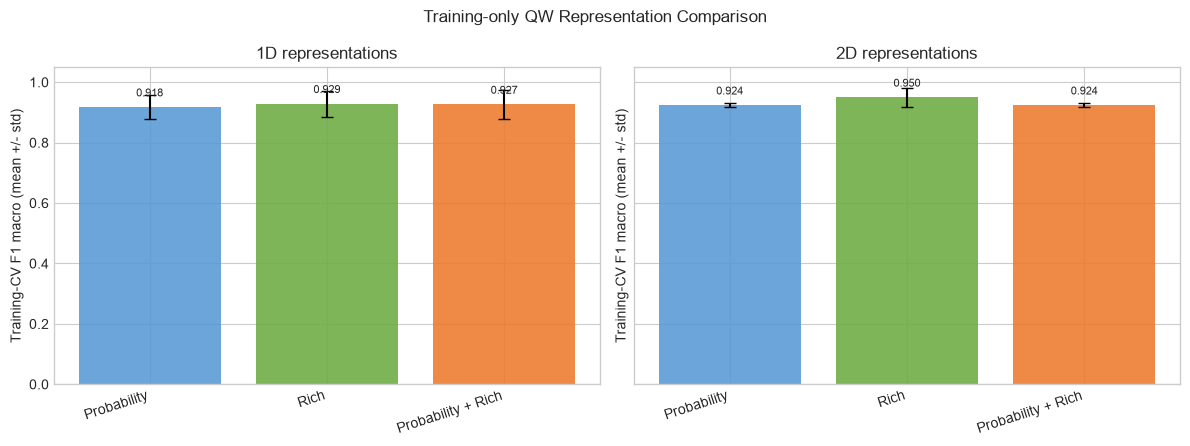

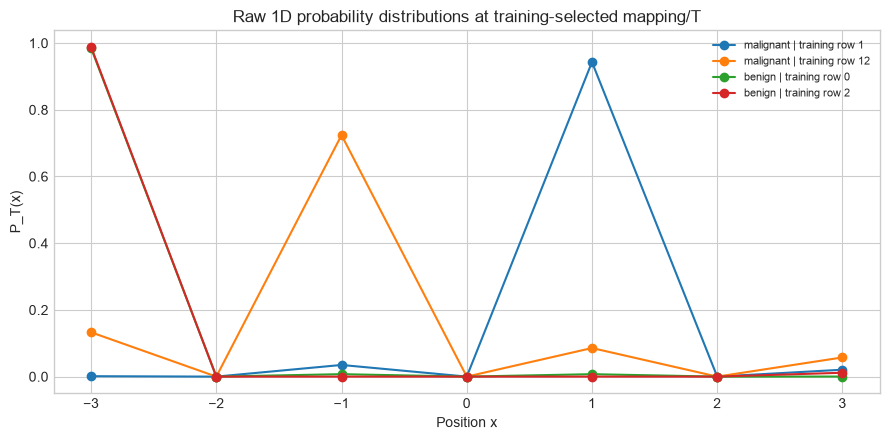

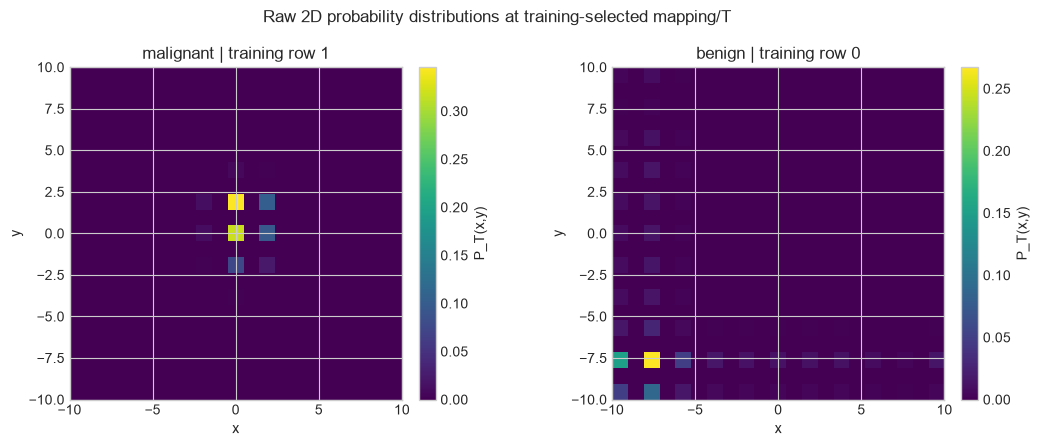

In [38]:
QW_REPRESENTATION_RESULT_COLUMNS = [
    "dimension", "representation_mode", "mapping_id", "mapping", "T",
    "selected_features", "feature_names", "feature_dimension",
    "accuracy_mean", "accuracy_std", "f1_macro_mean", "f1_macro_std",
    "status", "use_mu_chi", "fold_validation_scores",
    "hybrid_fold_validation_scores",
]


def _qw_dimension_configuration(dimension):
    if dimension == "1D":
        return len(PARAMS_1D), PARAMS_1D, PARAM_RANGES_1D, T_MAX_1D
    if dimension == "2D":
        return len(PARAMS_2D), PARAMS_2D, PARAM_RANGES_2D, T_MAX_2D
    raise ValueError("dimension must be '1D' or '2D'.")


def evaluate_qw_representation_modes_cv(
    X_values, y_values, best_configuration, qw_runner, dimension, use_mu_chi=None
):
    """Compare all output modes at one training-selected mapping/T."""
    k, param_order, param_ranges, canonical_T = _qw_dimension_configuration(dimension)
    mapping = dict(best_configuration["mapping"])
    _, parameter_sequence = _mapping_parameter_sequence({"mapping": mapping}, param_order)
    T = int(best_configuration["T"])
    fold_metrics = {mode: [] for mode in QW_REPRESENTATION_MODES}
    hybrid_fold_metrics = {mode: [] for mode in QW_REPRESENTATION_MODES}
    feature_names = {}
    fold_selected_features = []

    for fit_indices, validation_indices in make_stratified_cv().split(X_values, y_values):
        X_fit = X_values.iloc[fit_indices]
        X_validation = X_values.iloc[validation_indices]
        y_fit = _take_rows(y_values, fit_indices)
        y_validation = _take_rows(y_values, validation_indices)
        selected = select_features_mi(X_fit, y_fit, X_validation, k=k)
        selected_names = tuple(selected["selected_feature_names"])
        fold_selected_features.append(selected_names)
        scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
        X_fit_unit = scaler.fit_transform(selected["X_train"])
        X_validation_unit = scaler.transform(selected["X_eval"])
        fold_mapping = dict(zip(selected_names, parameter_sequence))
        fit_parameters = apply_feature_parameter_mapping(
            X_fit_unit, selected_names, fold_mapping, param_order, param_ranges
        )
        validation_parameters = apply_feature_parameter_mapping(
            X_validation_unit, selected_names, fold_mapping, param_order, param_ranges
        )
        fit_representations = build_all_qw_representation_matrices(
            fit_parameters, T, qw_runner, dimension,
            use_mu_chi=True if use_mu_chi is None else use_mu_chi,
            canonical_T=canonical_T,
        )
        validation_representations = build_all_qw_representation_matrices(
            validation_parameters, T, qw_runner, dimension,
            use_mu_chi=True if use_mu_chi is None else use_mu_chi,
            canonical_T=canonical_T,
        )
        for mode in QW_REPRESENTATION_MODES:
            X_fit_qw = fit_representations[mode]
            X_validation_qw = validation_representations[mode]
            if tuple(X_fit_qw.columns) != tuple(X_validation_qw.columns):
                raise ValueError(f"{mode} schemas differ between fit and validation.")
            current_names = tuple(X_fit_qw.columns)
            if mode in feature_names and feature_names[mode] != current_names:
                raise ValueError(f"{mode} schema differs across folds.")
            feature_names[mode] = current_names
            evaluation = evaluate_classifier(
                X_fit_qw, X_validation_qw, y_fit, y_validation
            )
            fold_metrics[mode].append(
                {metric: float(evaluation[metric]) for metric in METRIC_COLUMNS}
            )
            hybrid_evaluation = evaluate_classifier(
                np.hstack([np.asarray(X_fit, dtype=float), X_fit_qw.to_numpy(dtype=float)]),
                np.hstack([np.asarray(X_validation, dtype=float), X_validation_qw.to_numpy(dtype=float)]),
                y_fit, y_validation,
            )
            hybrid_fold_metrics[mode].append(
                {metric: float(hybrid_evaluation[metric]) for metric in METRIC_COLUMNS}
            )

    records = []
    for mode in QW_REPRESENTATION_MODES:
        scores = pd.DataFrame(fold_metrics[mode])
        records.append({
            "dimension": dimension,
            "representation_mode": mode,
            "mapping_id": best_configuration["mapping_id"],
            "mapping": mapping,
            "T": T,
            "selected_features": tuple(fold_selected_features),
            "feature_names": feature_names[mode],
            "feature_dimension": len(feature_names[mode]),
            "accuracy_mean": float(scores["accuracy"].mean()),
            "accuracy_std": float(scores["accuracy"].std(ddof=1)),
            "f1_macro_mean": float(scores["f1_macro"].mean()),
            "f1_macro_std": float(scores["f1_macro"].std(ddof=1)),
            "status": "completed",
            "use_mu_chi": use_mu_chi if dimension == "2D" else None,
            "fold_validation_scores": tuple(fold_metrics[mode]),
            "hybrid_fold_validation_scores": tuple(hybrid_fold_metrics[mode]),
        })
    return pd.DataFrame(records, columns=QW_REPRESENTATION_RESULT_COLUMNS)


def select_primary_qw_representation(results):
    completed = results.loc[results["status"].eq("completed")].copy()
    if completed.empty:
        raise RuntimeError("No QW representation completed successfully.")
    return completed.sort_values(
        ["f1_macro_mean", "accuracy_mean", "feature_dimension", "representation_mode"],
        ascending=[False, False, True, True], kind="mergesort",
    ).iloc[0]


qw_representation_results_1d_df = pd.DataFrame(columns=QW_REPRESENTATION_RESULT_COLUMNS)
qw_representation_results_2d_df = pd.DataFrame(columns=QW_REPRESENTATION_RESULT_COLUMNS)
selected_qw_representation_1d = None
selected_qw_representation_2d = None
selected_qw_representation_result_1d = None
selected_qw_representation_result_2d = None

if RUN_QW_1D_EXPERIMENTS:
    selected_mapping_t_1d = _best_completed_configuration(results_1d_df)
    qw_representation_results_1d_df = evaluate_qw_representation_modes_cv(
        X_train, y_train, selected_mapping_t_1d, quantum_walk_1d, "1D"
    )
    selected_qw_representation_result_1d = select_primary_qw_representation(
        qw_representation_results_1d_df
    )
    selected_qw_representation_1d = str(
        selected_qw_representation_result_1d["representation_mode"]
    )

if RUN_QW_2D_EXPERIMENTS:
    selected_mapping_t_2d = _best_completed_configuration(results_2d_with_mu_chi_df)
    qw_representation_results_2d_df = evaluate_qw_representation_modes_cv(
        X_train, y_train, selected_mapping_t_2d, quantum_walk_2d, "2D", use_mu_chi=True
    )
    selected_qw_representation_result_2d = select_primary_qw_representation(
        qw_representation_results_2d_df
    )
    selected_qw_representation_2d = str(
        selected_qw_representation_result_2d["representation_mode"]
    )

print("1D QW representation ablation (training CV only)")
display(qw_representation_results_1d_df[[
    "dimension", "representation_mode", "mapping_id", "T", "feature_dimension",
    "accuracy_mean", "accuracy_std", "f1_macro_mean", "f1_macro_std", "status"
]])
print("2D QW representation ablation (training CV only)")
display(qw_representation_results_2d_df[[
    "dimension", "representation_mode", "mapping_id", "T", "feature_dimension",
    "accuracy_mean", "accuracy_std", "f1_macro_mean", "f1_macro_std", "status"
]])
print(f"Training-selected 1D representation: {selected_qw_representation_1d}")
print(f"Training-selected 2D representation: {selected_qw_representation_2d}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, dimension, results in (
    (axes[0], "1D", qw_representation_results_1d_df),
    (axes[1], "2D", qw_representation_results_2d_df),
):
    if results.empty:
        ax.text(0.5, 0.5, "Unavailable", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{dimension} representations")
        continue
    x = np.arange(len(results))
    bars = ax.bar(
        x, results["f1_macro_mean"], yerr=results["f1_macro_std"],
        color=["#5B9BD5", "#70AD47", "#ED7D31"], capsize=4, alpha=0.9,
    )
    ax.set_xticks(x, ["Probability", "Rich", "Probability + Rich"], rotation=18, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"{dimension} representations")
    ax.set_ylabel("Training-CV F1 macro (mean +/- std)")
    for bar, value in zip(bars, results["f1_macro_mean"]):
        ax.text(bar.get_x() + bar.get_width() / 2, min(value + 0.035, 1.02),
                f"{value:.3f}", ha="center", fontsize=8)
fig.suptitle("Training-only QW Representation Comparison")
fig.tight_layout()
plt.show()


def _training_parameters_for_best_configuration(best_configuration, dimension):
    k, param_order, param_ranges, _ = _qw_dimension_configuration(dimension)
    selected = select_features_mi(X_train, y_train, X_train, k=k)
    selected_names = tuple(selected["selected_feature_names"])
    _, parameter_sequence = _mapping_parameter_sequence(best_configuration, param_order)
    final_mapping = dict(zip(selected_names, parameter_sequence))
    scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
    X_unit = scaler.fit_transform(selected["X_train"])
    return apply_feature_parameter_mapping(
        X_unit, selected_names, final_mapping, param_order, param_ranges
    )

training_class_positions = {
    class_id: np.flatnonzero(np.asarray(y_train) == class_id)
    for class_id in sorted(np.unique(y_train))
}

if RUN_QW_1D_EXPERIMENTS:
    illustrative_parameters_1d = _training_parameters_for_best_configuration(
        selected_mapping_t_1d, "1D"
    )
    illustrative_rows_1d = [
        int(row) for class_id in training_class_positions
        for row in training_class_positions[class_id][:2]
    ]
    probability_example_outputs_1d = [
        quantum_walk_1d(_parameter_row_to_dict(illustrative_parameters_1d[row], PARAMS_1D),
                        int(selected_mapping_t_1d["T"]))
        for row in illustrative_rows_1d
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for row, output in zip(illustrative_rows_1d, probability_example_outputs_1d):
        validated = validate_quantum_walk_1d_output(output)
        ax.plot(validated["positions"], validated["probabilities"], marker="o",
                label=f"{target_names[int(y_train.iloc[row])]} | training row {row}")
    ax.set_xlabel("Position x")
    ax.set_ylabel("P_T(x)")
    ax.set_title("Raw 1D probability distributions at training-selected mapping/T")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

if RUN_QW_2D_EXPERIMENTS:
    illustrative_parameters_2d = _training_parameters_for_best_configuration(
        selected_mapping_t_2d, "2D"
    )
    illustrative_rows_2d = [int(training_class_positions[class_id][0]) for class_id in training_class_positions]
    probability_example_outputs_2d = [
        quantum_walk_2d(_parameter_row_to_dict(illustrative_parameters_2d[row], PARAMS_2D),
                        int(selected_mapping_t_2d["T"]), use_mu_chi=True)
        for row in illustrative_rows_2d
    ]
    fig, axes = plt.subplots(1, len(illustrative_rows_2d), figsize=(11, 4.5), squeeze=False)
    side = 2 * T_MAX_2D + 1
    for ax, row, output in zip(axes[0], illustrative_rows_2d, probability_example_outputs_2d):
        probability_record = extract_qw_probability_features_2d(output, T_MAX_2D)
        image = np.asarray(list(probability_record.values()), dtype=float).reshape(side, side)
        heatmap = ax.imshow(image.T, origin="lower", extent=[-T_MAX_2D, T_MAX_2D, -T_MAX_2D, T_MAX_2D],
                            cmap="viridis", aspect="equal")
        ax.set_title(f"{target_names[int(y_train.iloc[row])]} | training row {row}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label="P_T(x,y)")
    fig.suptitle("Raw 2D probability distributions at training-selected mapping/T")
    fig.tight_layout()
    plt.show()


# 14. Training-CV Feature-space Overview

This section reports each classical and dimension-specific QW feature space before the reserved Test evaluation. Classical results are always available. Each QW dimension is populated only when its independent training search completes; disabled dimensions retain explicit placeholders rather than synthetic physics scores.


In [39]:
def _overview_rows_for_qw(label, results):
    completed = results.loc[results["status"].eq("completed")]
    if completed.empty:
        return [
            {"feature_space": label, "cv_f1_macro_mean": np.nan,
             "cv_f1_macro_std": np.nan, "status": "disabled or unavailable"},
            {"feature_space": f"Original + {label}",
             "cv_f1_macro_mean": np.nan, "cv_f1_macro_std": np.nan,
             "status": "disabled or unavailable"},
        ]
    best = completed.iloc[0]
    hybrid_scores = np.asarray(
        [record[PRIMARY_METRIC] for record in best["hybrid_fold_validation_scores"]],
        dtype=float,
    )
    return [
        {"feature_space": label,
         "cv_f1_macro_mean": best["f1_macro_mean"],
         "cv_f1_macro_std": best["f1_macro_std"],
         "status": "evaluated on training CV"},
        {"feature_space": f"Original + {label}",
         "cv_f1_macro_mean": hybrid_scores.mean(),
         "cv_f1_macro_std": hybrid_scores.std(ddof=1),
         "status": "evaluated on training CV"},
    ]


feature_space_rows = [
        {
            "feature_space": "Original",
            "cv_f1_macro_mean": original_cv_scores[PRIMARY_METRIC].mean(),
            "cv_f1_macro_std": original_cv_scores[PRIMARY_METRIC].std(ddof=1),
            "status": "evaluated on training CV",
        },
        {
            "feature_space": "Polynomial-2",
            "cv_f1_macro_mean": polynomial_cv_scores[PRIMARY_METRIC].mean(),
            "cv_f1_macro_std": polynomial_cv_scores[PRIMARY_METRIC].std(ddof=1),
            "status": "evaluated on training CV",
        },
]
feature_space_rows.extend(_overview_rows_for_qw("QW-1D", results_1d_df))
feature_space_rows.extend(
    _overview_rows_for_qw("QW-2D", results_2d_with_mu_chi_df)
)
feature_space_comparison = pd.DataFrame(feature_space_rows).set_index("feature_space")
display(feature_space_comparison)


,cv_f1_macro_mean,cv_f1_macro_std,status
feature_space,,,
Original,0.976426,0.011862,evaluated on training CV
Polynomial-2,0.962275,0.010036,evaluated on training CV
QW-1D,0.929153,0.042892,evaluated on training CV
Original + QW-1D,0.973907,0.015697,evaluated on training CV
QW-2D,0.950153,0.030609,evaluated on training CV
Original + QW-2D,0.971790,0.006212,evaluated on training CV


# 15. Paired Statistical-comparison Functions

Cross-validation comparisons use paired fold scores because every method uses the same five stratified training folds. The Wilcoxon signed-rank result is exploratory: five folds provide low power, folds are not independent samples, and QW configurations selected on these scores can be optimistic.

Final-classifier comparisons use an exact McNemar-style binomial test on paired correctness indicators for the same reserved Test samples. A single accuracy or F1 value is never treated as sufficient evidence of significance. Functions return explicit warnings when paired vectors are missing, incompatible, or too sparse.


In [40]:
STATISTICAL_RESULT_COLUMNS = [
    "method_A",
    "method_B",
    "metric",
    "test_name",
    "statistic",
    "p_value",
    "alpha",
    "significant",
    "n_pairs",
    "warning",
]


def _statistical_warning_record(
    method_A,
    method_B,
    metric,
    test_name,
    warning,
    alpha=ALPHA,
    n_pairs=0,
):
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": metric,
        "test_name": test_name,
        "statistic": np.nan,
        "p_value": np.nan,
        "alpha": float(alpha),
        "significant": False,
        "n_pairs": int(n_pairs),
        "warning": warning,
    }


def paired_wilcoxon_comparison(
    method_A,
    method_B,
    metric,
    scores_A,
    scores_B,
    alpha=ALPHA,
):
    """Compare metric values from the same predefined validation folds."""
    test_name = "Wilcoxon signed-rank"
    if scores_A is None or scores_B is None:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: paired fold scores are unavailable",
            alpha,
        )
    try:
        scores_A = np.asarray(scores_A, dtype=float)
        scores_B = np.asarray(scores_B, dtype=float)
    except (TypeError, ValueError):
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: fold scores are not numeric",
            alpha,
        )
    if scores_A.ndim != 1 or scores_B.ndim != 1 or len(scores_A) != len(scores_B):
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: paired score vectors must be one-dimensional and equal length",
            alpha,
        )
    finite = np.isfinite(scores_A) & np.isfinite(scores_B)
    n_pairs = int(finite.sum())
    if n_pairs != len(scores_A) or n_pairs < N_SPLITS:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            f"not computed: expected {N_SPLITS} finite paired fold scores",
            alpha,
            n_pairs,
        )

    differences = scores_A - scores_B
    nonzero_count = int(np.sum(np.abs(differences) > EPSILON))
    warning = (
        "exploratory: only five folds are available and folds are not independent; "
        "when a QW method is present, selection on these CV results may add optimism"
    )
    if nonzero_count == 0:
        statistic, p_value = 0.0, 1.0
        warning += "; all paired differences are zero"
    elif nonzero_count < 3:
        return _statistical_warning_record(
            method_A,
            method_B,
            metric,
            test_name,
            "not computed: fewer than three non-zero paired differences",
            alpha,
            n_pairs,
        )
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            statistic, p_value = wilcoxon(
                scores_A,
                scores_B,
                zero_method="wilcox",
                alternative="two-sided",
                method="auto",
            )
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": metric,
        "test_name": test_name,
        "statistic": float(statistic),
        "p_value": float(p_value),
        "alpha": float(alpha),
        "significant": bool(p_value < alpha),
        "n_pairs": n_pairs,
        "warning": warning,
    }


def exact_mcnemar_comparison(
    method_A,
    method_B,
    correctness_A,
    correctness_B,
    alpha=ALPHA,
):
    """Exact paired test using discordant correctness on identical Test samples."""
    test_name = "Exact McNemar (binomial)"
    if correctness_A is None or correctness_B is None:
        return _statistical_warning_record(
            method_A,
            method_B,
            "correctness",
            test_name,
            "not computed: final-sample correctness vectors are unavailable",
            alpha,
        )
    correctness_A = np.asarray(correctness_A)
    correctness_B = np.asarray(correctness_B)
    if (
        correctness_A.ndim != 1
        or correctness_B.ndim != 1
        or len(correctness_A) != len(correctness_B)
        or len(correctness_A) == 0
    ):
        return _statistical_warning_record(
            method_A,
            method_B,
            "correctness",
            test_name,
            "not computed: correctness vectors must cover the same non-empty Test samples",
            alpha,
        )
    correctness_A = correctness_A.astype(bool)
    correctness_B = correctness_B.astype(bool)
    A_only_correct = int(np.sum(correctness_A & ~correctness_B))
    B_only_correct = int(np.sum(~correctness_A & correctness_B))
    discordant = A_only_correct + B_only_correct
    if discordant == 0:
        statistic, p_value = 0.0, 1.0
        warning = "no discordant Test-sample predictions; exact p-value is 1"
    else:
        statistic = float(min(A_only_correct, B_only_correct))
        p_value = float(
            binomtest(
                int(statistic),
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )
        warning = (
            f"exact test is valid with {discordant} discordant pairs, but power may be low"
            if discordant < 10
            else None
        )
    return {
        "method_A": method_A,
        "method_B": method_B,
        "metric": "correctness",
        "test_name": test_name,
        "statistic": float(statistic),
        "p_value": float(p_value),
        "alpha": float(alpha),
        "significant": bool(p_value < alpha),
        "n_pairs": int(len(correctness_A)),
        "warning": warning,
    }


# 16. Professional Training-CV Visualizations

Plots A–F use training-CV results only and show mean ± one fold standard deviation where available. For each $T$, the QW curves show the highest-ranked mapping at that $T$; they are descriptive views of the training search and not independent estimates of generalization. Mapping plots show each mapping's best evaluated $T$.

Each QW dimension is plotted independently. A disabled or unavailable dimension renders a clearly labeled placeholder while completed dimensions and the classical comparison remain available. Plot G, the selected-2D-feature correlation heatmap, is already rendered in Section 9.1 from training data only.


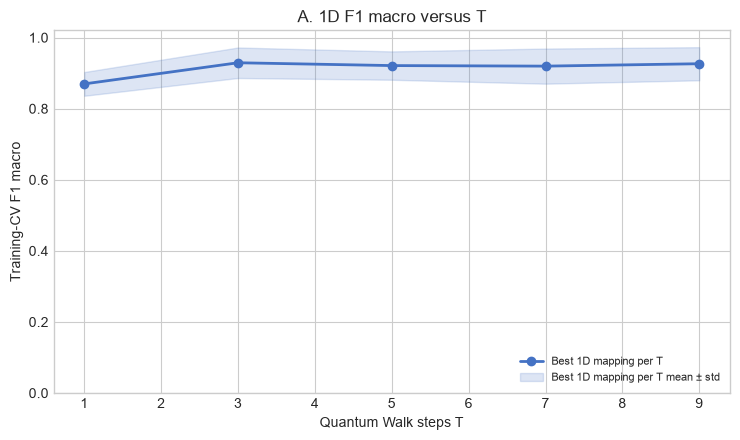

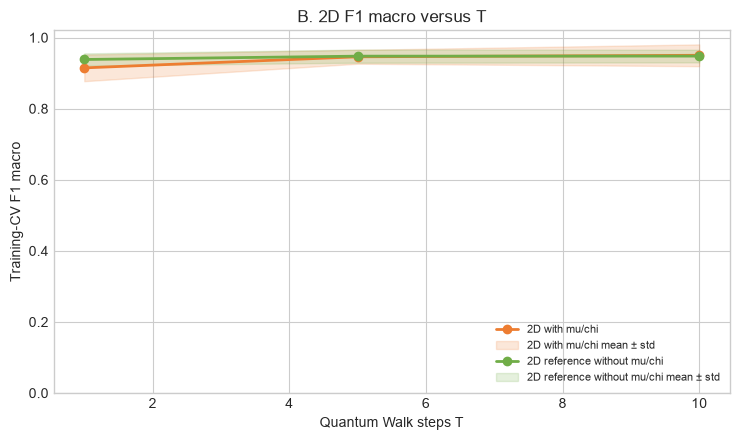

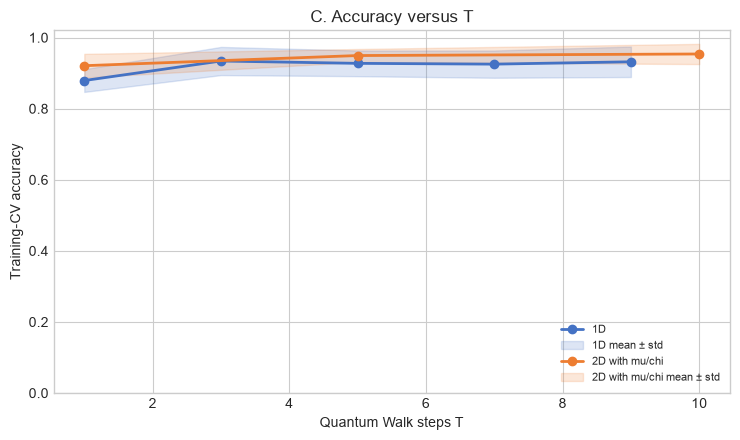

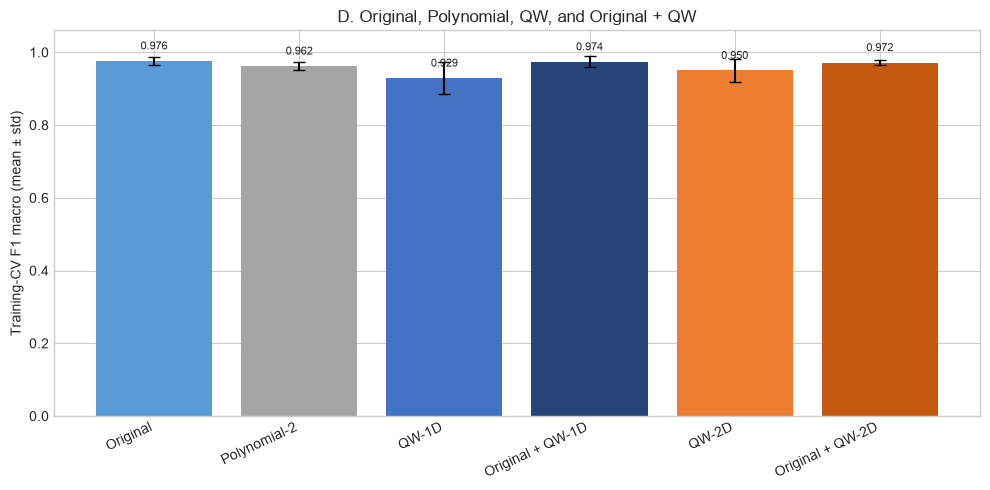

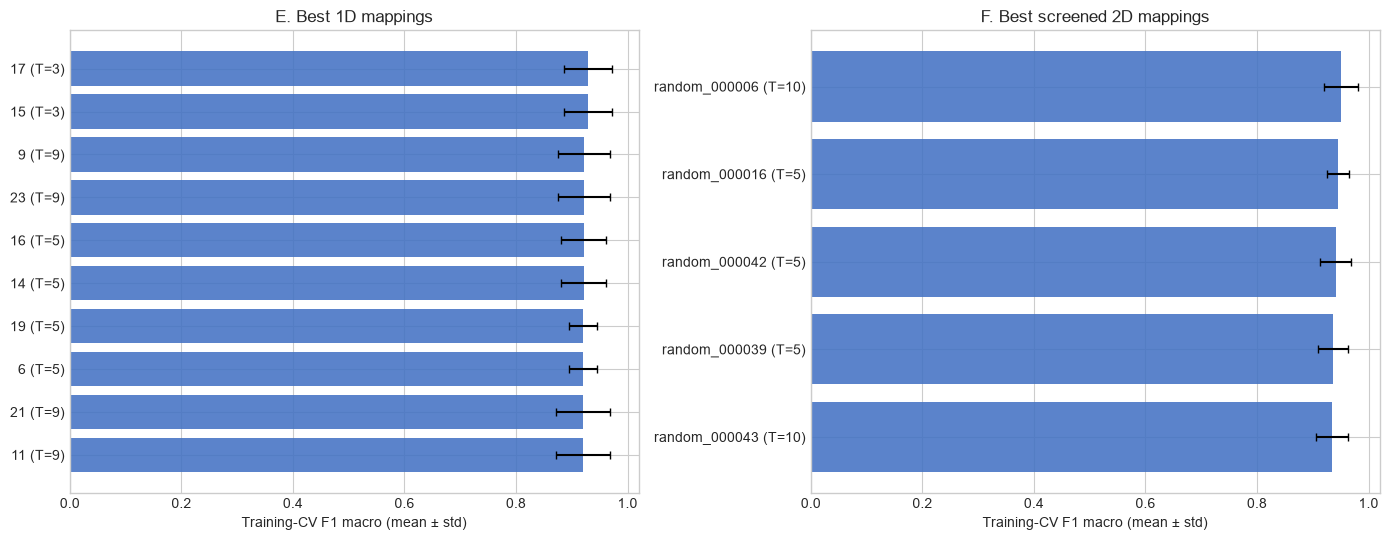

G. The selected-feature absolute-correlation heatmap is rendered in Section 9.1 from training data only.


In [41]:
def _completed_qw_results(results):
    if results is None or results.empty:
        return pd.DataFrame()
    return results.loc[results["status"].eq("completed")].copy()


def _best_configuration_per_T(results, metric_mean):
    completed = _completed_qw_results(results)
    if completed.empty:
        return completed
    return (
        completed.sort_values(
            ["T", metric_mean, "accuracy_mean"],
            ascending=[True, False, False],
            kind="mergesort",
        )
        .drop_duplicates("T")
        .sort_values("T")
    )


def _draw_unavailable(ax, title):
    ax.set_title(title)
    ax.text(
        0.5,
        0.5,
        "Available after external QW integration",
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="dimgray",
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("lightgray")


def _plot_best_metric_vs_T(ax, results, metric, label, color):
    best_by_T = _best_configuration_per_T(results, f"{metric}_mean")
    if best_by_T.empty:
        return False
    x = best_by_T["T"].to_numpy(dtype=float)
    mean = best_by_T[f"{metric}_mean"].to_numpy(dtype=float)
    std = best_by_T[f"{metric}_std"].to_numpy(dtype=float)
    ax.plot(x, mean, marker="o", linewidth=2, label=label, color=color)
    ax.fill_between(
        x,
        np.clip(mean - std, 0.0, 1.0),
        np.clip(mean + std, 0.0, 1.0),
        alpha=0.18,
        color=color,
        label=f"{label} mean ± std",
    )
    return True


def _fold_summary_from_result(result, field, metric):
    values = np.asarray([row[metric] for row in result[field]], dtype=float)
    return float(values.mean()), float(values.std(ddof=1))


def _cv_feature_space_plot_table():
    rows = [
        {
            "feature_space": "Original",
            "f1_macro_mean": original_cv_scores[PRIMARY_METRIC].mean(),
            "f1_macro_std": original_cv_scores[PRIMARY_METRIC].std(ddof=1),
        },
        {
            "feature_space": "Polynomial-2",
            "f1_macro_mean": polynomial_cv_scores[PRIMARY_METRIC].mean(),
            "f1_macro_std": polynomial_cv_scores[PRIMARY_METRIC].std(ddof=1),
        },
    ]
    for label, results in (
        ("QW-1D", results_1d_df),
        ("QW-2D", results_2d_with_mu_chi_df),
    ):
        completed = _completed_qw_results(results)
        if not completed.empty:
            best = completed.iloc[0]
            rows.append(
                {
                    "feature_space": label,
                    "f1_macro_mean": best["f1_macro_mean"],
                    "f1_macro_std": best["f1_macro_std"],
                }
            )
            hybrid_mean, hybrid_std = _fold_summary_from_result(
                best, "hybrid_fold_validation_scores", PRIMARY_METRIC
            )
            rows.append(
                {
                    "feature_space": f"Original + {label}",
                    "f1_macro_mean": hybrid_mean,
                    "f1_macro_std": hybrid_std,
                }
            )
        else:
            for unavailable_label in (label, f"Original + {label}"):
                rows.append(
                    {
                        "feature_space": unavailable_label,
                        "f1_macro_mean": np.nan,
                        "f1_macro_std": np.nan,
                    }
                )
    order = [
        "Original",
        "Polynomial-2",
        "QW-1D",
        "Original + QW-1D",
        "QW-2D",
        "Original + QW-2D",
    ]
    return pd.DataFrame(rows).set_index("feature_space").reindex(order).reset_index()


def _plot_top_mappings(ax, results, title, top_n=10):
    completed = _completed_qw_results(results)
    if completed.empty:
        _draw_unavailable(ax, title)
        return
    best_per_mapping = (
        completed.sort_values(
            ["f1_macro_mean", "accuracy_mean"],
            ascending=[False, False],
            kind="mergesort",
        )
        .drop_duplicates("mapping_id")
        .head(top_n)
        .sort_values("f1_macro_mean")
    )
    labels = [f"{mapping_id} (T={T})" for mapping_id, T in zip(
        best_per_mapping["mapping_id"], best_per_mapping["T"]
    )]
    ax.barh(
        labels,
        best_per_mapping["f1_macro_mean"],
        xerr=best_per_mapping["f1_macro_std"],
        color="#4472C4",
        alpha=0.88,
        capsize=3,
    )
    ax.set_xlim(0.0, 1.02)
    ax.set_xlabel("Training-CV F1 macro (mean ± std)")
    ax.set_title(title)


# A. F1 macro versus T for 1D.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
if _plot_best_metric_vs_T(
    ax, results_1d_df, "f1_macro", "Best 1D mapping per T", "#4472C4"
):
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV F1 macro")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("A. 1D F1 macro versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "A. 1D F1 macro versus T")
fig.tight_layout()
plt.show()


# B. F1 macro versus T for 2D, including the reference condition when available.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plotted_2d = _plot_best_metric_vs_T(
    ax,
    results_2d_with_mu_chi_df,
    "f1_macro",
    "2D with mu/chi",
    "#ED7D31",
)
plotted_2d |= _plot_best_metric_vs_T(
    ax,
    results_2d_without_mu_chi_df,
    "f1_macro",
    "2D reference without mu/chi",
    "#70AD47",
)
if plotted_2d:
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV F1 macro")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("B. 2D F1 macro versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "B. 2D F1 macro versus T")
fig.tight_layout()
plt.show()


# C. Accuracy versus T for both dimensions.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plotted_accuracy = _plot_best_metric_vs_T(
    ax, results_1d_df, "accuracy", "1D", "#4472C4"
)
plotted_accuracy |= _plot_best_metric_vs_T(
    ax, results_2d_with_mu_chi_df, "accuracy", "2D with mu/chi", "#ED7D31"
)
if plotted_accuracy:
    ax.set_xlabel("Quantum Walk steps T")
    ax.set_ylabel("Training-CV accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.set_title("C. Accuracy versus T")
    ax.legend(loc="lower right", fontsize=8)
else:
    _draw_unavailable(ax, "C. Accuracy versus T")
fig.tight_layout()
plt.show()


# D. Four conceptual feature spaces, with 1D and 2D QW variants shown separately.
cv_feature_space_plot_df = _cv_feature_space_plot_table()
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(cv_feature_space_plot_df))
means = cv_feature_space_plot_df["f1_macro_mean"].to_numpy(dtype=float)
stds = cv_feature_space_plot_df["f1_macro_std"].to_numpy(dtype=float)
bars = ax.bar(
    x_positions,
    np.nan_to_num(means, nan=0.0),
    yerr=np.nan_to_num(stds, nan=0.0),
    color=["#5B9BD5", "#A5A5A5", "#4472C4", "#264478", "#ED7D31", "#C65911"],
    capsize=4,
)
for index, (bar, value) in enumerate(zip(bars, means)):
    if np.isfinite(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.025, 1.01),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    else:
        ax.text(index, 0.03, "N/A", ha="center", va="bottom", color="dimgray")
ax.set_xticks(x_positions)
ax.set_xticklabels(cv_feature_space_plot_df["feature_space"], rotation=25, ha="right")
ax.set_ylim(0.0, 1.06)
ax.set_ylabel("Training-CV F1 macro (mean ± std)")
ax.set_title("D. Original, Polynomial, QW, and Original + QW")
fig.tight_layout()
plt.show()


# E-F. Best mappings after training-only evaluation.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
_plot_top_mappings(axes[0], results_1d_df, "E. Best 1D mappings")
_plot_top_mappings(
    axes[1], results_2d_with_mu_chi_df, "F. Best screened 2D mappings"
)
fig.tight_layout()
plt.show()

print(
    "G. The selected-feature absolute-correlation heatmap is rendered in "
    "Section 9.1 from training data only."
)


# 17. Final Six-space Test Evaluation

This is the first section that transforms or evaluates the reserved Test set. Every feature space uses the original stratified split, the same metrics, and the same `StandardScaler` + `LogisticRegression` evaluator.

`Original` and `Polynomial-2` retain all 30 classical inputs. `QW-1D` is generated from four training-selected classical inputs, while `QW-2D` is generated from ten. The hybrid rows retain all 30 original inputs and append the corresponding QW representation. `source_feature_count` counts unique classical inputs available to the whole model; `qw_source_feature_count` separately exposes the four- versus ten-feature QW branch.

QW Test features are created only from the rank-one mapping and $T$ found by training-only validation. Mutual-information selection and min–max encoding are re-fitted on all training data, and the fitted transforms are applied to the Test inputs exactly once. Test labels never participate in selection, mapping, $T$, scaling, or feature generation.


In [42]:
FINAL_COMPARISON_COLUMNS = [
    "dimension",
    "feature_space",
    "selected_features",
    "source_feature_count",
    "qw_source_feature_count",
    "mapping_id",
    "T",
    "representation_mode",
    "final_dimension",
    "accuracy",
    "f1_macro",
    "f1_malignant",
    "precision_malignant",
    "recall_malignant",
    "status",
]


def evaluate_final_feature_space(
    X_fit,
    X_evaluation,
    y_fit,
    y_evaluation,
    *,
    dimension,
    feature_space,
    selected_features,
    source_feature_count,
    qw_source_feature_count=None,
    mapping_id=None,
    T=None,
    representation_mode=None,
    prediction_store=None,
):
    """Evaluate one fixed feature space with the shared classifier architecture."""
    X_fit_array = np.asarray(X_fit, dtype=float)
    X_evaluation_array = np.asarray(X_evaluation, dtype=float)
    
    evaluation = evaluate_classifier(
        X_fit_array,
        X_evaluation_array,
        y_fit,
        y_evaluation,
    )
    if prediction_store is not None:
        y_true = np.asarray(y_evaluation)
        predictions = np.asarray(evaluation["predictions"])
        prediction_store[feature_space] = {
            "predictions": predictions.copy(),
            "correctness": (predictions == y_true),
            "y_true": y_true.copy(),
        }
    return {
        "dimension": dimension,
        "feature_space": feature_space,
        "selected_features": selected_features,
        "source_feature_count": int(source_feature_count),
        "qw_source_feature_count": (
            None
            if qw_source_feature_count is None
            else int(qw_source_feature_count)
        ),
        "mapping_id": mapping_id,
        "T": None if T is None else int(T),
        "representation_mode": representation_mode,
        "final_dimension": int(X_fit_array.shape[1]),
        **{metric: float(evaluation[metric]) for metric in METRIC_COLUMNS},
        "status": "evaluated on reserved Test set",
    }


def _unavailable_final_qw_record(
    *,
    dimension,
    feature_space,
    selected_features,
    source_feature_count,
    hybrid,
):
    return {
        "dimension": dimension,
        "feature_space": feature_space,
        "selected_features": selected_features,
        "source_feature_count": int(X_train.shape[1] if hybrid else source_feature_count),
        "qw_source_feature_count": int(source_feature_count),
        "mapping_id": None,
        "T": None,
        "representation_mode": None,
        "final_dimension": np.nan,
        **{metric: np.nan for metric in METRIC_COLUMNS},
        "status": "not evaluated: external QW runner/search result unavailable",
    }


def _best_training_only_configuration(results, expected_dimension):
    """Read the top configuration from training-CV results only."""
    best = _best_completed_configuration(results)
    return best


def build_final_qw_train_test_features(
    X_training,
    y_training,
    X_test_reserved,
    *,
    best_configuration,
    qw_runner,
    dimension,
    use_mu_chi=None,
    representation_mode="rich",
):
    """Fit all classical preprocessing on training data, then transform Test once."""
    if dimension == "1D":
        k = len(PARAMS_1D)
        param_order = PARAMS_1D
        param_ranges = PARAM_RANGES_1D
    elif dimension == "2D":
        k = len(PARAMS_2D)
        param_order = PARAMS_2D
        param_ranges = PARAM_RANGES_2D
    mapping = dict(best_configuration["mapping"])
    _, parameter_sequence = _mapping_parameter_sequence(
        {"mapping": mapping}, param_order
    )

    # y_test is intentionally absent: selection sees training labels only.
    selected = select_features_mi(
        X_training,
        y_training,
        X_test_reserved,
        k=k,
    )
    selected_names = tuple(selected["selected_feature_names"])
    final_mapping = dict(zip(selected_names, parameter_sequence))

    scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
    X_training_unit = scaler.fit_transform(selected["X_train"])
    X_test_unit = scaler.transform(selected["X_eval"])
    training_parameters = apply_feature_parameter_mapping(
        X_training_unit,
        selected_names,
        final_mapping,
        param_order,
        param_ranges,
    )
    test_parameters = apply_feature_parameter_mapping(
        X_test_unit,
        selected_names,
        final_mapping,
        param_order,
        param_ranges,
    )

    T = int(best_configuration["T"])
    canonical_T = T_MAX_1D if dimension == "1D" else T_MAX_2D
    training_representations = build_all_qw_representation_matrices(
        training_parameters, T, qw_runner, dimension,
        use_mu_chi=True if use_mu_chi is None else use_mu_chi,
        canonical_T=canonical_T,
    )
    test_representations = build_all_qw_representation_matrices(
        test_parameters, T, qw_runner, dimension,
        use_mu_chi=True if use_mu_chi is None else use_mu_chi,
        canonical_T=canonical_T,
    )
    X_training_qw = training_representations[representation_mode]
    X_test_qw = test_representations[representation_mode]
    if tuple(X_training_qw.columns) != tuple(X_test_qw.columns):
        raise ValueError("Training and Test QW feature schemas differ.")

    return {
        "X_training": X_training_qw,
        "X_test": X_test_qw,
        "selected_features": selected_names,
        "mapping": final_mapping,
        "mapping_id": best_configuration["mapping_id"],
        "T": T,
        "representation_mode": representation_mode,
        "qw_feature_names": tuple(X_training_qw.columns),
        "representations_training": training_representations,
        "representations_test": test_representations,
        "selector": selected["selector"],
        "minmax_scaler": scaler,
    }


def concatenate_original_and_qw(X_original_values, X_qw_values):
    """Concatenate by row position and use distinct, auditable column prefixes."""
    original_array = np.asarray(X_original_values, dtype=float)
    qw_array = np.asarray(X_qw_values, dtype=float)
    combined = np.hstack([original_array, qw_array])
    return combined


def append_qw_final_comparisons(
    records,
    *,
    dimension,
    training_results,
    qw_runner,
    use_mu_chi=None,
    representation_mode="rich",
    prediction_store=None,
):
    """Evaluate QW-only and Original+QW from one fixed training-selected setup."""
    best = _best_training_only_configuration(training_results, dimension)
    artifacts = build_final_qw_train_test_features(
        X_train,
        y_train,
        X_test,
        best_configuration=best,
        qw_runner=qw_runner,
        dimension=dimension,
        use_mu_chi=use_mu_chi,
        representation_mode=representation_mode,
    )
    label = "1D" if dimension == "1D" else "2D"
    source_count = len(PARAMS_1D) if dimension == "1D" else len(PARAMS_2D)

    records.append(
        evaluate_final_feature_space(
            artifacts["X_training"],
            artifacts["X_test"],
            y_train,
            y_test,
            dimension=dimension,
            feature_space=f"QW-{label}",
            selected_features=artifacts["selected_features"],
            source_feature_count=source_count,
            qw_source_feature_count=source_count,
            mapping_id=artifacts["mapping_id"],
            T=artifacts["T"],
            representation_mode=representation_mode,
            prediction_store=prediction_store,
        )
    )

    X_training_combined = concatenate_original_and_qw(
        X_train, artifacts["X_training"]
    )
    X_test_combined = concatenate_original_and_qw(X_test, artifacts["X_test"])
    records.append(
        evaluate_final_feature_space(
            X_training_combined,
            X_test_combined,
            y_train,
            y_test,
            dimension=dimension,
            feature_space=f"Original + QW-{label}",
            selected_features={
                "original": tuple(X_train.columns),
                "qw_branch": artifacts["selected_features"],
            },
            # Unique classical source variables remain the original 30; the
            # separate branch-count column shows 4 versus 10 for QW.
            source_feature_count=X_train.shape[1],
            qw_source_feature_count=source_count,
            mapping_id=artifacts["mapping_id"],
            T=artifacts["T"],
            representation_mode=representation_mode,
            prediction_store=prediction_store,
        )
    )
    return artifacts


# This is the first post-split section that transforms or evaluates X_test.
final_comparison_records = []
final_prediction_store = {}

# The classical baselines retain all 30 inputs and are not compressed.
final_comparison_records.append(
    evaluate_final_feature_space(
        X_train,
        X_test,
        y_train,
        y_test,
        dimension="Classical",
        feature_space="Original",
        selected_features=tuple(X_train.columns),
        source_feature_count=X_train.shape[1],
        prediction_store=final_prediction_store,
    )
)

final_polynomial_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_polynomial_final = final_polynomial_transformer.fit_transform(X_train)
X_test_polynomial_final = final_polynomial_transformer.transform(X_test)
final_comparison_records.append(
    evaluate_final_feature_space(
        X_train_polynomial_final,
        X_test_polynomial_final,
        y_train,
        y_test,
        dimension="Classical",
        feature_space="Polynomial-2",
        selected_features=tuple(X_train.columns),
        source_feature_count=X_train.shape[1],
        prediction_store=final_prediction_store,
    )
)

def _append_unavailable_dimension_records(dimension, source_count, selected_names):
    final_comparison_records.append(
        _unavailable_final_qw_record(
            dimension=dimension,
            feature_space=f"QW-{dimension}",
            selected_features=selected_names,
            source_feature_count=source_count,
            hybrid=False,
        )
    )
    final_comparison_records.append(
        _unavailable_final_qw_record(
            dimension=dimension,
            feature_space=f"Original + QW-{dimension}",
            selected_features={
                "original": tuple(X_train.columns),
                "qw_branch": selected_names,
            },
            source_feature_count=source_count,
            hybrid=True,
        )
    )


final_qw_artifacts = {}
if RUN_QW_1D_EXPERIMENTS:
    final_qw_artifacts["1D"] = append_qw_final_comparisons(
        final_comparison_records,
        dimension="1D",
        training_results=results_1d_df,
        qw_runner=quantum_walk_1d,
        representation_mode=selected_qw_representation_1d,
        prediction_store=final_prediction_store,
    )
else:
    _append_unavailable_dimension_records(
        "1D", len(PARAMS_1D), tuple(features_1d["names"])
    )

if RUN_QW_2D_EXPERIMENTS:
    final_qw_artifacts["2D"] = append_qw_final_comparisons(
        final_comparison_records,
        dimension="2D",
        training_results=results_2d_with_mu_chi_df,
        qw_runner=quantum_walk_2d,
        use_mu_chi=True,
        representation_mode=selected_qw_representation_2d,
        prediction_store=final_prediction_store,
    )
else:
    _append_unavailable_dimension_records(
        "2D", len(PARAMS_2D), tuple(features_2d["names"])
    )

final_comparison_df = pd.DataFrame(
    final_comparison_records,
    columns=FINAL_COMPARISON_COLUMNS,
)
final_test_results = final_comparison_df  # Backward-compatible notebook alias.

display(final_comparison_df)

final_qw_representation_diagnostic_rows = []
for dimension, artifacts in final_qw_artifacts.items():
    for mode in QW_REPRESENTATION_MODES:
        evaluation = evaluate_classifier(
            artifacts["representations_training"][mode],
            artifacts["representations_test"][mode],
            y_train, y_test,
        )
        final_qw_representation_diagnostic_rows.append({
            "dimension": dimension,
            "representation_mode": mode,
            "training_selected_primary": mode == artifacts["representation_mode"],
            "mapping_id": artifacts["mapping_id"],
            "T": artifacts["T"],
            "feature_dimension": artifacts["representations_training"][mode].shape[1],
            **{metric: float(evaluation[metric]) for metric in METRIC_COLUMNS},
            "status": "Post-selection diagnostic only — not used for model selection",
        })
final_qw_representation_diagnostic_df = pd.DataFrame(
    final_qw_representation_diagnostic_rows
)
print("Post-selection diagnostic only — not used for model selection")
display(final_qw_representation_diagnostic_df)


,dimension,feature_space,selected_features,source_feature_count,qw_source_feature_count,mapping_id,T,representation_mode,final_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant,status
0,Classical,Original,"(mean radius, mean texture, mean perimeter, me...",30,NaN,None,NaN,NaN,30,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
1,Classical,Polynomial-2,"(mean radius, mean texture, mean perimeter, me...",30,NaN,None,NaN,NaN,495,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
2,1D,QW-1D,"(mean concave points, worst radius, worst peri...",4,4.0,17,3.0,rich,8,0.921053,0.916361,0.896552,0.866667,0.928571,evaluated on reserved Test set
3,1D,Original + QW-1D,"{'original': ('mean radius', 'mean texture', '...",30,4.0,17,3.0,rich,38,0.982456,0.981151,0.976190,0.976190,0.976190,evaluated on reserved Test set
4,2D,QW-2D,"(mean radius, mean perimeter, mean area, mean ...",10,10.0,random_000006,10.0,rich,9,0.938596,0.934348,0.917647,0.906977,0.928571,evaluated on reserved Test set
5,2D,Original + QW-2D,"{'original': ('mean radius', 'mean texture', '...",30,10.0,random_000006,10.0,rich,39,0.964912,0.962660,0.953488,0.931818,0.976190,evaluated on reserved Test set


Post-selection diagnostic only — not used for model selection


,dimension,representation_mode,training_selected_primary,mapping_id,T,feature_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant,status
0,1D,probability,False,17,3,19,0.894737,0.890665,0.869565,0.800000,0.952381,Post-selection diagnostic only — not used for ...
1,1D,rich,True,17,3,8,0.921053,0.916361,0.896552,0.866667,0.928571,Post-selection diagnostic only — not used for ...
2,1D,probability_plus_rich,False,17,3,27,0.921053,0.916361,0.896552,0.866667,0.928571,Post-selection diagnostic only — not used for ...
3,2D,probability,False,random_000006,10,441,0.929825,0.924603,0.904762,0.904762,0.904762,Post-selection diagnostic only — not used for ...
4,2D,rich,True,random_000006,10,9,0.938596,0.934348,0.917647,0.906977,0.928571,Post-selection diagnostic only — not used for ...
5,2D,probability_plus_rich,False,random_000006,10,450,0.929825,0.924603,0.904762,0.904762,0.904762,Post-selection diagnostic only — not used for ...


# 17.1 Feature-count-matched Classical Ablation

This section compares the fixed classical classifier and its degree-2 polynomial expansion using 4, 10, and all 30 source features. During training CV, mutual-information selection is fitted independently inside every fit fold. The reserved Test set is transformed only by selectors fitted on the full training partition.

The QW values in the matched plots are a frozen aggregate snapshot of the completed searches above. This allows the inexpensive classical ablations and their plots to be rerun without repeating any Quantum Walk evolution. The snapshot fingerprint locks the split, selected feature names, mapping IDs, and selected $T$ values used by the preserved run.


Classical feature-count ablation: training-only 5-fold CV


,feature_space,source_feature_count,final_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_malignant_mean,f1_malignant_std,precision_malignant_mean,precision_malignant_std,recall_malignant_mean,recall_malignant_std
0,Classical-4,4,4,0.936264,0.028444,0.931557,0.030962,0.913691,0.039873,0.923666,0.047133,0.905882,0.056575
1,Polynomial-2-4,4,14,0.931868,0.028444,0.926939,0.030687,0.908057,0.039048,0.918261,0.052886,0.900000,0.049215
2,Classical-10,10,10,0.936264,0.009194,0.931721,0.010432,0.914164,0.014277,0.918054,0.019591,0.911765,0.041595
3,Polynomial-2-10,10,65,0.940659,0.016666,0.936549,0.017596,0.920468,0.021794,0.925585,0.047064,0.917647,0.038348
4,Classical-30,30,30,0.978022,0.010989,0.976426,0.011862,0.970308,0.015085,0.976975,0.023958,0.964706,0.032219
5,Polynomial-2-30,30,495,0.964835,0.009194,0.962275,0.010036,0.952473,0.013003,0.959446,0.025324,0.947059,0.038348


Classical feature-count ablation: reserved Test set


,feature_space,selected_features,source_feature_count,final_dimension,accuracy,f1_macro,f1_malignant,precision_malignant,recall_malignant
0,Classical-4,"(mean concave points, worst radius, worst peri...",4,4,0.947368,0.943990,0.930233,0.909091,0.952381
1,Polynomial-2-4,"(mean concave points, worst radius, worst peri...",4,14,0.938596,0.934348,0.917647,0.906977,0.928571
2,Classical-10,"(mean radius, mean perimeter, mean area, mean ...",10,10,0.956140,0.953106,0.941176,0.930233,0.952381
3,Polynomial-2-10,"(mean radius, mean perimeter, mean area, mean ...",10,65,0.964912,0.962302,0.952381,0.952381,0.952381
4,Classical-30,"(mean radius, mean texture, mean perimeter, me...",30,30,0.982456,0.981151,0.976190,0.976190,0.976190
5,Polynomial-2-30,"(mean radius, mean texture, mean perimeter, me...",30,495,0.982456,0.981151,0.976190,0.976190,0.976190


QW bars use the preserved completed-run aggregate snapshot; no QW evolution was rerun.


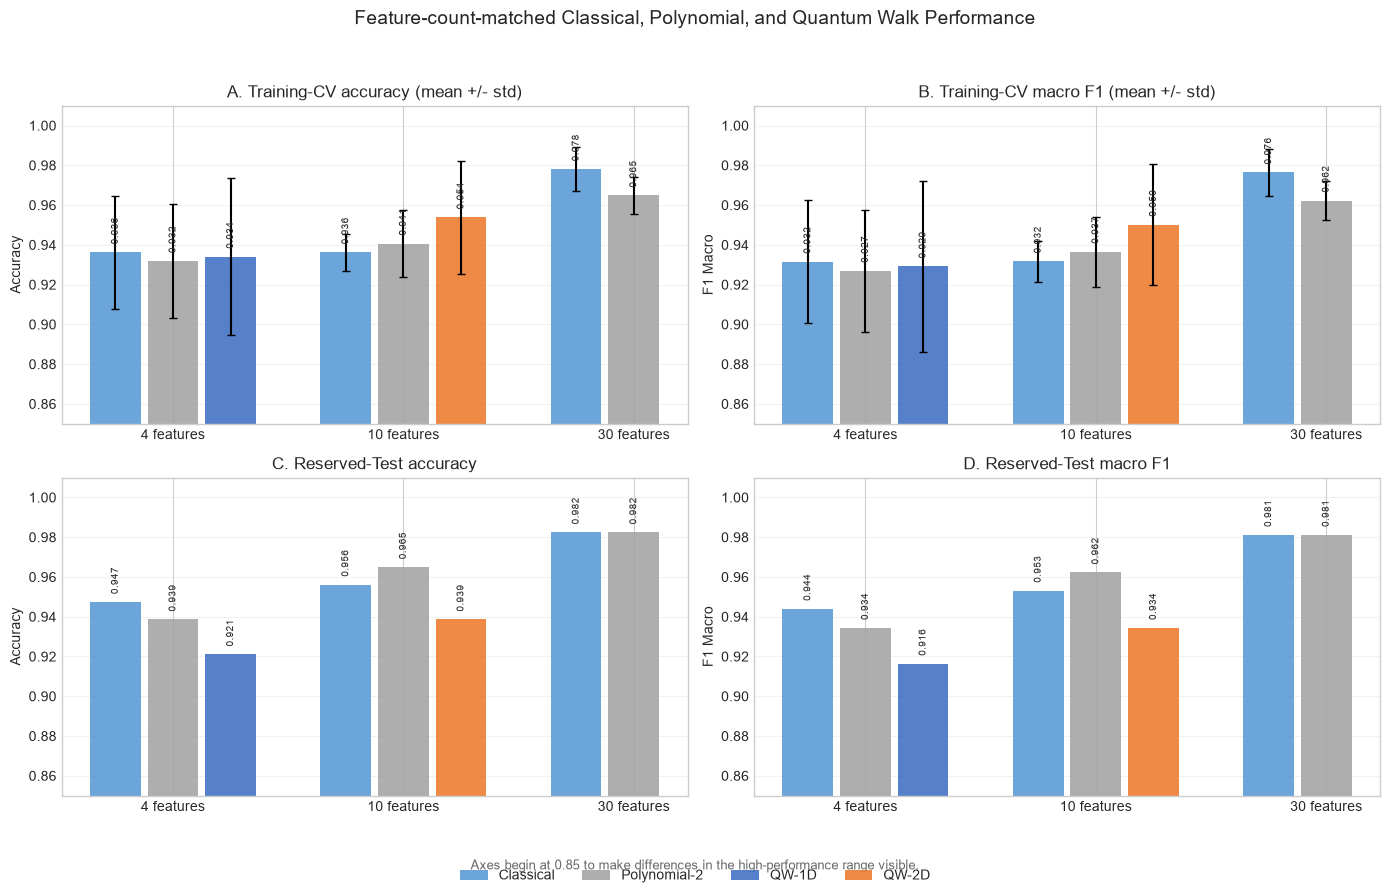

In [43]:
CLASSICAL_ABLATION_SPECS = [
    ("Classical-4", 4, False),
    ("Polynomial-2-4", 4, True),
    ("Classical-10", 10, False),
    ("Polynomial-2-10", 10, True),
    ("Classical-30", 30, False),
    ("Polynomial-2-30", 30, True),
]


def _prepare_classical_ablation_matrices(
    X_fit, y_fit, X_evaluation, source_feature_count, use_polynomial
):
    """Fit selection/expansion on X_fit only and transform X_evaluation."""
    if source_feature_count < X_fit.shape[1]:
        selection = select_features_mi(
            X_fit, y_fit, X_evaluation, k=source_feature_count
        )
        X_fit_ready = selection["X_train"]
        X_evaluation_ready = selection["X_eval"]
        selected_names = tuple(selection["selected_feature_names"])
    else:
        X_fit_ready = np.asarray(X_fit, dtype=float)
        X_evaluation_ready = np.asarray(X_evaluation, dtype=float)
        selected_names = tuple(X_fit.columns)

    if use_polynomial:
        transformer = PolynomialFeatures(degree=2, include_bias=False)
        X_fit_ready = transformer.fit_transform(X_fit_ready)
        X_evaluation_ready = transformer.transform(X_evaluation_ready)

    return X_fit_ready, X_evaluation_ready, selected_names


def evaluate_classical_ablation_cv(
    X_values, y_values, source_feature_count, use_polynomial
):
    """Return leakage-safe fold scores and one prediction per training sample."""
    fold_records = []
    out_of_fold_predictions = np.empty(len(y_values), dtype=int)

    for fold, (fit_indices, validation_indices) in enumerate(
        make_stratified_cv().split(X_values, y_values), start=1
    ):
        X_fit = X_values.iloc[fit_indices]
        X_validation = X_values.iloc[validation_indices]
        y_fit = _take_rows(y_values, fit_indices)
        y_validation = _take_rows(y_values, validation_indices)
        X_fit_ready, X_validation_ready, _ = (
            _prepare_classical_ablation_matrices(
                X_fit,
                y_fit,
                X_validation,
                source_feature_count,
                use_polynomial,
            )
        )
        result = evaluate_classifier(
            X_fit_ready, X_validation_ready, y_fit, y_validation
        )
        fold_records.append(
            {"fold": fold, **{metric: result[metric] for metric in METRIC_COLUMNS}}
        )
        out_of_fold_predictions[validation_indices] = result["predictions"]

    return {
        "fold_scores": pd.DataFrame(fold_records),
        "predictions": out_of_fold_predictions,
    }


classical_ablation_cv_results = {}
classical_ablation_cv_rows = []
for label, source_count, use_polynomial in CLASSICAL_ABLATION_SPECS:
    result = evaluate_classical_ablation_cv(
        X_train, y_train, source_count, use_polynomial
    )
    classical_ablation_cv_results[label] = result
    scores = result["fold_scores"]
    row = {
        "feature_space": label,
        "source_feature_count": source_count,
        "final_dimension": (
            source_count + source_count * (source_count + 1) // 2
            if use_polynomial
            else source_count
        ),
    }
    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = float(scores[metric].mean())
        row[f"{metric}_std"] = float(scores[metric].std(ddof=1))
    classical_ablation_cv_rows.append(row)

classical_ablation_cv_df = pd.DataFrame(classical_ablation_cv_rows)

classical_ablation_test_rows = []
classical_ablation_test_predictions = {}
for label, source_count, use_polynomial in CLASSICAL_ABLATION_SPECS:
    X_fit_ready, X_test_ready, selected_names = (
        _prepare_classical_ablation_matrices(
            X_train, y_train, X_test, source_count, use_polynomial
        )
    )
    evaluation = evaluate_classifier(
        X_fit_ready, X_test_ready, y_train, y_test
    )
    classical_ablation_test_predictions[label] = np.asarray(
        evaluation["predictions"]
    ).copy()
    classical_ablation_test_rows.append(
        {
            "feature_space": label,
            "selected_features": selected_names,
            "source_feature_count": source_count,
            "final_dimension": int(np.asarray(X_fit_ready).shape[1]),
            **{metric: float(evaluation[metric]) for metric in METRIC_COLUMNS},
        }
    )

classical_ablation_test_df = pd.DataFrame(classical_ablation_test_rows)

expected_1d_features = (
    "mean concave points", "worst radius", "worst perimeter", "worst area"
)
expected_2d_features = (
    "mean radius", "mean perimeter", "mean area", "mean concavity",
    "mean concave points", "area error", "worst radius",
    "worst perimeter", "worst area", "worst concave points",
)
QW_REFERENCE_FINGERPRINT = {
    "random_state": 42,
    "cv_folds": 5,
    "train_rows": 455,
    "test_rows": 114,
    "features_1d": expected_1d_features,
    "features_2d": expected_2d_features,
    "best_1d": {"mapping_id": 15, "T": 3},
    "best_2d": {"mapping_id": "random_000006", "T": 10},
}

QW_MATCHED_REFERENCE_DF = pd.DataFrame(
    [
        {"evaluation": "CV", "method": "QW-1D", "source_feature_count": 4,
         "accuracy": 0.934066, "accuracy_std": 0.039621,
         "f1_macro": 0.929153, "f1_macro_std": 0.042892},
        {"evaluation": "CV", "method": "QW-2D", "source_feature_count": 10,
         "accuracy": 0.953846, "accuracy_std": 0.028444,
         "f1_macro": 0.950153, "f1_macro_std": 0.030609},
        {"evaluation": "Test", "method": "QW-1D", "source_feature_count": 4,
         "accuracy": 0.921053, "accuracy_std": np.nan,
         "f1_macro": 0.916361, "f1_macro_std": np.nan},
        {"evaluation": "Test", "method": "QW-2D", "source_feature_count": 10,
         "accuracy": 0.938596, "accuracy_std": np.nan,
         "f1_macro": 0.934348, "f1_macro_std": np.nan},
    ]
)

expected_dimensions = {
    "Classical-4": 4, "Polynomial-2-4": 14,
    "Classical-10": 10, "Polynomial-2-10": 65,
    "Classical-30": 30, "Polynomial-2-30": 495,
}

matched_plot_rows = []
for _, row in classical_ablation_cv_df.iterrows():
    matched_plot_rows.append({
        "evaluation": "CV",
        "method": "Polynomial-2" if row["feature_space"].startswith("Polynomial") else "Classical",
        "source_feature_count": int(row["source_feature_count"]),
        "accuracy": row["accuracy_mean"], "accuracy_std": row["accuracy_std"],
        "f1_macro": row["f1_macro_mean"], "f1_macro_std": row["f1_macro_std"],
    })
for _, row in classical_ablation_test_df.iterrows():
    matched_plot_rows.append({
        "evaluation": "Test",
        "method": "Polynomial-2" if row["feature_space"].startswith("Polynomial") else "Classical",
        "source_feature_count": int(row["source_feature_count"]),
        "accuracy": row["accuracy"], "accuracy_std": np.nan,
        "f1_macro": row["f1_macro"], "f1_macro_std": np.nan,
    })
matched_feature_plot_df = pd.concat(
    [pd.DataFrame(matched_plot_rows), QW_MATCHED_REFERENCE_DF], ignore_index=True
)


def _plot_matched_feature_panel(ax, evaluation, metric, title):
    subset = matched_feature_plot_df.loc[
        matched_feature_plot_df["evaluation"].eq(evaluation)
    ]
    group_positions = {4: 0.0, 10: 1.0, 30: 2.0}
    offsets = {"Classical": -0.25, "Polynomial-2": 0.0, "QW-1D": 0.25, "QW-2D": 0.25}
    colors = {"Classical": "#5B9BD5", "Polynomial-2": "#A5A5A5",
              "QW-1D": "#4472C4", "QW-2D": "#ED7D31"}
    for method in ("Classical", "Polynomial-2", "QW-1D", "QW-2D"):
        method_rows = subset.loc[subset["method"].eq(method)].sort_values("source_feature_count")
        if method_rows.empty:
            continue
        x = np.array([group_positions[int(value)] + offsets[method] for value in method_rows["source_feature_count"]])
        values = method_rows[metric].to_numpy(dtype=float)
        error_column = f"{metric}_std"
        errors = method_rows[error_column].to_numpy(dtype=float) if evaluation == "CV" else None
        bars = ax.bar(x, values, width=0.22, yerr=errors, capsize=3, label=method,
                      color=colors[method], alpha=0.9)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, min(value + 0.004, 1.004),
                    f"{value:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)
    ax.set_xticks([0, 1, 2], ["4 features", "10 features", "30 features"])
    ax.set_ylim(0.85, 1.01)
    ax.set_ylabel(metric.replace("_", " " ).title())
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)


print("Classical feature-count ablation: training-only 5-fold CV")
display(classical_ablation_cv_df.round(6))
print("Classical feature-count ablation: reserved Test set")
display(classical_ablation_test_df.round(6))
print("QW bars use the preserved completed-run aggregate snapshot; no QW evolution was rerun.")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
_plot_matched_feature_panel(axes[0, 0], "CV", "accuracy", "A. Training-CV accuracy (mean +/- std)")
_plot_matched_feature_panel(axes[0, 1], "CV", "f1_macro", "B. Training-CV macro F1 (mean +/- std)")
_plot_matched_feature_panel(axes[1, 0], "Test", "accuracy", "C. Reserved-Test accuracy")
_plot_matched_feature_panel(axes[1, 1], "Test", "f1_macro", "D. Reserved-Test macro F1")
handles, labels = axes[0, 0].get_legend_handles_labels()
handles_2, labels_2 = axes[0, 1].get_legend_handles_labels()
legend_items = dict(zip(labels + labels_2, handles + handles_2))
fig.legend(legend_items.values(), legend_items.keys(), loc="lower center", ncol=4, frameon=False)
fig.suptitle("Feature-count-matched Classical, Polynomial, and Quantum Walk Performance", fontsize=14)
fig.text(0.5, 0.025, "Axes begin at 0.85 to make differences in the high-performance range visible.",
         ha="center", fontsize=9, color="dimgray")
fig.tight_layout(rect=(0, 0.07, 1, 0.95))
plt.show()


# 18. Paired Statistical Results

The table below prepares every required method pair at `alpha = 0.05`. Wilcoxon rows use the common training-validation folds and McNemar rows use correctness on identical final Test samples. QW-dependent rows remain warning records until external QW runners produce training-selected configurations and final predictions.

These tests assess paired differences only after configuration selection. They do not feed back into mapping or $T$ selection, and the Test set is never reused for configuration tuning. Statistical significance is not inferred from one scalar metric.


In [44]:
def _fold_metric_vector(result_row, score_field, metric):
    if result_row is None:
        return None
    fold_records = result_row.get(score_field)
    if not fold_records:
        return None
    try:
        return np.asarray([record[metric] for record in fold_records], dtype=float)
    except (KeyError, TypeError, ValueError):
        return None


cv_score_registry = {
    "Original": {
        metric: original_cv_scores[metric].to_numpy(dtype=float)
        for metric in METRIC_COLUMNS
    },
    "Polynomial-2": {
        metric: polynomial_cv_scores[metric].to_numpy(dtype=float)
        for metric in METRIC_COLUMNS
    },
}

if RUN_QW_1D_EXPERIMENTS:
    _best_1d_stats = selected_qw_representation_result_1d
    cv_score_registry.update(
        {
            "QW-1D": {
                metric: _fold_metric_vector(
                    _best_1d_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "Original + QW-1D": {
                metric: _fold_metric_vector(
                    _best_1d_stats, "hybrid_fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
        }
    )

if RUN_QW_2D_EXPERIMENTS:
    _best_2d_selected_stats = selected_qw_representation_result_2d
    _best_2d_with_stats = _best_training_only_configuration(
        results_2d_with_mu_chi_df, "2D"
    )
    _best_2d_without_stats = _best_training_only_configuration(
        results_2d_without_mu_chi_df, "2D"
    )
    cv_score_registry.update(
        {
            "QW-2D": {
                metric: _fold_metric_vector(
                    _best_2d_selected_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "Original + QW-2D": {
                metric: _fold_metric_vector(
                    _best_2d_selected_stats, "hybrid_fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "2D with mu/chi": {
                metric: _fold_metric_vector(
                    _best_2d_with_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
            "2D without mu/chi": {
                metric: _fold_metric_vector(
                    _best_2d_without_stats, "fold_validation_scores", metric
                )
                for metric in METRIC_COLUMNS
            },
        }
    )


requested_paired_comparisons = [
    ("Original", "QW-1D"),
    ("Polynomial-2", "QW-1D"),
    ("Original", "Original + QW-1D"),
    ("Original", "QW-2D"),
    ("Polynomial-2", "QW-2D"),
    ("Original", "Original + QW-2D"),
    ("QW-1D", "QW-2D"),
    ("2D without mu/chi", "2D with mu/chi"),
]

statistical_result_records = []
for method_A, method_B in requested_paired_comparisons:
    scores_A = cv_score_registry.get(method_A, {}).get(PRIMARY_METRIC)
    scores_B = cv_score_registry.get(method_B, {}).get(PRIMARY_METRIC)
    statistical_result_records.append(
        paired_wilcoxon_comparison(
            method_A,
            method_B,
            PRIMARY_METRIC,
            scores_A,
            scores_B,
            alpha=ALPHA,
        )
    )

# This classical comparison provides an immediately executable software path.
statistical_result_records.append(
    paired_wilcoxon_comparison(
        "Original",
        "Polynomial-2",
        PRIMARY_METRIC,
        cv_score_registry["Original"][PRIMARY_METRIC],
        cv_score_registry["Polynomial-2"][PRIMARY_METRIC],
        alpha=ALPHA,
    )
)


def _stored_correctness(method):
    stored = final_prediction_store.get(method)
    return None if stored is None else stored["correctness"]


for method_A, method_B in requested_paired_comparisons[:-1]:
    statistical_result_records.append(
        exact_mcnemar_comparison(
            method_A,
            method_B,
            _stored_correctness(method_A),
            _stored_correctness(method_B),
            alpha=ALPHA,
        )
    )

statistical_result_records.append(
    exact_mcnemar_comparison(
        "Original",
        "Polynomial-2",
        _stored_correctness("Original"),
        _stored_correctness("Polynomial-2"),
        alpha=ALPHA,
    )
)

statistical_results_df = pd.DataFrame(
    statistical_result_records,
    columns=STATISTICAL_RESULT_COLUMNS,
)

display(statistical_results_df)
print(
    "Statistical significance is based on paired score/correctness vectors, "
    "never on a single scalar accuracy. Review the warning column before interpretation."
)


,method_A,method_B,metric,test_name,statistic,p_value,alpha,significant,n_pairs,warning
0,Original,QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
1,Polynomial-2,QW-1D,f1_macro,Wilcoxon signed-rank,2.0,0.187500,0.05,False,5,exploratory: only five folds are available and...
2,Original,Original + QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.500000,0.05,False,5,exploratory: only five folds are available and...
3,Original,QW-2D,f1_macro,Wilcoxon signed-rank,1.0,0.250000,0.05,False,5,exploratory: only five folds are available and...
4,Polynomial-2,QW-2D,f1_macro,Wilcoxon signed-rank,5.0,0.625000,0.05,False,5,exploratory: only five folds are available and...
5,Original,Original + QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.875000,0.05,False,5,exploratory: only five folds are available and...
6,QW-1D,QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.437500,0.05,False,5,exploratory: only five folds are available and...
7,2D without mu/chi,2D with mu/chi,f1_macro,Wilcoxon signed-rank,5.0,1.000000,0.05,False,5,exploratory: only five folds are available and...
8,Original,Polynomial-2,f1_macro,Wilcoxon signed-rank,0.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
9,Original,QW-1D,correctness,Exact McNemar (binomial),1.0,0.039062,0.05,True,114,"exact test is valid with 9 discordant pairs, b..."


Statistical significance is based on paired score/correctness vectors, never on a single scalar accuracy. Review the warning column before interpretation.


# 19. Final Summary Tables and Reproducibility

Tables A–G consolidate the classical baselines, selected QW configurations, four conceptual feature spaces, dimensional comparison, `mu/chi` comparison, and paired statistical tests. QW tables use explicit unavailable rows if a configured run does not complete; no values are imputed.

The reproducibility table records the fixed data split, preprocessing, estimator, selected classical features, parameter ranges, $T$ ranges, and cross-validation design used by the notebook.


In [45]:
def _baseline_table_row(label, fold_scores, input_dimension):
    row = {
        "feature_space": label,
        "source_feature_count": X_train.shape[1],
        "final_dimension": int(input_dimension),
    }
    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = float(fold_scores[metric].mean())
        row[f"{metric}_std"] = float(fold_scores[metric].std(ddof=1))
    return row


table_A_classical_baselines = pd.DataFrame(
    [
        _baseline_table_row("Original", original_cv_scores, X_train.shape[1]),
        _baseline_table_row(
            "Polynomial-2",
            polynomial_cv_scores,
            X_train_polynomial.shape[1],
        ),
    ]
)


def _best_qw_configuration_table(results, dimension, unavailable_status):
    completed = _completed_qw_results(results)
    if completed.empty:
        return pd.DataFrame(
            [
                {
                    "dimension": dimension,
                    "mapping_id": None,
                    "mapping": None,
                    "T": None,
                    "selected_features": None,
                    "qw_feature_names": None,
                    "qw_feature_dimension": np.nan,
                    "accuracy_mean": np.nan,
                    "accuracy_std": np.nan,
                    "f1_macro_mean": np.nan,
                    "f1_macro_std": np.nan,
                    "runtime_sec": np.nan,
                    "status": unavailable_status,
                }
            ]
        )
    best = completed.iloc[0]
    columns = [
        "dimension",
        "mapping_id",
        "mapping",
        "T",
        "selected_features",
        "qw_feature_names",
        "qw_feature_dimension",
        "accuracy_mean",
        "accuracy_std",
        "f1_macro_mean",
        "f1_macro_std",
        "runtime_sec",
        "status",
    ]
    return pd.DataFrame([{column: best[column] for column in columns}])


table_B_best_1d_qw = _best_qw_configuration_table(
    results_1d_df,
    "1D",
    "awaiting external 1D QW runner",
)
table_C_best_2d_qw = _best_qw_configuration_table(
    results_2d_with_mu_chi_df,
    "2D",
    "awaiting external 2D QW runner",
)

table_D_four_feature_spaces = final_comparison_df.copy()
table_E_1d_vs_2d = pd.concat(
    [
        table_B_best_1d_qw.assign(comparison_label="QW-1D"),
        table_C_best_2d_qw.assign(comparison_label="QW-2D"),
    ],
    ignore_index=True,
)[
    [
        "comparison_label",
        "mapping_id",
        "T",
        "qw_feature_dimension",
        "accuracy_mean",
        "accuracy_std",
        "f1_macro_mean",
        "f1_macro_std",
        "status",
    ]
]

if RUN_QW_2D_EXPERIMENTS and not mu_chi_comparison_df.empty:
    table_F_mu_chi_comparison = mu_chi_comparison_df.copy()
else:
    table_F_mu_chi_comparison = pd.DataFrame(
        [
            {
                "condition": "2D with mu/chi",
                "best_mapping": None,
                "best_T": None,
                "accuracy_mean": np.nan,
                "f1_macro_mean": np.nan,
                "search_scope": "awaiting external 2D QW runner",
            },
            {
                "condition": "2D reference without mu/chi",
                "best_mapping": None,
                "best_T": None,
                "accuracy_mean": np.nan,
                "f1_macro_mean": np.nan,
                "search_scope": "awaiting external 2D QW runner",
            },
        ]
    )

table_G_statistical_significance = statistical_results_df.copy()

reproducibility_summary_df = pd.DataFrame(
    [
        ("random_state", RANDOM_STATE),
        ("dataset", "Breast Cancer Wisconsin (Diagnostic), scikit-learn"),
        ("train/test ratio", "80/20 stratified"),
        ("feature selection method", "SelectKBest with mutual information; training only"),
        ("classifier", "StandardScaler + LogisticRegression(max_iter=5000)"),
        ("polynomial degree", 2),
        ("1D selected features", tuple(features_1d["names"])),
        ("2D selected features", tuple(features_2d["names"])),
        ("1D parameter ranges", PARAM_RANGES_1D),
        ("2D parameter ranges", PARAM_RANGES_2D),
        ("1D T range", tuple(T_VALUES_1D)),
        ("2D T range", tuple(T_VALUES_2D)),
        (
            "CV strategy",
            f"Stratified {N_SPLITS}-fold, shuffled, random_state={RANDOM_STATE}",
        ),
    ],
    columns=["setting", "value"],
)

for label, table in (
    ("Table A. Classical Baselines", table_A_classical_baselines),
    ("Table B. Best 1D QW Configuration", table_B_best_1d_qw),
    ("Table C. Best 2D QW Configuration", table_C_best_2d_qw),
    ("Table D. Four Feature Spaces", table_D_four_feature_spaces),
    ("Table E. 1D vs 2D", table_E_1d_vs_2d),
    ("Table F. mu/chi Comparison", table_F_mu_chi_comparison),
    ("Table G. Statistical Significance", table_G_statistical_significance),
):
    print(label)
    display(table)

print("Reproducibility summary")
display(reproducibility_summary_df)


Table A. Classical Baselines


,feature_space,source_feature_count,final_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_malignant_mean,f1_malignant_std,precision_malignant_mean,precision_malignant_std,recall_malignant_mean,recall_malignant_std
0,Original,30,30,0.978022,0.010989,0.976426,0.011862,0.970308,0.015085,0.976975,0.023958,0.964706,0.032219
1,Polynomial-2,30,495,0.964835,0.009194,0.962275,0.010036,0.952473,0.013003,0.959446,0.025324,0.947059,0.038348


Table B. Best 1D QW Configuration


,dimension,mapping_id,mapping,T,selected_features,qw_feature_names,qw_feature_dimension,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,runtime_sec,status
0,1D,17,"{'mean concave points': 'alpha1', 'worst radiu...",3,"((mean concave points, worst radius, worst per...","(mean, variance, skewness, kurtosis, shannon_e...",8,0.934066,0.039621,0.929153,0.042892,1.114044,completed


Table C. Best 2D QW Configuration


...

,condition,best_mapping,best_T,accuracy_mean,f1_macro_mean,search_scope
0,with_mu_chi,"{'mean radius': 'beta1', 'mean perimeter': 'be...",10,0.953846,0.950153,"sampled 50 of 3,628,800 mappings; retained top 5"
1,reference_without_mu_chi,"{'mean radius': 'beta1', 'mean perimeter': 'be...",10,0.951648,0.947927,"sampled 50 of 3,628,800 mappings; retained top 5"


Table G. Statistical Significance


,method_A,method_B,metric,test_name,statistic,p_value,alpha,significant,n_pairs,warning
0,Original,QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
1,Polynomial-2,QW-1D,f1_macro,Wilcoxon signed-rank,2.0,0.187500,0.05,False,5,exploratory: only five folds are available and...
2,Original,Original + QW-1D,f1_macro,Wilcoxon signed-rank,1.0,0.500000,0.05,False,5,exploratory: only five folds are available and...
3,Original,QW-2D,f1_macro,Wilcoxon signed-rank,1.0,0.250000,0.05,False,5,exploratory: only five folds are available and...
4,Polynomial-2,QW-2D,f1_macro,Wilcoxon signed-rank,5.0,0.625000,0.05,False,5,exploratory: only five folds are available and...
5,Original,Original + QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.875000,0.05,False,5,exploratory: only five folds are available and...
6,QW-1D,QW-2D,f1_macro,Wilcoxon signed-rank,4.0,0.437500,0.05,False,5,exploratory: only five folds are available and...
7,2D without mu/chi,2D with mu/chi,f1_macro,Wilcoxon signed-rank,5.0,1.000000,0.05,False,5,exploratory: only five folds are available and...
8,Original,Polynomial-2,f1_macro,Wilcoxon signed-rank,0.0,0.125000,0.05,False,5,exploratory: only five folds are available and...
9,Original,QW-1D,correctness,Exact McNemar (binomial),1.0,0.039062,0.05,True,114,"exact test is valid with 9 discordant pairs, b..."


Reproducibility summary


,setting,value
0,random_state,42
1,dataset,"Breast Cancer Wisconsin (Diagnostic), scikit-l..."
2,train/test ratio,80/20 stratified
3,feature selection method,SelectKBest with mutual information; training ...
4,classifier,StandardScaler + LogisticRegression(max_iter=5...
5,polynomial degree,2
6,1D selected features,"(mean concave points, worst radius, worst peri..."
7,2D selected features,"(mean radius, mean perimeter, mean area, mean ..."
8,1D parameter ranges,"{'theta1': (0, 3.141592653589793), 'phi1': (0,..."
9,2D parameter ranges,"{'theta1': (0, 3.141592653589793), 'phi1': (0,..."


# 20. Final Automated Sanity Checks

The final executable audit checks feature counts, mapping cardinality, classical metric completeness, Train/Test separation, encoded parameter dimensions, probability normalization at the QW interface, finite generated QW features, and the opt-in execution flag. External QW outputs are rejected by the existing validator before feature extraction if normalization or finiteness fails.


In [46]:
sanity_checks = []


def _record_sanity_check(name, passed, detail):
    sanity_checks.append(
        {"check": name, "passed": bool(passed), "detail": str(detail)}
    )


_record_sanity_check(
    "Exactly four selected 1D features",
    len(features_1d["names"]) == 4,
    len(features_1d["names"]),
)
_record_sanity_check(
    "Exactly ten selected 2D features",
    len(features_2d["names"]) == 10,
    len(features_2d["names"]),
)
_record_sanity_check(
    "Exactly 24 exhaustive 1D mappings",
    len(mappings_1d) == math.factorial(4) == 24,
    len(mappings_1d),
)

classical_metric_values = table_A_classical_baselines.filter(
    regex=r"_(mean|std)$"
).to_numpy(dtype=float)
_record_sanity_check(
    "Classical baseline metrics contain no NaN",
    np.all(np.isfinite(classical_metric_values)),
    f"checked {classical_metric_values.size} mean/std values",
)

# Static audit complements the structural guarantee that Test processing first
# appears only in the final-evaluation section.
with open("Main_Code (1).ipynb", encoding="utf-8") as notebook_handle:
    notebook_text = notebook_handle.read()
compact_notebook_text = "".join(notebook_text.split())
leakage_patterns = [
    ".fi" + "t(X_test",
    ".fit_" + "transform(X_test",
    "select_features_" + "mi(X_test",
]
found_leakage_patterns = [
    pattern for pattern in leakage_patterns if pattern in compact_notebook_text
]
split_indices_disjoint = set(X_train.index).isdisjoint(set(X_test.index))
_record_sanity_check(
    "No leakage-prone fitting on Test data",
    not found_leakage_patterns and split_indices_disjoint,
    (
        "no fit/fit_transform/feature-selection call starts from X_test; "
        "Train/Test indices are disjoint"
    ),
)

_record_sanity_check(
    "Encoded parameter matrices have correct dimensions",
    X_train_params_1d.shape == (len(X_train), 4)
    and X_train_params_2d.shape == (len(X_train), 10),
    f"1D={X_train_params_1d.shape}, 2D={X_train_params_2d.shape}",
)

direct_1d_params = {
    "theta1": np.pi / 3,
    "phi1": 1.1,
    "alpha1": np.pi / 4,
    "beta1": 0.7,
}
direct_1d_outputs = [quantum_walk_1d(direct_1d_params, T) for T in (0, 1, 5)]
direct_1d_valid = all(
    output["positions"].shape == output["probabilities"].shape == (2 * T + 1,)
    and np.all(np.isfinite(output["probabilities"]))
    and np.all(output["probabilities"] >= -NEGATIVE_PROBABILITY_ATOL)
    and np.isclose(output["probabilities"].sum(), 1.0, atol=PROBABILITY_ATOL)
    for T, output in zip((0, 1, 5), direct_1d_outputs)
)
direct_1d_repeat = quantum_walk_1d(direct_1d_params, 5)
direct_1d_valid &= np.array_equal(
    direct_1d_outputs[-1]["probabilities"],
    direct_1d_repeat["probabilities"],
)
_record_sanity_check(
    "Integrated 1D runner satisfies its direct contract",
    direct_1d_valid and not quantum_walk_1d._is_physics_stub,
    "T=0/1/5 shapes, finiteness, non-negativity, normalization, determinism",
)

real_adapter_features = build_qw_feature_matrix_1d(
    np.array([[direct_1d_params[name] for name in PARAMS_1D]]),
    T=2,
    qw_runner=quantum_walk_1d,
)
_record_sanity_check(
    "1D matrix adapter uses the parameter-dictionary contract",
    tuple(real_adapter_features.columns) == QW_FEATURES_1D
    and np.all(np.isfinite(real_adapter_features.to_numpy())),
    f"columns={tuple(real_adapter_features.columns)}",
)

direct_2d_params = {
    "theta1": np.pi / 3,
    "phi1": 0.7,
    "alpha1": np.pi / 4,
    "beta1": 0.2,
    "theta2": np.pi / 2.5,
    "phi2": 1.3,
    "alpha2": np.pi / 5,
    "beta2": 0.9,
    "mu": np.pi / 3,
    "chi": 1.1,
}
direct_2d_outputs = [
    quantum_walk_2d(direct_2d_params, T, use_mu_chi=True)
    for T in (0, 1, 3)
]
direct_2d_valid = all(
    output["positions"].shape == ((2 * T + 1) ** 2, 2)
    and output["probabilities"].shape == ((2 * T + 1) ** 2,)
    and output["state"].shape == ((2 * T + 1) ** 2, 4)
    and np.all(np.isfinite(output["probabilities"]))
    and np.all(output["probabilities"] >= -NEGATIVE_PROBABILITY_ATOL)
    and np.isclose(output["probabilities"].sum(), 1.0, atol=PROBABILITY_ATOL)
    and np.allclose(
        output["probabilities"],
        np.sum(np.abs(output["state"]) ** 2, axis=1),
        atol=PROBABILITY_ATOL,
        rtol=0.0,
    )
    for T, output in zip((0, 1, 3), direct_2d_outputs)
)
direct_2d_repeat = quantum_walk_2d(direct_2d_params, 3, use_mu_chi=True)
direct_2d_valid &= np.array_equal(
    direct_2d_outputs[-1]["state"], direct_2d_repeat["state"]
)
reference_2d_params = dict(direct_2d_params, mu=0.0, chi=0.0)
reference_2d_output = quantum_walk_2d(
    reference_2d_params, 2, use_mu_chi=True
)
disabled_mu_chi_output = quantum_walk_2d(
    direct_2d_params, 2, use_mu_chi=False
)
direct_2d_valid &= (
    np.array_equal(
        disabled_mu_chi_output["positions"],
        reference_2d_output["positions"],
    )
    and np.allclose(
        disabled_mu_chi_output["state"],
        reference_2d_output["state"],
        atol=PROBABILITY_ATOL,
        rtol=0.0,
    )
)
_record_sanity_check(
    "Integrated 2D runner satisfies its direct contract",
    direct_2d_valid and not quantum_walk_2d._is_physics_stub,
    ("T=0/1/3 lattice/state shapes, normalization, state consistency, "
     "determinism, and disabled-mu/chi reference"),
)

real_adapter_features_2d = build_qw_feature_matrix_2d(
    np.array([[direct_2d_params[name] for name in PARAMS_2D]]),
    T=2,
    qw_runner=quantum_walk_2d,
    use_mu_chi=True,
)
_record_sanity_check(
    "2D matrix adapter uses the parameter-dictionary contract",
    tuple(real_adapter_features_2d.columns) == QW_FEATURES_2D
    and np.all(np.isfinite(real_adapter_features_2d.to_numpy())),
    f"columns={tuple(real_adapter_features_2d.columns)}",
)

_record_sanity_check(
    "QW execution switches are independent",
    isinstance(RUN_QW_1D_EXPERIMENTS, bool)
    and isinstance(RUN_QW_2D_EXPERIMENTS, bool),
    (
        f"RUN_QW_1D_EXPERIMENTS={RUN_QW_1D_EXPERIMENTS}; "
        f"RUN_QW_2D_EXPERIMENTS={RUN_QW_2D_EXPERIMENTS}"
    ),
)

sanity_check_results_df = pd.DataFrame(sanity_checks)
display(sanity_check_results_df)
print("All automated sanity checks passed.")


,check,passed,detail
0,Exactly four selected 1D features,True,4
1,Exactly ten selected 2D features,True,10
2,Exactly 24 exhaustive 1D mappings,True,24
3,Classical baseline metrics contain no NaN,True,checked 20 mean/std values
4,No leakage-prone fitting on Test data,True,no fit/fit_transform/feature-selection call st...
5,Encoded parameter matrices have correct dimens...,True,"1D=(455, 4), 2D=(455, 10)"
6,Integrated 1D runner satisfies its direct cont...,True,"T=0/1/5 shapes, finiteness, non-negativity, no..."
7,1D matrix adapter uses the parameter-dictionar...,True,"columns=('mean', 'variance', 'skewness', 'kurt..."
8,Integrated 2D runner satisfies its direct cont...,True,"T=0/1/3 lattice/state shapes, normalization, s..."
9,2D matrix adapter uses the parameter-dictionar...,True,"columns=('mean_x', 'mean_y', 'variance_x', 'va..."


All automated sanity checks passed.


## 20.1 Probability-representation Sanity Checks and Final Summary

These checks validate fixed-support indexing, zero-padding, normalization, deterministic ordering, combined schemas, runner-call reuse, and representation-aware cache keys.


In [47]:
probability_sanity_checks = []


def _record_probability_check(name, passed, detail):
    probability_sanity_checks.append({"check": name, "passed": bool(passed), "detail": str(detail)})


sanity_probability_output_1d = {
    "positions": np.array([-1.0, 0.0, 1.0]),
    "probabilities": np.array([0.2, 0.5, 0.3]),
}
sanity_probability_1d = extract_qw_probability_features_1d(
    sanity_probability_output_1d, canonical_T=2
)
sanity_probability_1d_repeat = extract_qw_probability_features_1d(
    sanity_probability_output_1d, canonical_T=2
)
expected_probability_1d = np.array([0.0, 0.2, 0.5, 0.3, 0.0])
actual_probability_1d = np.asarray(list(sanity_probability_1d.values()))
_record_probability_check("1D fixed-support length", len(sanity_probability_1d) == 5, len(sanity_probability_1d))
_record_probability_check("1D zero-padding and coordinate mapping",
                          np.array_equal(actual_probability_1d, expected_probability_1d), actual_probability_1d)
_record_probability_check("1D probability sum and finiteness",
                          np.isclose(actual_probability_1d.sum(), 1.0, atol=PROBABILITY_ATOL)
                          and np.all(np.isfinite(actual_probability_1d)), actual_probability_1d.sum())
_record_probability_check("1D deterministic ordering and repeatability",
                          sanity_probability_1d == sanity_probability_1d_repeat
                          and tuple(sanity_probability_1d) == _probability_feature_names_1d(2),
                          tuple(sanity_probability_1d))

sanity_probability_output_2d = {
    "positions": np.array([[-1.0, 1.0], [0.0, 0.0], [1.0, -1.0]]),
    "probabilities": np.array([0.2, 0.5, 0.3]),
}
sanity_probability_2d = extract_qw_probability_features_2d(
    sanity_probability_output_2d, canonical_T=2
)
actual_probability_2d = np.asarray(list(sanity_probability_2d.values()))
expected_probability_2d = np.zeros(25)
expected_probability_2d[[3, 12, 21]] = [0.2, 0.5, 0.3]
_record_probability_check("2D fixed-support length", len(sanity_probability_2d) == 25, len(sanity_probability_2d))
_record_probability_check("2D ij-row-major coordinate mapping and zero-padding",
                          np.array_equal(actual_probability_2d, expected_probability_2d),
                          np.flatnonzero(actual_probability_2d))
_record_probability_check("2D probability sum, ordering, and finiteness",
                          np.isclose(actual_probability_2d.sum(), 1.0, atol=PROBABILITY_ATOL)
                          and np.all(np.isfinite(actual_probability_2d))
                          and tuple(sanity_probability_2d) == _probability_feature_names_2d(2),
                          actual_probability_2d.sum())

probability_sanity_check_results_df = pd.DataFrame(probability_sanity_checks)
display(probability_sanity_check_results_df)

def _selected_dimension(results, mode):
    match = results.loc[results["representation_mode"].eq(mode), "feature_dimension"]
    return None if match.empty else int(match.iloc[0])

print(f"1D selected QW representation: {selected_qw_representation_1d}")
print(f"2D selected QW representation: {selected_qw_representation_2d}")
print(f"1D probability dimension: {_selected_dimension(qw_representation_results_1d_df, 'probability')}")
print(f"1D rich dimension: {_selected_dimension(qw_representation_results_1d_df, 'rich')}")
print(f"1D combined dimension: {_selected_dimension(qw_representation_results_1d_df, 'probability_plus_rich')}")
print(f"2D probability dimension: {_selected_dimension(qw_representation_results_2d_df, 'probability')}")
print(f"2D rich dimension: {_selected_dimension(qw_representation_results_2d_df, 'rich')}")
print(f"2D combined dimension: {_selected_dimension(qw_representation_results_2d_df, 'probability_plus_rich')}")


NameError: name '_software_test_mock_walk_1d' is not defined

# 21. Conclusions to be completed after Quantum Walk integration

Complete these statements only after the physics-team runners have generated valid QW outputs and the training-only search, final evaluation, and paired statistical tables have run.

- **Does QW improve over Original?** Pending QW integration and paired evidence.
- **Does QW improve over Polynomial?** Pending QW integration and paired evidence.
- **Is Original + QW better than Original?** Pending QW integration and paired evidence.
- **Is 2D better than 1D?** Pending the training-selected 1D/2D comparison.
- **Do mu and chi help?** Pending the physics-confirmed reference convention and paired 2D results.
- **What is the best T?** Pending training-only mapping/$T$ optimization.
- **Is performance stable around T*?** Pending inspection of neighboring-$T$ means and fold uncertainty.
- **Are observed differences statistically significant?** Pending valid paired Wilcoxon and exact McNemar rows at $\alpha=0.05$.
- **Is there evidence connecting correlated features to entanglement-relevant parameters?** Pending a defensible physics-team entanglement-sensitivity measure, the best 2D mapping, and the guarded rank-correlation analysis.

> **The validated `quantum_walk_1d` runner and supplied `quantum_walk_2d` runner are integrated and enabled. Run the notebook pipeline to populate the pending empirical conclusions.**
